## 1. Load Data and Initial Inspection

This block imports the `pandas` library, reads the `EyeTracking Metrics.tsv` file into a DataFrame named `df`, and then displays the first 5 rows to give an initial view of the data structure.

In [ ]:
import pandas as pd

# 1. Read the TSV file
df = pd.read_csv('/content/EyeTracking Metrics.tsv', sep='\t')
print("What this output shows - raw eye-tracking preview: This table shows the first five rows of the original eye-tracking TSV before cleaning.")
display(df.head())
print("Conclusion - raw eye-tracking preview: The raw TSV contains 48,871 fixation rows and 13 columns. The key column for this cleaning step is AOI, which is where the original small facial labels and body-part labels appear before normalization.")


What this output shows - raw eye-tracking preview: This table shows the first five rows of the original eye-tracking TSV before cleaning.


,Recording,Participant,TOI,Interval,Event_type,Validity,EventIndex,Start,Stop,Duration,AOI,FixationPointX,FixationPointY
0,Recording1,Participant1,Entire Recording,1,Fixation,Whole,1,266,366,100,NaN,0.48131,-0.15586
1,Recording1,Participant1,Entire Recording,1,Fixation,Whole,2,400,616,216,NaN,0.51945,-0.13366
2,Recording1,Participant1,Entire Recording,1,Fixation,Partial,3,632,799,167,NaN,0.48153,-0.15002
3,Recording1,Participant1,Entire Recording,1,Fixation,Partial,4,866,1049,183,NaN,0.48961,-0.14886
4,Recording1,Participant1,Entire Recording,1,Fixation,Whole,5,1065,1781,716,NaN,0.48284,-0.14453


Conclusion - raw eye-tracking preview: The raw TSV contains 48,871 fixation rows and 13 columns. The key column for this cleaning step is AOI, which is where the original small facial labels and body-part labels appear before normalization.


## 2. Normalize AOIs into Face_TOP, Face_BOTTOM, Torso, Tail, and Legs


This block replaces the old broad `Head` grouping with a reusable normalization process that is fully contained in this notebook for Google Colab. Detailed face labels are mapped into `Face_TOP` (ears, forehead, eyes) or `Face_BOTTOM` (snout/nose-mouth area, cheeks). Non-face body labels are kept more specific: `Torso`, `Tail`, and combined `Legs`. Rows with multiple possible normalized AOIs are corrected only when nearby rows provide a clear single-AOI context; otherwise they are marked `Unusable`.


In [ ]:
import csv
import json
from collections import Counter
from pathlib import Path

import pandas as pd

RAW_GAZE_FILE = Path('EyeTracking Metrics.tsv')
CLEANED_GAZE_FILE = Path('EyeTracking Metrics_cleaned.tsv')
CLEANING_SUMMARY_FILE = Path('EyeTracking Metrics_cleaning_summary.json')
NEIGHBOR_WINDOW = 3

# The output categories are ordered for stable TSV values and summaries.
NORMALIZED_AOI_ORDER = ['Face_TOP', 'Face_BOTTOM', 'Torso', 'Tail', 'Legs', 'Other']
UNUSABLE_AOI = 'Unusable'

# Detailed AOI labels from the raw export mapped into final analysis AOIs.
# Add or change aliases here if a later experiment uses different AOI names.
AOI_MAPPING = {
    # Upper face: ears, forehead, and eyes.
    'left ear': 'Face_TOP',
    'right ear': 'Face_TOP',
    'ear': 'Face_TOP',
    'ears': 'Face_TOP',
    'forhead': 'Face_TOP',  # Keep the spelling used in the raw TSV export.
    'forehead': 'Face_TOP',
    'left eye': 'Face_TOP',
    'right eye': 'Face_TOP',
    'eye': 'Face_TOP',
    'eyes': 'Face_TOP',

    # Lower face: snout/nose-mouth area and cheeks.
    'snout': 'Face_BOTTOM',
    'snout area': 'Face_BOTTOM',
    'nose': 'Face_BOTTOM',
    'mouth': 'Face_BOTTOM',
    'nose-mouth area': 'Face_BOTTOM',
    'nose mouth area': 'Face_BOTTOM',
    'left cheek': 'Face_BOTTOM',
    'right cheek': 'Face_BOTTOM',
    'cheek': 'Face_BOTTOM',
    'cheeks': 'Face_BOTTOM',

    # Non-face body areas are kept separate except for combining all legs.
    'torso': 'Torso',
    'torso1': 'Torso',
    'torso 1': 'Torso',
    'tail': 'Tail',
    'front leg': 'Legs',
    'front leg1': 'Legs',
    'front left leg': 'Legs',
    'front right leg': 'Legs',
    'front leg right': 'Legs',
    'front legs': 'Legs',
    'back leg': 'Legs',
    'back leg1': 'Legs',
    'back leg left': 'Legs',
    'back leg right': 'Legs',
    'back left leg': 'Legs',
    'back right leg': 'Legs',
    'back legs': 'Legs',
}


def split_raw_aoi_labels(raw_aoi):
    """Split the comma-separated raw AOI string into cleaned lowercase labels."""
    if raw_aoi is None or pd.isna(raw_aoi):
        return []
    return [label.strip().lower() for label in str(raw_aoi).split(',') if label.strip()]


def normalize_labels(raw_labels):
    """Map detailed labels to normalized categories and return unmapped labels."""
    normalized = set()
    unmapped = set()

    for label in raw_labels:
        mapped = AOI_MAPPING.get(label)
        if mapped:
            normalized.add(mapped)
        else:
            # Unknown AOIs are kept as Other only when they are the only signal.
            # If they appear with another category, the neighbor logic must choose
            # a dominant category or the row remains unusable.
            normalized.add('Other')
            unmapped.add(label)

    return normalized, unmapped


def sorted_categories(categories):
    """Return categories in a stable, human-readable order."""
    order = {category: index for index, category in enumerate(NORMALIZED_AOI_ORDER)}
    return sorted(categories, key=lambda category: order.get(category, len(order)))


def group_key(row):
    """Prevent neighbor correction from crossing participant or recording boundaries."""
    return (row.get('Recording', ''), row.get('Participant', ''))


def nearby_single_category_votes(rows, index, candidate_categories, neighbor_window):
    """
    Count nearby rows that already have one clear normalized AOI.

    A vote is counted only when the neighbor belongs to the same participant and
    recording and the neighbor's single AOI is also one of the current row's
    candidate categories. This avoids using surrounding context to invent an AOI
    that was not present in the ambiguous row.
    """
    votes = Counter()
    current_group = group_key(rows[index])

    for offset in range(1, neighbor_window + 1):
        for neighbor_index in (index - offset, index + offset):
            if neighbor_index < 0 or neighbor_index >= len(rows):
                continue
            neighbor = rows[neighbor_index]
            if group_key(neighbor) != current_group:
                continue

            neighbor_categories = neighbor['_candidate_categories']
            if len(neighbor_categories) == 1:
                category = next(iter(neighbor_categories))
                if category in candidate_categories:
                    votes[category] += 1

    return votes


def choose_by_neighbors(rows, index, candidate_categories, neighbor_window):
    """
    Resolve a multi-category row using nearby clear AOI context.

    The first correction is strict: if the nearest previous clear AOI and nearest
    next clear AOI match, use that AOI. If they do not match, a second correction
    counts clear nearby rows within the neighbor window and uses a candidate AOI
    only when it has more votes than all other candidate AOIs. If neither rule
    gives a clear single AOI, the row remains Unusable.
    """
    current_group = group_key(rows[index])
    previous_clear = None
    next_clear = None

    for previous_index in range(index - 1, max(-1, index - neighbor_window - 1), -1):
        if group_key(rows[previous_index]) != current_group:
            break
        categories = rows[previous_index]['_candidate_categories']
        if len(categories) == 1:
            category = next(iter(categories))
            if category in candidate_categories:
                previous_clear = category
                break

    for next_index in range(index + 1, min(len(rows), index + neighbor_window + 1)):
        if group_key(rows[next_index]) != current_group:
            break
        categories = rows[next_index]['_candidate_categories']
        if len(categories) == 1:
            category = next(iter(categories))
            if category in candidate_categories:
                next_clear = category
                break

    if previous_clear and previous_clear == next_clear:
        return previous_clear, 'resolved_by_matching_neighbors'

    votes = nearby_single_category_votes(rows, index, candidate_categories, neighbor_window)
    if votes:
        most_common = votes.most_common()
        if len(most_common) == 1 or most_common[0][1] > most_common[1][1]:
            return most_common[0][0], 'resolved_by_dominant_neighbor_context'

    return None, 'ambiguous_multiple_aoi_categories'

def annotate_rows(rows, neighbor_window):
    """
    Add normalized AOI fields to each row in place.

    Each output row receives exactly one normalized_AOI value. Rows without a
    clear single category are marked as Unusable instead of being guessed.
    """
    for row in rows:
        raw_labels = split_raw_aoi_labels(row.get('AOI'))
        candidate_categories, unmapped_labels = normalize_labels(raw_labels)
        row['_raw_labels'] = raw_labels
        row['_candidate_categories'] = candidate_categories
        row['_unmapped_labels'] = unmapped_labels

    for index, row in enumerate(rows):
        categories = row['_candidate_categories']
        if not categories:
            row['normalized_AOI'] = UNUSABLE_AOI
            row['is_usable'] = 'False'
            row['normalization_reason'] = 'empty_aoi'
        elif len(categories) == 1:
            row['normalized_AOI'] = next(iter(categories))
            row['is_usable'] = 'True'
            row['normalization_reason'] = 'single_normalized_aoi'
        else:
            chosen, reason = choose_by_neighbors(rows, index, categories, neighbor_window)
            if chosen:
                row['normalized_AOI'] = chosen
                row['is_usable'] = 'True'
                row['normalization_reason'] = reason
            else:
                row['normalized_AOI'] = UNUSABLE_AOI
                row['is_usable'] = 'False'
                row['normalization_reason'] = reason

        row['AOI_raw_labels'] = ','.join(row['_raw_labels'])
        row['AOI_normalized_candidates'] = ','.join(sorted_categories(categories))
        row['AOI_unmapped'] = ','.join(sorted(row['_unmapped_labels']))


def summarize_reason_for_print(reason):
    """Combine detailed neighbor reasons so the printed summary stays concise."""
    if reason in {'resolved_by_matching_neighbors', 'resolved_by_dominant_neighbor_context'}:
        return 'resolved_by_neighbor_correction'
    return reason


def build_summary(rows):
    """Create count summaries for reporting the cleaning process."""
    total_rows = len(rows)
    usable_rows = sum(row['is_usable'] == 'True' for row in rows)
    unusable_rows = total_rows - usable_rows
    kept_rows = sum(row['normalization_reason'] == 'single_normalized_aoi' for row in rows)
    changed_rows = sum(row['normalization_reason'].startswith('resolved_by_') for row in rows)

    # Rows that the old broad head grouping would have reported as Head are now
    # split into Face_TOP and Face_BOTTOM for more informative analysis.
    old_head_rows_split_to_new_face_regions = sum(
        row['is_usable'] == 'True' and row['normalized_AOI'] in {'Face_TOP', 'Face_BOTTOM'}
        for row in rows
    )

    return {
        'total_rows': total_rows,
        'rows_kept_as_single_clear_normalized_aoi': kept_rows,
        'rows_changed_by_neighbor_correction': changed_rows,
        'rows_removed_or_marked_unusable': unusable_rows,
        'usable_rows_after_cleaning': usable_rows,
        'old_head_rows_now_split_to_face_top_or_face_bottom': old_head_rows_split_to_new_face_regions,
        'normalized_AOI_counts': dict(Counter(row['normalized_AOI'] for row in rows)),
        'normalization_reason_counts': dict(Counter(summarize_reason_for_print(row['normalization_reason']) for row in rows)),
        'unmapped_label_counts': dict(
            Counter(label for row in rows for label in row['_unmapped_labels'])
        ),
    }


# Read the raw TSV with csv so this step works in both local Python and Colab.
with RAW_GAZE_FILE.open(newline='', encoding='utf-8-sig') as input_file:
    reader = csv.DictReader(input_file, delimiter='\t')
    rows = list(reader)
    fieldnames = list(reader.fieldnames or [])

# Add AOI_raw_labels, AOI_normalized_candidates, normalized_AOI,
# is_usable, and normalization_reason to each row.
annotate_rows(rows, neighbor_window=NEIGHBOR_WINDOW)
summary = build_summary(rows)

helper_columns = [
    'AOI_raw_labels',
    'AOI_normalized_candidates',
    'AOI_unmapped',
    'normalized_AOI',
    'is_usable',
    'normalization_reason',
]
output_fieldnames = fieldnames + [column for column in helper_columns if column not in fieldnames]

# Remove temporary Python-only fields before writing the cleaned TSV.
for row in rows:
    for temporary_column in ('_raw_labels', '_candidate_categories', '_unmapped_labels'):
        row.pop(temporary_column, None)

with CLEANED_GAZE_FILE.open('w', newline='', encoding='utf-8') as output_file:
    writer = csv.DictWriter(output_file, fieldnames=output_fieldnames, delimiter='\t')
    writer.writeheader()
    writer.writerows(rows)

with CLEANING_SUMMARY_FILE.open('w', encoding='utf-8') as summary_file:
    json.dump(summary, summary_file, ensure_ascii=False, indent=2)
    summary_file.write('\n')

print(f'Cleaned TSV saved to: {CLEANED_GAZE_FILE}')
print(f'Cleaning summary saved to: {CLEANING_SUMMARY_FILE}')
print(json.dumps(summary, ensure_ascii=False, indent=2))

df_cleaned = pd.read_csv(CLEANED_GAZE_FILE, sep='\t')
df_cleaned['normalization_reason_display'] = df_cleaned['normalization_reason'].replace({
    'resolved_by_matching_neighbors': 'resolved_by_neighbor_correction',
    'resolved_by_dominant_neighbor_context': 'resolved_by_neighbor_correction',
})
print('\nWhat this output shows - cleaned AOI preview: This table previews the new normalized AOI columns after cleaning.')
display(df_cleaned[['AOI', 'AOI_normalized_candidates', 'normalized_AOI', 'is_usable', 'normalization_reason_display']].head())
print('Conclusion - cleaned AOI preview: The cleaned file assigns one normalized_AOI per usable row. In the full data, 3,831 rows are usable and 45,040 rows are marked Unusable, so later analysis is based only on rows with a clear AOI decision.')


Cleaned TSV saved to: EyeTracking Metrics_cleaned.tsv
Cleaning summary saved to: EyeTracking Metrics_cleaning_summary.json
{
  "total_rows": 48871,
  "rows_kept_as_single_clear_normalized_aoi": 2944,
  "rows_changed_by_neighbor_correction": 887,
  "rows_removed_or_marked_unusable": 45040,
  "usable_rows_after_cleaning": 3831,
  "old_head_rows_now_split_to_face_top_or_face_bottom": 2988,
  "normalized_AOI_counts": {
    "Unusable": 45040,
    "Face_TOP": 1964,
    "Face_BOTTOM": 1024,
    "Torso": 719,
    "Legs": 70,
    "Tail": 54
  },
  "normalization_reason_counts": {
    "empty_aoi": 44733,
    "single_normalized_aoi": 2944,
    "resolved_by_neighbor_correction": 887,
    "ambiguous_multiple_aoi_categories": 307
  },
  "unmapped_label_counts": {}
}

What this output shows - cleaned AOI preview: This table previews the new normalized AOI columns after cleaning.


,AOI,AOI_normalized_candidates,normalized_AOI,is_usable,normalization_reason_display
0,NaN,NaN,Unusable,False,empty_aoi
1,NaN,NaN,Unusable,False,empty_aoi
2,NaN,NaN,Unusable,False,empty_aoi
3,NaN,NaN,Unusable,False,empty_aoi
4,NaN,NaN,Unusable,False,empty_aoi


Conclusion - cleaned AOI preview: The cleaned file assigns one normalized_AOI per usable row. In the full data, 3,831 rows are usable and 45,040 rows are marked Unusable, so later analysis is based only on rows with a clear AOI decision.


## 3. Verify Cleaned AOI Counts


This block checks the final normalized AOI distribution and verifies how many rows were kept, corrected by neighbor context, or marked unusable. The key output column for later analysis is `normalized_AOI`.


In [ ]:

df_cleaned = pd.read_csv('EyeTracking Metrics_cleaned.tsv', sep='\t')

print('normalized_AOI counts:')
print(df_cleaned['normalized_AOI'].value_counts(dropna=False).to_string())

print('\nNormalization reason counts:')
reason_counts_for_display = df_cleaned['normalization_reason'].replace({
    'resolved_by_matching_neighbors': 'resolved_by_neighbor_correction',
    'resolved_by_dominant_neighbor_context': 'resolved_by_neighbor_correction',
}).value_counts(dropna=False)
print(reason_counts_for_display.to_string())

usable_count = int((df_cleaned['is_usable'].astype(str) == 'True').sum())
unusable_count = int((df_cleaned['is_usable'].astype(str) != 'True').sum())
print(f'\nUsable rows: {usable_count}')
print(f'Rows removed/marked unusable: {unusable_count}')
print('\nExplanation: This summary checks how many fixation rows were usable after AOI normalization.')
print('Interesting conclusion: Most excluded rows are empty AOI rows (44,733), not difficult facial conflicts. Among usable rows, Face_TOP is the largest category (1,964), followed by Face_BOTTOM (1,024) and Torso (719), which shows the old Head grouping is now split into more informative face regions.')


normalized_AOI counts:
normalized_AOI
Unusable       45040
Face_TOP        1964
Face_BOTTOM     1024
Torso            719
Legs              70
Tail              54

Normalization reason counts:
normalization_reason
empty_aoi                            44733
single_normalized_aoi                 2944
resolved_by_neighbor_correction        887
ambiguous_multiple_aoi_categories      307

Usable rows: 3831
Rows removed/marked unusable: 45040

Explanation: This summary checks how many fixation rows were usable after AOI normalization.
Interesting conclusion: Most excluded rows are empty AOI rows (44,733), not difficult facial conflicts. Among usable rows, Face_TOP is the largest category (1,964), followed by Face_BOTTOM (1,024) and Torso (719), which shows the old Head grouping is now split into more informative face regions.


## 4. Inspect Ambiguous Rows


Rows with more than one normalized candidate are only resolved if the surrounding rows make the neighbor-context AOI clear. This inspection keeps the conservative decisions visible for reporting in the final project book.


In [ ]:

ambiguous_rows = df_cleaned[df_cleaned['normalization_reason'] == 'ambiguous_multiple_aoi_categories']
print(f'Ambiguous non-empty rows marked Unusable: {len(ambiguous_rows)}')
print('\nWhat this output shows - ambiguous AOI rows: These are non-empty rows where more than one normalized AOI remained possible and the neighbor context did not give a clear single AOI.')
display(ambiguous_rows[['EventIndex', 'AOI', 'AOI_normalized_candidates', 'normalized_AOI', 'normalization_reason']].head(20))
print('Conclusion - ambiguous AOI rows: There are 307 non-empty rows where multiple AOI categories remain unresolved. Marking them Unusable prevents mixed Face_TOP/Face_BOTTOM or face/body rows from being forced into a single category and skewing the analysis.')


Ambiguous non-empty rows marked Unusable: 307

What this output shows - ambiguous AOI rows: These are non-empty rows where more than one normalized AOI remained possible and the neighbor context did not give a clear single AOI.


,EventIndex,AOI,AOI_normalized_candidates,normalized_AOI,normalization_reason
904,905,"back leg,left cheek,left ear,left eye,snout,ta...","Face_TOP,Face_BOTTOM,Torso,Tail,Legs",Unusable,ambiguous_multiple_aoi_categories
910,911,"left cheek,left eye,tail,torso","Face_TOP,Face_BOTTOM,Torso,Tail",Unusable,ambiguous_multiple_aoi_categories
988,989,"forhead,left ear,left eye,snout area","Face_TOP,Face_BOTTOM",Unusable,ambiguous_multiple_aoi_categories
992,993,"forhead,left cheek,left eye,right eye,torso,to...","Face_TOP,Face_BOTTOM,Torso",Unusable,ambiguous_multiple_aoi_categories
1098,1099,"right cheek,right eye","Face_TOP,Face_BOTTOM",Unusable,ambiguous_multiple_aoi_categories
1187,1188,"forhead,snout area","Face_TOP,Face_BOTTOM",Unusable,ambiguous_multiple_aoi_categories
1188,1189,"forhead,right cheek,right eye,snout area,torso","Face_TOP,Face_BOTTOM,Torso",Unusable,ambiguous_multiple_aoi_categories
1419,1420,"back right leg,torso","Torso,Legs",Unusable,ambiguous_multiple_aoi_categories
1420,1421,"back right leg,snout area","Face_BOTTOM,Legs",Unusable,ambiguous_multiple_aoi_categories
1487,1488,"snout,torso","Face_BOTTOM,Torso",Unusable,ambiguous_multiple_aoi_categories


Conclusion - ambiguous AOI rows: There are 307 non-empty rows where multiple AOI categories remain unresolved. Marking them Unusable prevents mixed Face_TOP/Face_BOTTOM or face/body rows from being forced into a single category and skewing the analysis.


## 5. AOI Cleaning Summary


This block loads the saved JSON summary so the exact cleaning counts can be copied into the final project write-up.


In [ ]:

with open('EyeTracking Metrics_cleaning_summary.json', encoding='utf-8') as summary_file:
    cleaning_summary = json.load(summary_file)

for key, value in cleaning_summary.items():
    print(f'{key}: {value}')
print('\nExplanation: This JSON-style summary records the exact cleaning counts for reporting in the final project book.')
print('Interesting conclusion: The cleaning changed 887 rows using neighbor context and kept 2,944 rows as clear single-AOI cases. The old broad Head category is now split into 2,988 Face_TOP or Face_BOTTOM rows, which gives the later analysis a more meaningful face-level distinction.')


total_rows: 48871
rows_kept_as_single_clear_normalized_aoi: 2944
rows_changed_by_neighbor_correction: 887
rows_removed_or_marked_unusable: 45040
usable_rows_after_cleaning: 3831
old_head_rows_now_split_to_face_top_or_face_bottom: 2988
normalized_AOI_counts: {'Unusable': 45040, 'Face_TOP': 1964, 'Face_BOTTOM': 1024, 'Torso': 719, 'Legs': 70, 'Tail': 54}
normalization_reason_counts: {'empty_aoi': 44733, 'single_normalized_aoi': 2944, 'resolved_by_neighbor_correction': 887, 'ambiguous_multiple_aoi_categories': 307}
unmapped_label_counts: {}

Explanation: This JSON-style summary records the exact cleaning counts for reporting in the final project book.
Interesting conclusion: The cleaning changed 887 rows using neighbor context and kept 2,944 rows as clear single-AOI cases. The old broad Head category is now split into 2,988 Face_TOP or Face_BOTTOM rows, which gives the later analysis a more meaningful face-level distinction.


## 6. Legacy AOI Fixing Step Removed


The previous notebook version created `AOI_grouped` and `AOI_fixed` using a broad `head` category. That step is now replaced by `normalized_AOI`, which separates `Face_TOP`, `Face_BOTTOM`, `Torso`, `Tail`, and combined `Legs`, and marks unresolved multi-AOI rows as `Unusable`.


In [ ]:

# Keep a compatibility alias for older analysis cells that referenced AOI_fixed.
# New analysis should use normalized_AOI directly.
df_fixed = df_cleaned.copy()
df_fixed['AOI_fixed'] = df_fixed['normalized_AOI'].where(df_fixed['is_usable'].astype(str) == 'True', pd.NA)
df_fixed.to_csv('EyeTracking Metrics_fixed.tsv', sep='\t', index=False)
print('Compatibility file saved to EyeTracking Metrics_fixed.tsv with AOI_fixed copied from normalized_AOI.')


Compatibility file saved to EyeTracking Metrics_fixed.tsv with AOI_fixed copied from normalized_AOI.


## 7. Continue with Questionnaire and Gaze Analysis


The remaining analysis uses the cleaned AOI column. `Unusable` rows are retained in the cleaned TSV for auditability, but they are excluded from gaze metrics by setting `AOI_fixed` to missing in the compatibility file.


In [ ]:

print('Ready for downstream analysis with normalized_AOI categories:')
print(df_fixed['AOI_fixed'].value_counts(dropna=True).to_string())
print('\nExplanation: This count shows the AOI categories that remain available for downstream analysis after unusable rows are excluded.')
print('Interesting conclusion: In the usable fixation data, Face_TOP is 1,964 rows and Face_BOTTOM is 1,024 rows, so upper-face looking is almost twice as common as lower-face looking. Torso remains separate with 719 rows, while Legs (70) and Tail (54) are much rarer but still preserved.')


Ready for downstream analysis with normalized_AOI categories:
AOI_fixed
Face_TOP       1964
Face_BOTTOM    1024
Torso           719
Legs             70
Tail             54

Explanation: This count shows the AOI categories that remain available for downstream analysis after unusable rows are excluded.
Interesting conclusion: In the usable fixation data, Face_TOP is 1,964 rows and Face_BOTTOM is 1,024 rows, so upper-face looking is almost twice as common as lower-face looking. Torso remains separate with 719 rows, while Legs (70) and Tail (54) are much rarer but still preserved.


## 8. Organize Questionnaire Answers by Participant

This block creates one DataFrame per participant. Each participant DataFrame has 8 rows, one row for each video questionnaire, sorted by `video_number`, with the participant's demographic answers repeated across all 8 rows.

In [ ]:
from pathlib import Path
import pandas as pd

# Use /content in Google Colab when the questionnaire files were uploaded there.
# Otherwise, use the current notebook folder.
DEMOGRAPHIC_FILE = 'שאלון דמוגרפיה - פרויקט גמר (תגובות).xlsx'
QUESTIONNAIRE_DATA_DIR = Path('/content') if (Path('/content') / DEMOGRAPHIC_FILE).exists() else Path('.')

VIDEO_FILES = {
    1: 'שאלון סרטון 1 (תגובות).xlsx',
    2: 'שאלון סרטון 2 (תגובות).xlsx',
    3: 'שאלון סרטון 3 (תגובות).xlsx',
    4: 'שאלון סרטון 4 (תגובות).xlsx',
    5: 'שאלון סרטון 5 (תגובות).xlsx',
    6: 'שאלון סרטון 6 (תגובות).xlsx',
    7: 'שאלון סרטון 7 (תגובות).xlsx',
    8: 'שאלון סרטון 8 (תגובות).xlsx',
}

VIDEO_COLUMNS = [
    'situation_description',
    'choose_perceived_emotional_state',
    'informative_facial_body_features',
]

DEMOGRAPHIC_COLUMNS = [
    'consent',
    'anonymous_form',
    'gender',
    'age',
    'do_you_own_a_dog',
    'dog_ownership_background',
    'owned_dog_breeds',
    'short_nosed_dog_consideration',
    'aggression_toward_me',
    'aggression_toward_others',
]

FINAL_COLUMNS = [
    'participant_id',
    'video_number',
    *VIDEO_COLUMNS,
    *DEMOGRAPHIC_COLUMNS,
]

DEMOGRAPHIC_RENAME = {
    '1. קראתי את המידע לעיל ואני מבין/ה את מטרת הסקר. בחרתי להשתתף בסקר מרצוני. ': 'consent',
    ' 2. אני מבין/ה ומסכים/מה שסקר זה יאסוף נתונים שאספק בצורת תשובותיי, ישמור אותם באופן אנונימי, וישתמש בהם לצורכי מחקר.  ': 'anonymous_form',
    '3. מין': 'gender',
    '4.  גיל  (בשנים)': 'age',
    '5.  האם יש או היה לך כלב?  ': 'do_you_own_a_dog',
    '6.  מהו עברך בנוגע לחיים עם כלבים?  ': 'dog_ownership_background',
    '7.  נא בחר/י את הגזע או הגזעים של הכלב/ים שלך, או כתוב/י אם אינם מופיעים ברשימה.  (במקרה שהיו לך מספר גזעים, נא לציין אותם מופרדים בפסיק או בנקודה-פסיק.)\r\n(סמן/י את כל האפשרויות שמתאימות):': 'owned_dog_breeds',
    '  8. אם היית לוקח/ת כלב, האם היית שוקל/ת לקחת כלב קצר-אף במיוחד?  ': 'short_nosed_dog_consideration',
    '9. נא סמן/י אילו אירועי תוקפנות מצד כלב חווית כשהיו מופנים כלפיך. \r\n  (סמן/י את כל האפשרויות שמתאימות):  ': 'aggression_toward_me',
    '10.  נא סמן/י אילו אירועי תוקפנות מצד כלב ראית כשהופנו כלפי אדם אחר.\r\n(סמן/י את כל האפשרויות שמתאימות):  ': 'aggression_toward_others',
}


# Translate questionnaire values to English so tables and plots render left-to-right in Colab.
EXACT_VALUE_TRANSLATIONS = {
    'כן': 'Yes',
    'לא - ניתן לדלג לשאלה 8': 'No',
    'זכר': 'Male',
    'נקבה': 'Female',
    'אני חי/ה כיום עם כלב אחד לפחות': 'Currently lives with at least one dog',
    'חייתי עם כלב או כלבים בעבר אך אינני חי/ה עם כלב כיום': 'Lived with dog(s) in the past',
    'מעולם לא חייתי עם כלב': 'Never lived with a dog',
    'לא, אך הייתי שוקל/ת לקחת כלב ארוך-אף': 'No, but would consider a long-nosed dog',
    'כן, הייתי שוקל/ת זאת': 'Yes, would consider it',
    'לא, אני לא אשקול לקחת כלב כלל': 'No, would not consider taking a dog',
    'הכלב נקרא בשמו': 'Dog was called by name',
    'הכלב שיחק עם כדור': 'Dog played with a ball',
    'הכלב ננטש על ידי בעליו': 'Dog was abandoned by its owner',
    'הכלב אוים על ידי אדם זר': 'Dog was threatened by a stranger',
    'אני לא יודע/ת / לא יכול/ה לזהות': 'Do not know / cannot identify',
    'חיובי לחלוטין': 'Completely positive',
    'חיובי במידה מסוימת / קלות': 'Somewhat positive',
    'ניטרלי': 'Neutral',
    'שלילי במידה מסוימת / קלות': 'Somewhat negative',
    'שלילי לחלוטין': 'Completely negative',
}

PHRASE_TRANSLATIONS = {
    'עין ימין': 'right eye',
    'עין שמאל': 'left eye',
    'אוזן ימין': 'right ear',
    'אוזן שמאל': 'left ear',
    'לחי ימין': 'right cheek',
    'לחי שמאל': 'left cheek',
    'מצח': 'forehead',
    'איזור החוטם (אף + פה)': 'snout area (nose + mouth)',
    'טורסו (כולל גב הכלב והאזור הזנבי, ללא רגליים)': 'torso',
    'רגליים קדמיות': 'front legs',
    'רגליים אחוריות': 'back legs',
    'זנב': 'tail',
    'לשון': 'tongue',
    'נהימה': 'growling',
    'ניסיון נשיכה קל': 'minor bite attempt',
    'ניסיון נשיכה': 'bite attempt',
    'נשיכה': 'bite',
    'זקיפת שערות': 'raised hackles',
    'חשיפת שיניים': 'showing teeth',
    'לא מבין בכלבים': 'not familiar with dogs',
    'לא היה': 'none',
}

FREE_TEXT_COLUMNS = {'owned_dog_breeds'}


def translate_questionnaire_value(value):
    """Translate known Hebrew questionnaire values into English display labels."""
    if pd.isna(value):
        return value

    text = str(value).strip()
    if text in EXACT_VALUE_TRANSLATIONS:
        return EXACT_VALUE_TRANSLATIONS[text]

    translated = text.replace(';', ',')
    for hebrew, english in PHRASE_TRANSLATIONS.items():
        translated = translated.replace(hebrew, english)

    translated = ', '.join(part.strip() for part in translated.split(',') if part.strip())
    return translated


def translate_questionnaire_dataframe(df):
    """Apply English labels to all non-free-text questionnaire columns."""
    df = df.copy()
    for column in df.columns:
        if column in FREE_TEXT_COLUMNS:
            continue
        if df[column].dtype == 'object':
            df[column] = df[column].map(translate_questionnaire_value)
    return df


def is_timestamp_column(column_name):
    normalized = str(column_name).strip().lower()
    base_name = normalized.split('.')[0]
    return base_name in {'timestamp', 'חותמת זמן', 'demographic_timestamp'}


def load_demographic_answers(data_dir=QUESTIONNAIRE_DATA_DIR):
    demographics = pd.read_excel(data_dir / DEMOGRAPHIC_FILE)
    demographics = demographics.drop(
        columns=[column for column in demographics.columns if is_timestamp_column(column)],
        errors='ignore',
    )
    demographics = demographics.rename(columns=DEMOGRAPHIC_RENAME)

    missing_columns = [column for column in DEMOGRAPHIC_COLUMNS if column not in demographics.columns]
    if missing_columns:
        if demographics.shape[1] != len(DEMOGRAPHIC_COLUMNS):
            raise ValueError(f'Missing demographic columns: {missing_columns}')
        demographics = demographics.copy()
        demographics.columns = DEMOGRAPHIC_COLUMNS

    demographics = demographics[DEMOGRAPHIC_COLUMNS].copy()
    demographics = translate_questionnaire_dataframe(demographics)
    demographics.insert(0, 'participant_id', range(1, len(demographics) + 1))
    return demographics


def load_video_answers(data_dir=QUESTIONNAIRE_DATA_DIR):
    video_frames = []

    for video_number, filename in sorted(VIDEO_FILES.items()):
        video = pd.read_excel(data_dir / filename)
        video = video.drop(
            columns=[column for column in video.columns if is_timestamp_column(column)],
            errors='ignore',
        )

        if video.shape[1] != len(VIDEO_COLUMNS):
            raise ValueError(
                f'{filename} should have {len(VIDEO_COLUMNS)} answer columns after removing timestamps, '
                f'but has {video.shape[1]} columns.'
            )

        video = video.copy()
        video.columns = VIDEO_COLUMNS
        video = translate_questionnaire_dataframe(video)
        video.insert(0, 'video_number', video_number)
        video.insert(0, 'participant_id', range(1, len(video) + 1))
        video_frames.append(video)

    return pd.concat(video_frames, ignore_index=True)


def build_participant_dataframes(data_dir=QUESTIONNAIRE_DATA_DIR):
    demographics = load_demographic_answers(data_dir)
    videos = load_video_answers(data_dir)

    merged = videos.merge(demographics, on='participant_id', how='left', validate='many_to_one')
    merged = merged[FINAL_COLUMNS].sort_values(['participant_id', 'video_number'])

    participant_dataframes = {
        participant_id: participant_df.reset_index(drop=True)
        for participant_id, participant_df in merged.groupby('participant_id', sort=True)
    }

    invalid_participants = [
        participant_id
        for participant_id, participant_df in participant_dataframes.items()
        if participant_df['video_number'].tolist() != list(range(1, 9))
    ]
    if invalid_participants:
        raise ValueError(
            'These participants do not have exactly videos 1-8 in order: '
            f'{invalid_participants}'
        )

    return participant_dataframes


participant_dataframes = build_participant_dataframes()
participant_dataframes_list = list(participant_dataframes.values())

print(f'Created {len(participant_dataframes)} participant DataFrames.')
print('First participant shape:', participant_dataframes[1].shape)
print('\nWhat this output shows - participant questionnaire preview: This table previews one participant after questionnaire columns and answer values were standardized into English.')
display(participant_dataframes[1][[
    'participant_id',
    'video_number',
    'situation_description',
    'choose_perceived_emotional_state',
    'informative_facial_body_features',
    'gender',
    'age',
    'do_you_own_a_dog',
    'dog_ownership_background',
]])
print('Conclusion - participant questionnaire preview: The notebook creates 30 participant questionnaire tables; the first participant table has 8 rows and 15 columns, one row per video. These English columns are what later join to the 238 available participant-video gaze summaries.')


Created 30 participant DataFrames.
First participant shape: (8, 15)

What this output shows - participant questionnaire preview: This table previews one participant after questionnaire columns and answer values were standardized into English.


,participant_id,video_number,situation_description,choose_perceived_emotional_state,informative_facial_body_features,gender,age,do_you_own_a_dog,dog_ownership_background
0,1,1,Dog was called by name,Somewhat positive,"right eye, left eye, forehead",Male,25,Yes,Currently lives with at least one dog
1,1,2,Dog played with a ball,Completely positive,"right eye, left eye, left cheek, right cheek, ...",Male,25,Yes,Currently lives with at least one dog
2,1,3,Dog was abandoned by its owner,Somewhat negative,"right eye, left eye, left cheek, right cheek, ...",Male,25,Yes,Currently lives with at least one dog
3,1,4,Dog was threatened by a stranger,Completely negative,"right eye, left eye, left ear, right ear, snou...",Male,25,Yes,Currently lives with at least one dog
4,1,5,Do not know / cannot identify,Neutral,"right eye, left eye, left ear, right ear, left...",Male,25,Yes,Currently lives with at least one dog
5,1,6,Dog was called by name,Completely positive,"right eye, left eye, left ear, right ear, left...",Male,25,Yes,Currently lives with at least one dog
6,1,7,Do not know / cannot identify,Neutral,"right eye, left eye, left ear, right ear, snou...",Male,25,Yes,Currently lives with at least one dog
7,1,8,Dog played with a ball,Somewhat positive,"right eye, left eye, forehead, snout area (nos...",Male,25,Yes,Currently lives with at least one dog


Conclusion - participant questionnaire preview: The notebook creates 30 participant questionnaire tables; the first participant table has 8 rows and 15 columns, one row per video. These English columns are what later join to the 238 available participant-video gaze summaries.


## 9. Combine Eye-Tracking Metrics with Questionnaire Answers

This block loads `EyeTracking Metrics_cleaned.tsv`, assigns clean chronological participant IDs, infers video numbers from chronological `normalized_AOI` clusters using a 10-second gap threshold, summarizes gaze behavior per participant/video, and left-joins those gaze metrics onto the questionnaire rows.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd


# -----------------------------
# Configurable eye-tracking columns
# -----------------------------
PARTICIPANT_LABEL_COL = 'Participant'
RECORDING_COL = 'Recording'
ORIGINAL_PARTICIPANT_LABEL_COL = 'original_participant_label'
TIME_COL = 'Start'
STOP_TIME_COL = 'Stop'
AOI_COL = 'normalized_AOI'
FIXATION_DURATION_COL = 'Duration'
X_COL = 'FixationPointX'
Y_COL = 'FixationPointY'

EXPECTED_PARTICIPANTS = 30
EXPECTED_VIDEOS_PER_PARTICIPANT = 8
SPECIAL_MISSING_VIDEO_LABEL = 'Participant34'
SPECIAL_MISSING_VIDEO_CLUSTER_COUNT = 7

DOG_TYPE_BY_VIDEO = {
    1: 'Brachycephalic',
    2: 'Normocephalic',
    3: 'Brachycephalic',
    4: 'Normocephalic',
    5: 'Brachycephalic',
    6: 'Normocephalic',
    7: 'Brachycephalic',
    8: 'Normocephalic',
}

SITUATION_TYPE_BY_VIDEO = {
    1: 'Called by name',
    2: 'Played with a ball',
    3: 'Abandoned by owner',
    4: 'Threatened by stranger',
    5: 'Played with a ball',
    6: 'Called by name',
    7: 'Threatened by stranger',
    8: 'Abandoned by owner',
}


def add_video_metadata_columns(df):
    df = df.copy()
    if 'video_number' not in df.columns:
        return df
    video_numbers = pd.to_numeric(df['video_number'], errors='coerce').astype('Int64')
    df['dog_type'] = video_numbers.map(DOG_TYPE_BY_VIDEO)
    df['situation_type'] = video_numbers.map(SITUATION_TYPE_BY_VIDEO)
    df['video_label'] = video_numbers.astype('string') + ' - ' + df['dog_type'] + ' - ' + df['situation_type']
    return df

GAZE_FILE = 'EyeTracking Metrics_cleaned.tsv'
GAZE_DATA_DIR = Path('/content') if (Path('/content') / GAZE_FILE).exists() else Path('.')
GAZE_PATH = GAZE_DATA_DIR / GAZE_FILE


# -----------------------------
# Loading and cleaning
# -----------------------------
def load_eye_tracking_tsv(path):
    gaze_df = pd.read_csv(path, sep='\t')
    print(f'Loaded eye-tracking TSV: {path}')
    print(f'Shape: {gaze_df.shape}')
    print('Columns:')
    for column in gaze_df.columns:
        print(f'- {column}')
    return gaze_df


def clean_aoi_values(gaze_df, aoi_col=AOI_COL):
    gaze_df = gaze_df.copy()
    if aoi_col not in gaze_df.columns:
        raise ValueError(f'Missing AOI column: {aoi_col}')

    gaze_df[aoi_col] = gaze_df[aoi_col].astype('string').str.strip()
    gaze_df.loc[gaze_df[aoi_col].isin(['', 'nan', 'None', 'NaN', 'Unusable']), aoi_col] = pd.NA
    return gaze_df


# -----------------------------
# Chronological participant IDs
# -----------------------------
def assign_chronological_participant_ids(gaze_df):
    gaze_df = gaze_df.copy()
    if PARTICIPANT_LABEL_COL not in gaze_df.columns:
        raise ValueError(f'Missing participant label column: {PARTICIPANT_LABEL_COL}')

    original_labels = pd.unique(gaze_df[PARTICIPANT_LABEL_COL])
    label_to_clean_id = {
        original_label: participant_id
        for participant_id, original_label in enumerate(original_labels, start=1)
    }

    gaze_df[ORIGINAL_PARTICIPANT_LABEL_COL] = gaze_df[PARTICIPANT_LABEL_COL]
    gaze_df['participant_id'] = gaze_df[ORIGINAL_PARTICIPANT_LABEL_COL].map(label_to_clean_id)

    print(f'Detected original participant labels: {len(original_labels)}')
    if len(original_labels) != EXPECTED_PARTICIPANTS:
        print(
            f'WARNING: expected {EXPECTED_PARTICIPANTS} participants, '
            f'but detected {len(original_labels)}.'
        )

    print('Original TSV participant label -> clean participant_id mapping:')
    for original_label, participant_id in label_to_clean_id.items():
        print(f'- {original_label} -> {participant_id}')

    return gaze_df, label_to_clean_id


# -----------------------------
# Video inference from AOI clusters
# -----------------------------
def _time_gap_seconds(previous_row, current_row, time_col=TIME_COL, stop_time_col=STOP_TIME_COL):
    previous_time = previous_row.get(stop_time_col, previous_row.get(time_col))
    current_time = current_row.get(time_col)
    if pd.isna(previous_time) or pd.isna(current_time):
        return np.nan

    gap = float(current_time) - float(previous_time)
    return gap / 1000.0


def infer_video_numbers_from_aoi_clusters(
    gaze_df,
    aoi_col=AOI_COL,
    gap_threshold_seconds=10,
):
    gaze_df = gaze_df.copy()
    gaze_df['aoi_cluster_id'] = pd.NA
    gaze_df['video_number'] = pd.NA

    cluster_debug_rows = []

    for participant_id, participant_df in gaze_df.groupby('participant_id', sort=True):
        participant_indices = participant_df.index
        usable = participant_df[participant_df[aoi_col].notna()].copy()

        original_label = participant_df[ORIGINAL_PARTICIPANT_LABEL_COL].iloc[0]
        if usable.empty:
            cluster_debug_rows.append({
                'participant_id': participant_id,
                'original_participant_label': original_label,
                'cluster_count': 0,
            })
            print(
                f'WARNING: participant_id={participant_id} '
                f'({original_label}) has no usable normalized_AOI rows.'
            )
            continue

        cluster_id = 1
        previous_row = None
        cluster_ids = []

        for _, row in usable.iterrows():
            if previous_row is not None:
                gap_seconds = _time_gap_seconds(previous_row, row)
                if pd.notna(gap_seconds) and gap_seconds > gap_threshold_seconds:
                    cluster_id += 1

            cluster_ids.append(cluster_id)
            previous_row = row

        usable = usable.assign(aoi_cluster_id=cluster_ids)
        cluster_count = int(usable['aoi_cluster_id'].max())

        gaze_df.loc[usable.index, 'aoi_cluster_id'] = usable['aoi_cluster_id'].astype('Int64')
        gaze_df.loc[usable.index, 'video_number'] = usable['aoi_cluster_id'].astype('Int64')

        cluster_debug_rows.append({
            'participant_id': participant_id,
            'original_participant_label': original_label,
            'cluster_count': cluster_count,
        })

        if (
            original_label == SPECIAL_MISSING_VIDEO_LABEL
            and cluster_count == SPECIAL_MISSING_VIDEO_CLUSTER_COUNT
        ):
            print(
                f'Confirmed: {SPECIAL_MISSING_VIDEO_LABEL} maps to '
                f'participant_id={participant_id} and has 7 AOI clusters. '
                'Video 8 is intentionally left without gaze data.'
            )
        elif cluster_count != EXPECTED_VIDEOS_PER_PARTICIPANT:
            print(
                f'WARNING: participant_id={participant_id} ({original_label}) '
                f'has {cluster_count} AOI clusters, expected '
                f'{EXPECTED_VIDEOS_PER_PARTICIPANT}.'
            )

        participant_video_numbers = pd.to_numeric(
            gaze_df.loc[participant_indices, 'video_number'],
            errors='coerce',
        )
        extra_video_rows = participant_video_numbers > EXPECTED_VIDEOS_PER_PARTICIPANT
        if extra_video_rows.any():
            gaze_df.loc[participant_indices[extra_video_rows], 'video_number'] = pd.NA

    cluster_debug_df = pd.DataFrame(cluster_debug_rows)
    print('Detected AOI clusters per participant:')
    print(cluster_debug_df)

    return gaze_df, cluster_debug_df


# -----------------------------
# Metric helpers
# -----------------------------
def _duration_series(df):
    if FIXATION_DURATION_COL in df.columns:
        return pd.to_numeric(df[FIXATION_DURATION_COL], errors='coerce')
    if TIME_COL in df.columns and STOP_TIME_COL in df.columns:
        start = pd.to_numeric(df[TIME_COL], errors='coerce')
        stop = pd.to_numeric(df[STOP_TIME_COL], errors='coerce')
        return stop - start
    return pd.Series(np.nan, index=df.index)


def _ordered_valid_aois(df, aoi_col=AOI_COL):
    return df[aoi_col].dropna().astype(str).tolist()


def _changed_aoi_sequence(df, aoi_col=AOI_COL):
    sequence = _ordered_valid_aois(df, aoi_col=aoi_col)
    if not sequence:
        return []

    changed = [sequence[0]]
    for aoi in sequence[1:]:
        if aoi != changed[-1]:
            changed.append(aoi)
    return changed


# -----------------------------
# Transition matrices and metrics
# -----------------------------
def build_transition_matrix(df, aoi_col=AOI_COL):
    sequence = _changed_aoi_sequence(df, aoi_col=aoi_col)
    aois = sorted(pd.unique(df[aoi_col].dropna()))
    matrix = pd.DataFrame(0, index=aois, columns=aois, dtype=int)

    for from_aoi, to_aoi in zip(sequence, sequence[1:]):
        if from_aoi != to_aoi:
            matrix.loc[from_aoi, to_aoi] += 1

    return matrix


def calculate_fixation_metrics(df, aoi_col=AOI_COL):
    valid = df[df[aoi_col].notna()].copy()
    durations = _duration_series(valid)

    fixation_count = int(len(valid))
    total_duration = float(durations.sum()) if len(valid) else np.nan
    mean_duration = float(durations.mean()) if len(valid) else np.nan

    fixation_count_per_aoi = valid[aoi_col].value_counts().to_dict()
    total_duration_per_aoi = durations.groupby(valid[aoi_col]).sum().to_dict()
    proportion_of_time_per_aoi = {
        aoi: duration / total_duration
        for aoi, duration in total_duration_per_aoi.items()
        if total_duration and total_duration > 0
    }

    dominant_aoi = np.nan
    if total_duration_per_aoi:
        dominant_aoi = max(total_duration_per_aoi, key=total_duration_per_aoi.get)

    first_aoi = valid[aoi_col].iloc[0] if len(valid) else np.nan

    return {
        'fixation_count': fixation_count,
        'total_fixation_duration': total_duration,
        'mean_fixation_duration': mean_duration,
        'fixation_count_per_AOI': fixation_count_per_aoi,
        'total_duration_per_AOI': total_duration_per_aoi,
        'proportion_of_time_per_AOI': proportion_of_time_per_aoi,
        'dominant_AOI': dominant_aoi,
        'first_AOI': first_aoi,
    }


def calculate_transition_metrics(df, aoi_col=AOI_COL):
    sequence = _changed_aoi_sequence(df, aoi_col=aoi_col)
    transitions = [
        (from_aoi, to_aoi)
        for from_aoi, to_aoi in zip(sequence, sequence[1:])
        if from_aoi != to_aoi
    ]

    transition_counts = pd.Series(transitions).value_counts()
    most_common_transition = np.nan
    if not transition_counts.empty:
        from_aoi, to_aoi = transition_counts.index[0]
        most_common_transition = f'{from_aoi}->{to_aoi}'

    return {
        'number_of_AOI_transitions': int(len(transitions)),
        'most_common_transition': most_common_transition,
        'transition_counts': transition_counts.to_dict(),
    }


def calculate_saccade_like_metrics(
    df,
    aoi_col=AOI_COL,
    x_col=None,
    y_col=None,
    time_col=None,
):
    valid = df[df[aoi_col].notna()].copy()
    transition_metrics = calculate_transition_metrics(valid, aoi_col=aoi_col)
    durations = _duration_series(valid)
    total_time_seconds = durations.sum() / 1000.0 if len(durations) else np.nan

    number_of_transitions = transition_metrics['number_of_AOI_transitions']
    transition_rate = np.nan
    if pd.notna(total_time_seconds) and total_time_seconds > 0:
        transition_rate = number_of_transitions / total_time_seconds

    metrics = {
        'number_of_AOI_transitions': number_of_transitions,
        'transition_rate': transition_rate,
        'most_common_transition': transition_metrics['most_common_transition'],
        'number_of_unique_AOIs_visited': int(valid[aoi_col].nunique()),
        'AOI_switching_frequency': transition_rate,
        'average_jump_distance': np.nan,
        'max_jump_distance': np.nan,
        'mean_movement_distance_between_consecutive_samples_or_fixations': np.nan,
    }

    x_col = x_col or (X_COL if X_COL in valid.columns else None)
    y_col = y_col or (Y_COL if Y_COL in valid.columns else None)
    if x_col and y_col and x_col in valid.columns and y_col in valid.columns:
        x = pd.to_numeric(valid[x_col], errors='coerce')
        y = pd.to_numeric(valid[y_col], errors='coerce')
        dx = x.diff()
        dy = y.diff()
        distances = np.sqrt(dx**2 + dy**2).dropna()
        if not distances.empty:
            metrics['average_jump_distance'] = float(distances.mean())
            metrics['max_jump_distance'] = float(distances.max())
            metrics['mean_movement_distance_between_consecutive_samples_or_fixations'] = float(distances.mean())

    return metrics


# -----------------------------
# Summaries and joins
# -----------------------------
def summarize_gaze_by_participant_video(gaze_df, aoi_col=AOI_COL):
    valid = gaze_df[gaze_df['video_number'].notna() & gaze_df[aoi_col].notna()].copy()
    valid['video_number'] = valid['video_number'].astype(int)

    rows = []
    for (participant_id, video_number), group in valid.groupby(['participant_id', 'video_number'], sort=True):
        fixation_metrics = calculate_fixation_metrics(group, aoi_col=aoi_col)
        transition_metrics = calculate_transition_metrics(group, aoi_col=aoi_col)
        saccade_metrics = calculate_saccade_like_metrics(group, aoi_col=aoi_col)

        row = {
            'participant_id': int(participant_id),
            'video_number': int(video_number),
            ORIGINAL_PARTICIPANT_LABEL_COL: group[ORIGINAL_PARTICIPANT_LABEL_COL].iloc[0],
            **fixation_metrics,
            **transition_metrics,
            **saccade_metrics,
        }
        rows.append(row)

    gaze_summary_df = pd.DataFrame(rows).sort_values(['participant_id', 'video_number'])
    print(f'Final gaze summary shape: {gaze_summary_df.shape}')
    return gaze_summary_df


def combine_questionnaire_and_gaze(participant_dfs, gaze_summary_df):
    questionnaire_df = pd.concat(participant_dfs.values(), ignore_index=True)
    questionnaire_df['participant_id'] = questionnaire_df['participant_id'].astype(int)
    questionnaire_df['video_number'] = questionnaire_df['video_number'].astype(int)

    combined_df = questionnaire_df.merge(
        gaze_summary_df,
        on=['participant_id', 'video_number'],
        how='left',
        validate='one_to_one',
    )

    combined_df = add_video_metadata_columns(combined_df)

    print(f'Questionnaire DataFrame shape: {questionnaire_df.shape}')
    print(f'Final combined questionnaire + gaze shape: {combined_df.shape}')
    return combined_df


def create_aggregated_transition_matrices(gaze_df):
    valid = gaze_df[gaze_df['video_number'].notna() & gaze_df[AOI_COL].notna()].copy()
    valid['video_number'] = valid['video_number'].astype(int)

    participant_video = {
        (int(participant_id), int(video_number)): build_transition_matrix(group)
        for (participant_id, video_number), group in valid.groupby(['participant_id', 'video_number'], sort=True)
    }
    participant = {
        int(participant_id): build_transition_matrix(group)
        for participant_id, group in valid.groupby('participant_id', sort=True)
    }
    video = {
        int(video_number): build_transition_matrix(group)
        for video_number, group in valid.groupby('video_number', sort=True)
    }
    all_data = build_transition_matrix(valid)

    return {
        'participant_video': participant_video,
        'participant': participant,
        'video': video,
        'all': all_data,
    }


def run_full_eye_tracking_questionnaire_pipeline(
    participant_dfs,
    gaze_path=GAZE_PATH,
    gap_threshold_seconds=10,
):
    gaze_df = load_eye_tracking_tsv(gaze_path)
    gaze_df = clean_aoi_values(gaze_df, aoi_col=AOI_COL)
    gaze_df, participant_mapping = assign_chronological_participant_ids(gaze_df)
    gaze_df, cluster_debug_df = infer_video_numbers_from_aoi_clusters(
        gaze_df,
        aoi_col=AOI_COL,
        gap_threshold_seconds=gap_threshold_seconds,
    )
    gaze_summary_df = summarize_gaze_by_participant_video(gaze_df, aoi_col=AOI_COL)
    transition_matrices = create_aggregated_transition_matrices(gaze_df)
    combined_df = combine_questionnaire_and_gaze(participant_dfs, gaze_summary_df)

    return {
        'gaze_df': gaze_df,
        'participant_mapping': participant_mapping,
        'cluster_debug_df': cluster_debug_df,
        'gaze_summary_df': gaze_summary_df,
        'transition_matrices': transition_matrices,
        'combined_df': combined_df,
    }


# -----------------------------
# Run the full pipeline
# -----------------------------
analysis_outputs = run_full_eye_tracking_questionnaire_pipeline(
    participant_dfs=participant_dataframes,
    gaze_path=GAZE_PATH,
    gap_threshold_seconds=10,
)

gaze_df_with_video_numbers = analysis_outputs['gaze_df']
participant_mapping = analysis_outputs['participant_mapping']
cluster_debug_df = analysis_outputs['cluster_debug_df']
gaze_summary_df = analysis_outputs['gaze_summary_df']
transition_matrices = analysis_outputs['transition_matrices']
combined_questionnaire_gaze_df = analysis_outputs['combined_df']

print('\nWhat this output shows - cluster count table: This table shows how many video-level gaze clusters were detected for each participant after cleaning unusable AOI rows.')
display(cluster_debug_df)
print('Conclusion - cluster count table: 30 participants were detected. Most participants have all 8 video clusters, but Participant7 and Participant34 each have 7 clusters, so the gaze summary contains 238 participant-video rows instead of the expected 240.')

print('\nWhat this output shows - gaze summary preview: This preview shows the calculated gaze metrics for each participant and video, including fixation duration, AOI proportions, and scanpath transition measures.')
display(gaze_summary_df.head())
print('Conclusion - gaze summary preview: The preview already shows distinct gaze patterns: for Participant 1, video 1 is mainly Face_TOP/Face_BOTTOM, video 2 is Face_BOTTOM-dominant, video 4 is Torso-dominant, and video 5 returns to Face_TOP.')

print('\nWhat this output shows - joined questionnaire + gaze table: This table joins questionnaire responses with the eye-tracking metrics for the same participant and video.')
display(combined_questionnaire_gaze_df[[
    'participant_id',
    'video_number',
    'dog_type',
    'situation_type',
    'situation_description',
    'choose_perceived_emotional_state',
    'gender',
    'do_you_own_a_dog',
    'fixation_count',
    'total_fixation_duration',
    'dominant_AOI',
    'first_AOI',
]].head())
print('Conclusion - joined questionnaire + gaze table: The final joined table has 240 questionnaire rows and 36 columns. It keeps all questionnaire responses while attaching gaze metrics where available, which allows later analysis of emotion, situation accuracy, dog type, and AOI behavior together.')


Loaded eye-tracking TSV: /content/EyeTracking Metrics_cleaned.tsv
Shape: (48871, 19)
Columns:
- Recording
- Participant
- TOI
- Interval
- Event_type
- Validity
- EventIndex
- Start
- Stop
- Duration
- AOI
- FixationPointX
- FixationPointY
- AOI_raw_labels
- AOI_normalized_candidates
- AOI_unmapped
- normalized_AOI
- is_usable
- normalization_reason
Detected original participant labels: 30
Original TSV participant label -> clean participant_id mapping:
- Participant1 -> 1
- Participant2 -> 2
- Participant3 -> 3
- Participant4 -> 4
- Participant5 -> 5
- Participant6 -> 6
- Participant7 -> 7
- Participant9 -> 8
- Participant10 -> 9
- Participant11 -> 10
- Participant12 -> 11
- Participant13 -> 12
- Participant14 -> 13
- Participant15 -> 14
- Participant16 -> 15
- Participant18 -> 16
- Participant19 -> 17
- Participant20 -> 18
- Participant21 -> 19
- Participant22 -> 20
- Participant23 -> 21
- Participant27 -> 22
- Participant28 -> 23
- Participant29 -> 24
- Participant30 -> 25
- Particip

,participant_id,original_participant_label,cluster_count
0,1,Participant1,8
1,2,Participant2,8
2,3,Participant3,8
3,4,Participant4,8
4,5,Participant5,8
5,6,Participant6,8
6,7,Participant7,7
7,8,Participant9,8
8,9,Participant10,8
9,10,Participant11,8


Conclusion - cluster count table: 30 participants were detected. Most participants have all 8 video clusters, but Participant7 and Participant34 each have 7 clusters, so the gaze summary contains 238 participant-video rows instead of the expected 240.

What this output shows - gaze summary preview: This preview shows the calculated gaze metrics for each participant and video, including fixation duration, AOI proportions, and scanpath transition measures.


,participant_id,video_number,original_participant_label,fixation_count,total_fixation_duration,mean_fixation_duration,fixation_count_per_AOI,total_duration_per_AOI,proportion_of_time_per_AOI,dominant_AOI,first_AOI,number_of_AOI_transitions,most_common_transition,transition_counts,transition_rate,number_of_unique_AOIs_visited,AOI_switching_frequency,average_jump_distance,max_jump_distance,mean_movement_distance_between_consecutive_samples_or_fixations
0,1,1,Participant1,22,7141.0,324.590909,"{'Face_TOP': 11, 'Face_BOTTOM': 11}","{'Face_BOTTOM': 2514, 'Face_TOP': 4627}","{'Face_BOTTOM': 0.35205153339868367, 'Face_TOP...",Face_TOP,Face_TOP,17,Face_TOP->Face_BOTTOM,"{('Face_TOP', 'Face_BOTTOM'): 9, ('Face_BOTTOM...",2.380619,2,2.380619,0.058132,0.075032,0.058132
1,1,2,Participant1,7,3961.0,565.857143,"{'Face_BOTTOM': 3, 'Torso': 2, 'Face_TOP': 1, ...","{'Face_BOTTOM': 2514, 'Face_TOP': 66, 'Legs': ...","{'Face_BOTTOM': 0.6346882100479677, 'Face_TOP'...",Face_BOTTOM,Face_BOTTOM,3,Face_BOTTOM->Face_TOP,"{('Face_BOTTOM', 'Face_TOP'): 1, ('Face_TOP', ...",0.757384,4,0.757384,0.095942,0.237191,0.095942
2,1,3,Participant1,18,6208.0,344.888889,"{'Face_TOP': 8, 'Torso': 6, 'Face_BOTTOM': 4}","{'Face_BOTTOM': 1082, 'Face_TOP': 3295, 'Torso...","{'Face_BOTTOM': 0.17429123711340205, 'Face_TOP...",Face_TOP,Torso,10,Torso->Face_TOP,"{('Torso', 'Face_TOP'): 3, ('Face_TOP', 'Torso...",1.610825,3,1.610825,0.163910,0.514573,0.163910
3,1,4,Participant1,30,7970.0,265.666667,"{'Torso': 15, 'Face_BOTTOM': 8, 'Face_TOP': 6,...","{'Face_BOTTOM': 2445, 'Face_TOP': 2363, 'Legs'...","{'Face_BOTTOM': 0.3067754077791719, 'Face_TOP'...",Torso,Torso,16,Torso->Face_BOTTOM,"{('Torso', 'Face_BOTTOM'): 4, ('Torso', 'Face_...",2.007528,4,2.007528,0.146157,0.394673,0.146157
4,1,5,Participant1,19,6477.0,340.894737,"{'Face_TOP': 10, 'Face_BOTTOM': 6, 'Legs': 2, ...","{'Face_BOTTOM': 2330, 'Face_TOP': 3598, 'Legs'...","{'Face_BOTTOM': 0.359734444959086, 'Face_TOP':...",Face_TOP,Face_BOTTOM,9,Face_BOTTOM->Face_TOP,"{('Face_BOTTOM', 'Face_TOP'): 3, ('Face_TOP', ...",1.389532,4,1.389532,0.112944,0.266661,0.112944


Conclusion - gaze summary preview: The preview already shows distinct gaze patterns: for Participant 1, video 1 is mainly Face_TOP/Face_BOTTOM, video 2 is Face_BOTTOM-dominant, video 4 is Torso-dominant, and video 5 returns to Face_TOP.

What this output shows - joined questionnaire + gaze table: This table joins questionnaire responses with the eye-tracking metrics for the same participant and video.


,participant_id,video_number,dog_type,situation_type,situation_description,choose_perceived_emotional_state,gender,do_you_own_a_dog,fixation_count,total_fixation_duration,dominant_AOI,first_AOI
0,1,1,Brachycephalic,Called by name,Dog was called by name,Somewhat positive,Male,Yes,22.0,7141.0,Face_TOP,Face_TOP
1,1,2,Normocephalic,Played with a ball,Dog played with a ball,Completely positive,Male,Yes,7.0,3961.0,Face_BOTTOM,Face_BOTTOM
2,1,3,Brachycephalic,Abandoned by owner,Dog was abandoned by its owner,Somewhat negative,Male,Yes,18.0,6208.0,Face_TOP,Torso
3,1,4,Normocephalic,Threatened by stranger,Dog was threatened by a stranger,Completely negative,Male,Yes,30.0,7970.0,Torso,Torso
4,1,5,Brachycephalic,Played with a ball,Do not know / cannot identify,Neutral,Male,Yes,19.0,6477.0,Face_TOP,Face_BOTTOM


Conclusion - joined questionnaire + gaze table: The final joined table has 240 questionnaire rows and 36 columns. It keeps all questionnaire responses while attaching gaze metrics where available, which allows later analysis of emotion, situation accuracy, dog type, and AOI behavior together.


### Concrete conclusions from the data-preparation and joined gaze table

**Participant/video coverage.** The eye-tracking pipeline detected 30 participants, but only 238 participant-video gaze summaries instead of the full 240. Most participants have 8 detected video clusters, while Participant7 and Participant34 each have only 7 clusters. This means that most of the dataset is usable, but analyses that depend on gaze metrics should remember that two participant-video combinations have missing gaze data.

**Joined analysis table.** The combined questionnaire + gaze table has 240 rows, one row per participant-video questionnaire response. The gaze metrics are successfully attached where available, so this is the main table for linking what participants answered with where they looked.

**AOI detail.** The preview rows already show why splitting the old Head category is useful: the dominant AOI can now distinguish `Face_TOP`, `Face_BOTTOM`, and `Torso` rather than only saying that the participant looked at the head/body. This gives more meaningful gaze features for later interpretation.


## 11. Advanced Analysis: Scanpaths, Groups, Accuracy, and Gaze-Questionnaire Links

This block answers the next research questions: scanpath similarity using Levenshtein distance, comparisons between dog/no-dog and gender groups, relationships between questionnaire answers and gaze metrics, whether participants correctly identified the true video situation, and where correct participants actually looked.

Advanced analysis shapes:
advanced_analysis_df: (240, 50)
scanpath_sequences_df: (238, 6)
pairwise_scanpath_similarity_df: (3423, 7)
AOI symbol encoding:
{'Face_TOP': 'T', 'Face_BOTTOM': 'B', 'Torso': 'O', 'Tail': 'A', 'Legs': 'L'}

What this output shows - scanpath sequence preview: Each row shows one participant-video scanpath after consecutive repeated AOIs were collapsed into a shorter AOI sequence.


,participant_id,video_number,original_participant_label,scanpath_aoi_sequence,scanpath_symbol_sequence,scanpath_length
0,1,1,Participant1,"[Face_TOP, Face_BOTTOM, Face_TOP, Face_BOTTOM,...",TBTBTBTBTBTBTBTBTB,18
1,1,2,Participant1,"[Face_BOTTOM, Face_TOP, Torso, Legs]",BTOL,4
2,1,3,Participant1,"[Torso, Face_TOP, Face_BOTTOM, Face_TOP, Face_...",OTBTBTOTOTO,11
3,1,4,Participant1,"[Torso, Face_TOP, Torso, Face_TOP, Torso, Face...",OTOTOBOBOBTOTLBOB,17
4,1,5,Participant1,"[Face_BOTTOM, Legs, Face_BOTTOM, Face_TOP, Tor...",BLBTOTBTBT,10
5,1,6,Participant1,"[Torso, Face_TOP, Torso, Face_BOTTOM, Torso, F...",OTOBOTBO,8
6,1,7,Participant1,"[Torso, Face_BOTTOM, Face_TOP, Torso, Face_TOP...",OBTOTOBLBLTB,12
7,1,8,Participant1,"[Torso, Face_TOP, Face_BOTTOM, Torso, Face_TOP...",OTBOTO,6
8,2,1,Participant2,"[Face_BOTTOM, Face_TOP, Face_BOTTOM, Face_TOP,...",BTBTBTBTBTBTBT,14
9,2,2,Participant2,"[Face_BOTTOM, Face_TOP, Face_BOTTOM, Face_TOP,...",BTBTATATBTAT,12


Conclusion - scanpath sequence preview: The previewed sequences show frequent movement between Face_TOP and Face_BOTTOM, confirming that splitting the old Head category gives more informative scanpaths than a single face/head label.


What this output shows - scanpath similarity table: This table summarizes pairwise scanpath similarity for each video. Higher similarity means participants moved between AOIs in more similar orders.


,video_number,pair_count,mean_similarity,median_similarity,mean_normalized_edit_distance,dog_type,situation_type,video_label
0,1,435,0.567081,0.571429,0.432919,Brachycephalic,Called by name,"Video 1: Brachycephalic, Called by name"
1,2,435,0.396325,0.333333,0.603675,Normocephalic,Played with a ball,"Video 2: Normocephalic, Played with a ball"
2,3,435,0.510461,0.538462,0.489539,Brachycephalic,Abandoned by owner,"Video 3: Brachycephalic, Abandoned by owner"
3,4,435,0.461582,0.470588,0.538418,Normocephalic,Threatened by stranger,"Video 4: Normocephalic, Threatened by stranger"
4,5,435,0.457359,0.428571,0.542641,Brachycephalic,Played with a ball,"Video 5: Brachycephalic, Played with a ball"
5,6,435,0.447022,0.428571,0.552978,Normocephalic,Called by name,"Video 6: Normocephalic, Called by name"
6,7,435,0.498474,0.500000,0.501526,Brachycephalic,Threatened by stranger,"Video 7: Brachycephalic, Threatened by stranger"
7,8,378,0.533999,0.519231,0.466001,Normocephalic,Abandoned by owner,"Video 8: Normocephalic, Abandoned by owner"


Conclusion - scanpath similarity table: Video 1: Brachycephalic, Called by name has the most similar scanpaths on average, while Video 2: Normocephalic, Played with a ball has the most variable scanpaths.


What this output shows - mean scanpath similarity plot: This bar chart compares how consistent participant scanpaths were in each video.


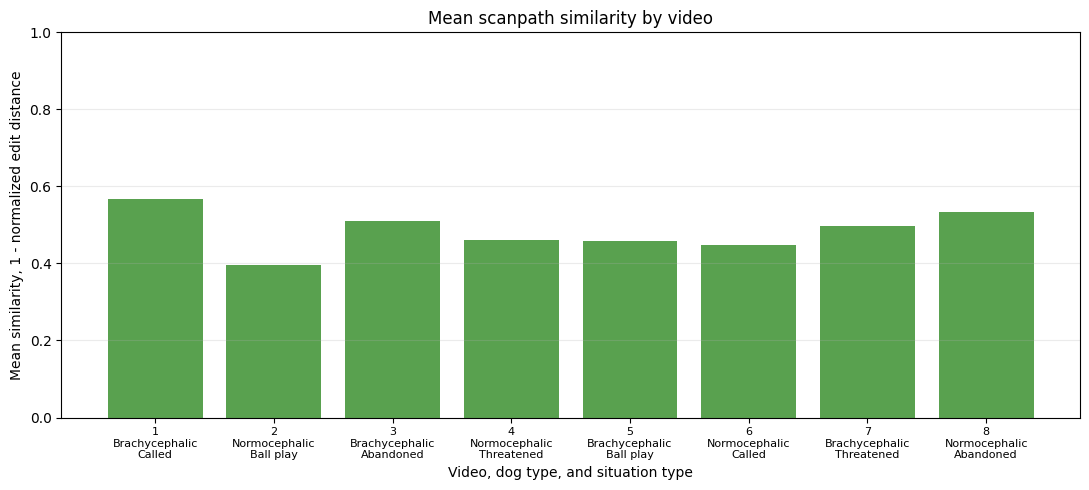

Saved: outputs/advanced_eye_tracking_analysis/mean_scanpath_similarity_by_video.png
Conclusion - mean scanpath similarity plot: Video 1: Brachycephalic, Called by name has the most similar scanpaths on average, while Video 2: Normocephalic, Played with a ball has the most variable scanpaths.


What this output shows - video 1 scanpath distance matrix: This heatmap compares every participant with every other participant for the same video. Darker/lower values mean more similar scanpaths.


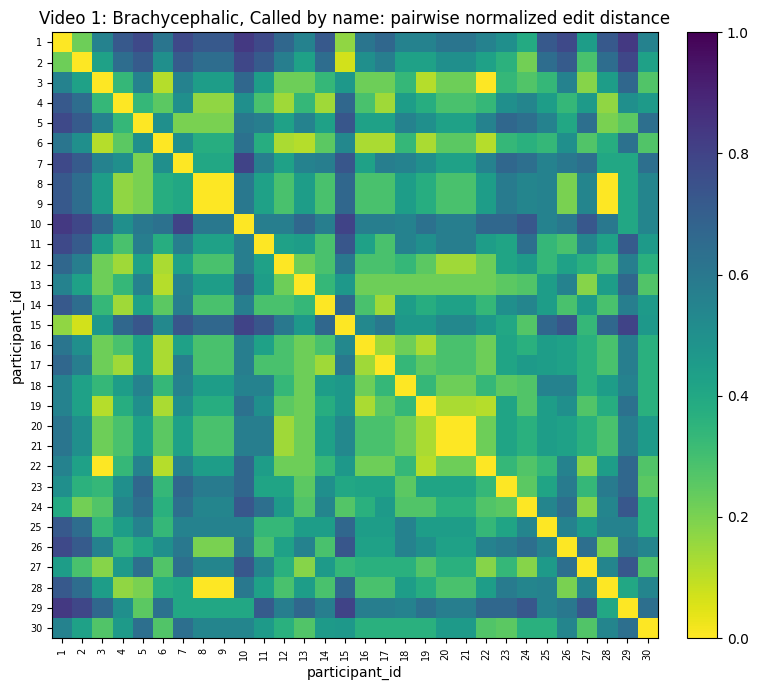

Saved: outputs/advanced_eye_tracking_analysis/scanpath_distance_matrix_video_1.png
Conclusion - video 1 scanpath distance matrix: Video 1 has mean scanpath similarity 0.567. Darker cells are the participant pairs with more similar AOI order, so dense dark areas indicate more consistent viewing strategies for that video.


What this output shows - video 2 scanpath distance matrix: This heatmap compares every participant with every other participant for the same video. Darker/lower values mean more similar scanpaths.


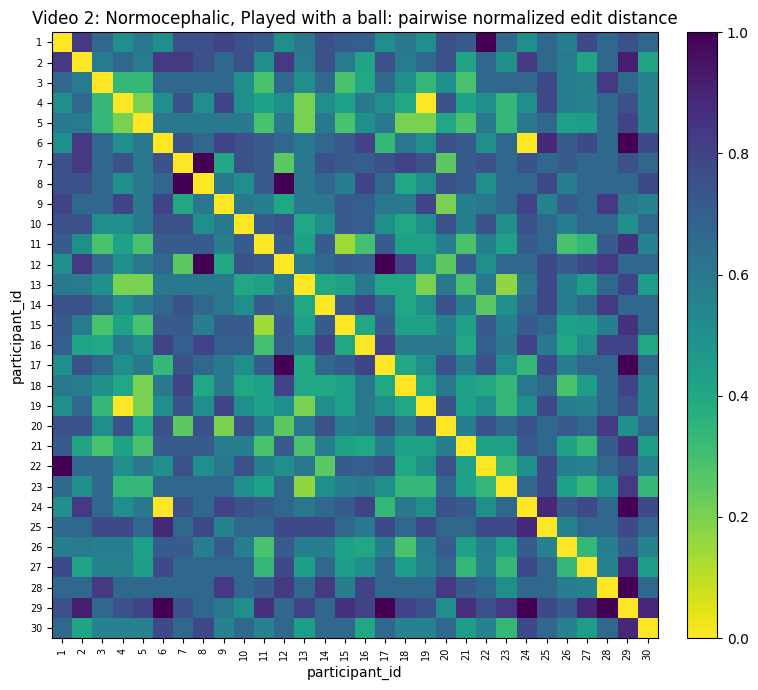

Saved: outputs/advanced_eye_tracking_analysis/scanpath_distance_matrix_video_2.png
Conclusion - video 2 scanpath distance matrix: Video 2 has mean scanpath similarity 0.396. Darker cells are the participant pairs with more similar AOI order, so dense dark areas indicate more consistent viewing strategies for that video.


What this output shows - video 3 scanpath distance matrix: This heatmap compares every participant with every other participant for the same video. Darker/lower values mean more similar scanpaths.


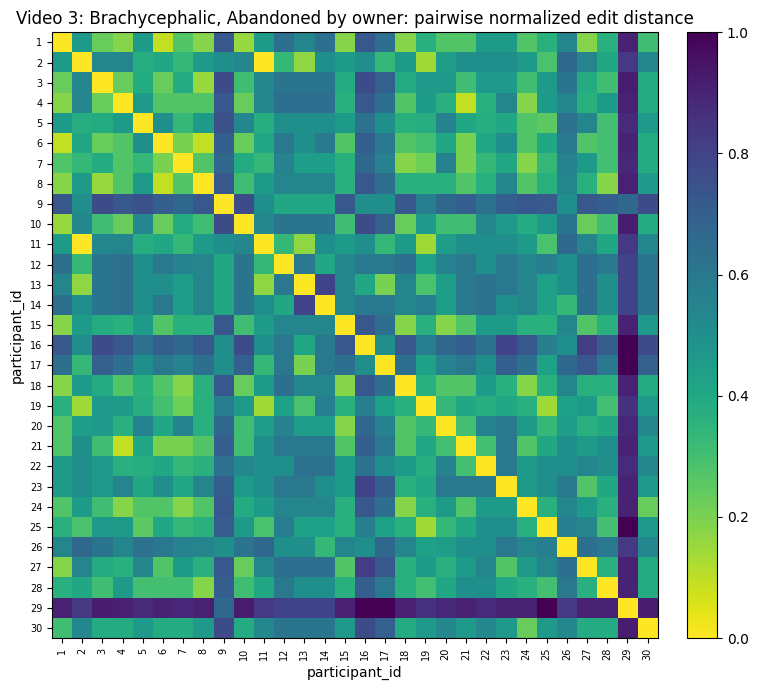

Saved: outputs/advanced_eye_tracking_analysis/scanpath_distance_matrix_video_3.png
Conclusion - video 3 scanpath distance matrix: Video 3 has mean scanpath similarity 0.510. Darker cells are the participant pairs with more similar AOI order, so dense dark areas indicate more consistent viewing strategies for that video.


What this output shows - video 4 scanpath distance matrix: This heatmap compares every participant with every other participant for the same video. Darker/lower values mean more similar scanpaths.


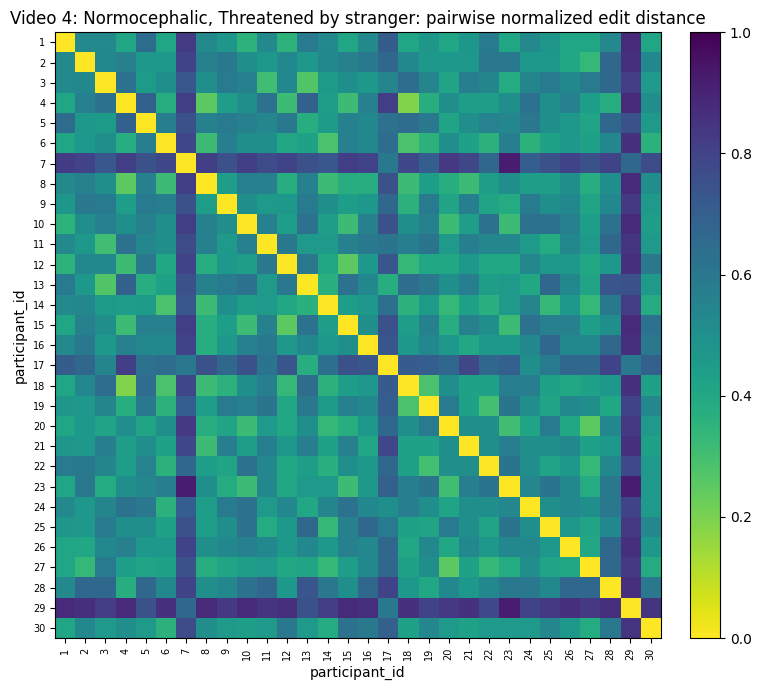

Saved: outputs/advanced_eye_tracking_analysis/scanpath_distance_matrix_video_4.png
Conclusion - video 4 scanpath distance matrix: Video 4 has mean scanpath similarity 0.462. Darker cells are the participant pairs with more similar AOI order, so dense dark areas indicate more consistent viewing strategies for that video.


What this output shows - video 5 scanpath distance matrix: This heatmap compares every participant with every other participant for the same video. Darker/lower values mean more similar scanpaths.


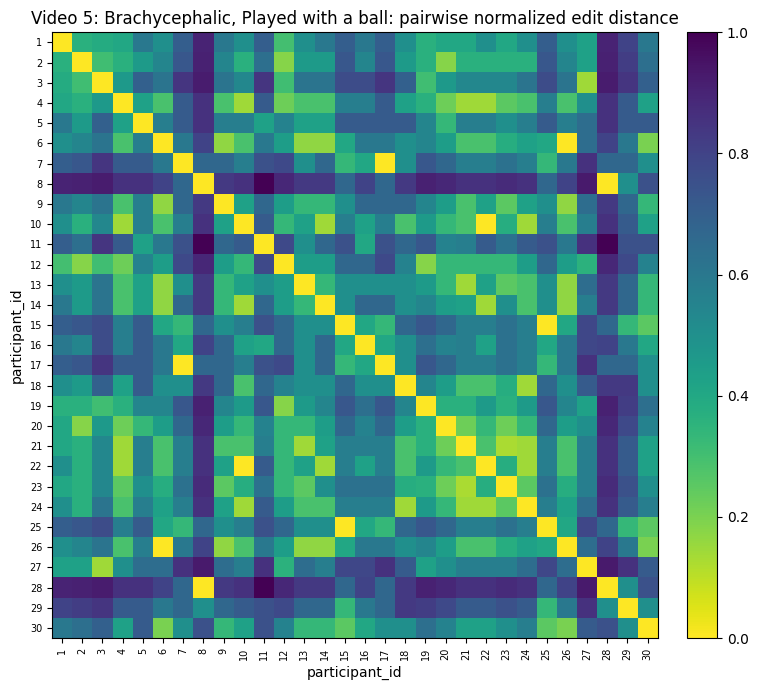

Saved: outputs/advanced_eye_tracking_analysis/scanpath_distance_matrix_video_5.png
Conclusion - video 5 scanpath distance matrix: Video 5 has mean scanpath similarity 0.457. Darker cells are the participant pairs with more similar AOI order, so dense dark areas indicate more consistent viewing strategies for that video.


What this output shows - video 6 scanpath distance matrix: This heatmap compares every participant with every other participant for the same video. Darker/lower values mean more similar scanpaths.


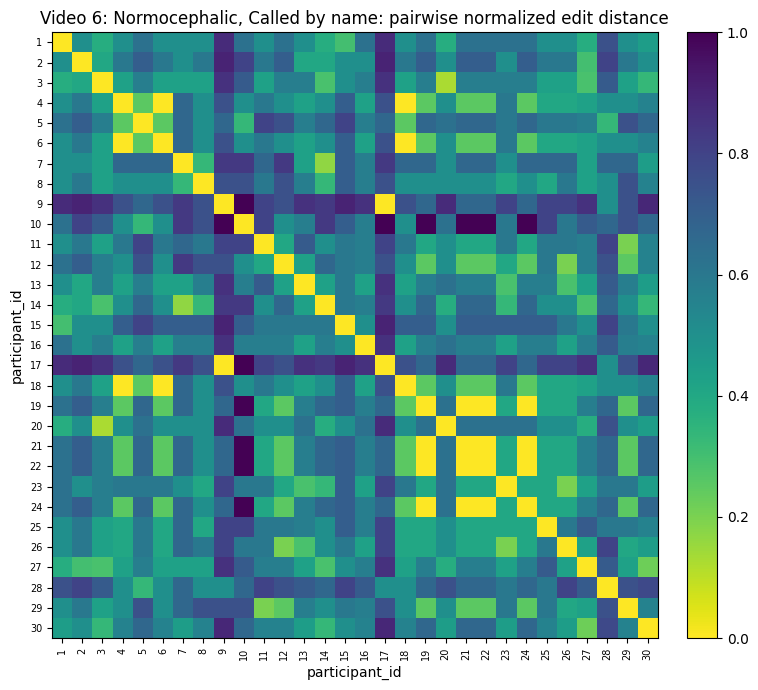

Saved: outputs/advanced_eye_tracking_analysis/scanpath_distance_matrix_video_6.png
Conclusion - video 6 scanpath distance matrix: Video 6 has mean scanpath similarity 0.447. Darker cells are the participant pairs with more similar AOI order, so dense dark areas indicate more consistent viewing strategies for that video.


What this output shows - video 7 scanpath distance matrix: This heatmap compares every participant with every other participant for the same video. Darker/lower values mean more similar scanpaths.


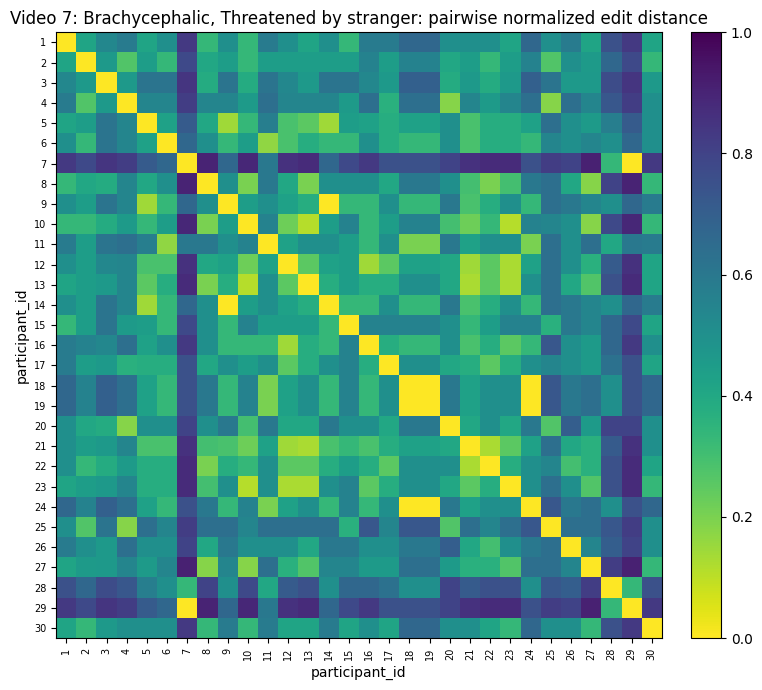

Saved: outputs/advanced_eye_tracking_analysis/scanpath_distance_matrix_video_7.png
Conclusion - video 7 scanpath distance matrix: Video 7 has mean scanpath similarity 0.498. Darker cells are the participant pairs with more similar AOI order, so dense dark areas indicate more consistent viewing strategies for that video.


What this output shows - video 8 scanpath distance matrix: This heatmap compares every participant with every other participant for the same video. Darker/lower values mean more similar scanpaths.


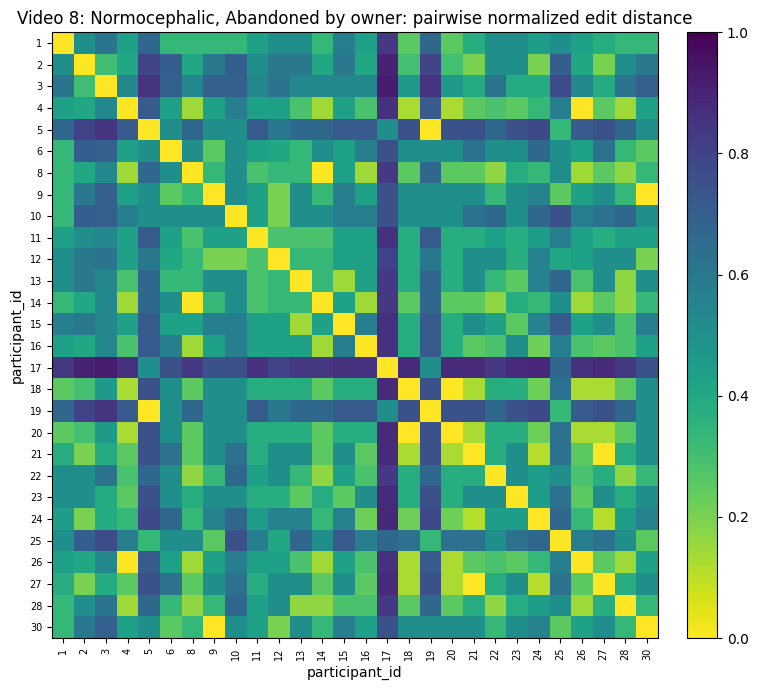

Saved: outputs/advanced_eye_tracking_analysis/scanpath_distance_matrix_video_8.png
Conclusion - video 8 scanpath distance matrix: Video 8 has mean scanpath similarity 0.534. Darker cells are the participant pairs with more similar AOI order, so dense dark areas indicate more consistent viewing strategies for that video.


What this output shows - dog ownership group summary table: This table compares core gaze metrics between participants with and without dog ownership experience.


fixation_count                              \
                          count       mean       std median   
do_you_own_a_dog                                              
No                          104  15.644231  5.496545   15.5   
Yes                         134  16.447761  5.718414   16.0   

                 total_fixation_duration                                    \
                                   count         mean          std  median   
do_you_own_a_dog                                                             
No                                   104  6655.826923  1751.661305  6739.0   
Yes                                  134  6634.134328  1799.523282  6855.5   

                 mean_fixation_duration              ... transition_rate  \
                                  count        mean  ...             std   
do_you_own_a_dog                                     ...                   
No                                  104  473.474276  ...        0.504187   
Yes                                 134  438.118460  ...        0.537692   

                           number_of_unique_AOIs_visited                      \
                    median                         count      mean       std   
do_you_own_a_dog                                                               
No                0.882962                           104  2.961538  0.912939   
Yes               0.952634                           134  2.873134  0.676364   

                        average_jump_distance                                
                 median                 count      mean       std    median  
do_you_own_a_dog                                                             
No                  3.0                   104  0.127596  0.038041  0.127970  
Yes                 3.0                   134  0.125584  0.040149  0.127526  

[2 rows x 28 columns]

Conclusion - dog ownership group summary table: Dog-ownership differences are small: owners averaged slightly more fixations (16.45 vs 15.64), while non-owners visited slightly more unique AOIs (2.96 vs 2.87). This does not look like a strong dog-ownership effect.


What this output shows - gender group summary table: This table compares the same gaze metrics by participant gender.


fixation_count                             total_fixation_duration  \
                count       mean       std median                   count   
gender                                                                      
Female             48  18.041667  5.144542   18.0                      48   
Male              190  15.605263  5.647210   15.0                     190   

                                         mean_fixation_duration              \
               mean          std  median                  count        mean   
gender                                                                        
Female  6506.979167  1545.193983  6748.0                     48  373.774845   
Male    6678.131579  1830.683762  6832.0                    190  473.726347   

        ... transition_rate           number_of_unique_AOIs_visited            \
        ...             std    median                         count      mean   
gender  ...                                                                     
Female  ...        0.453522  1.079954                            48  3.062500   
Male    ...        0.539167  0.878221                           190  2.873684   

                        average_jump_distance                                
             std median                 count      mean       std    median  
gender                                                                       
Female  0.755300    3.0                    48  0.123544  0.039386  0.126331  
Male    0.793387    3.0                   190  0.127201  0.039188  0.127662  

[2 rows x 28 columns]

Conclusion - gender group summary table: Female participants averaged more fixations (18.04 vs 15.61), while male participants had longer mean fixations (473.73 ms vs 373.77 ms). Because the groups are uneven, this should be treated as a cautious pattern rather than a firm demographic effect.


What this output shows - AOI transitions by dog ownership plot: This boxplot compares how often participants switched between AOIs, grouped by whether they have had a dog.


/tmp/ipykernel_2879/1784784350.py:302: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=group_order, showmeans=True)


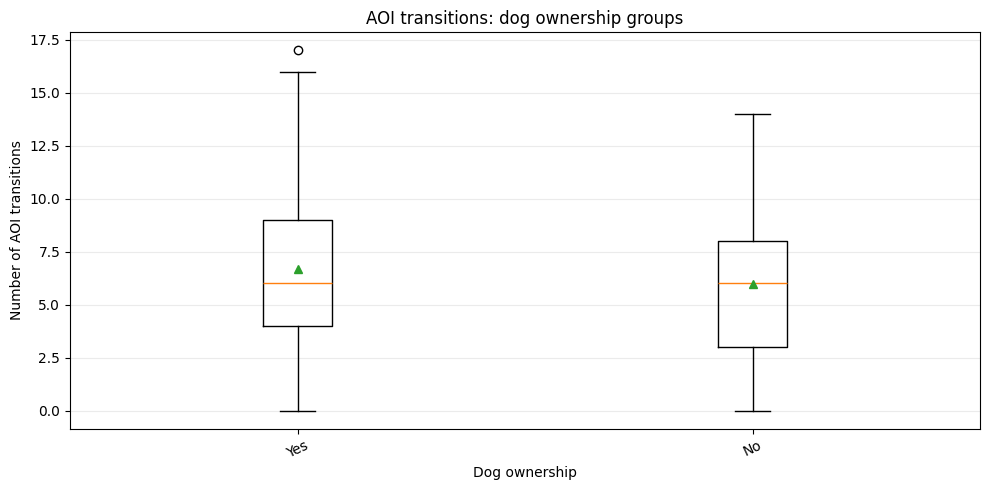

Saved: outputs/advanced_eye_tracking_analysis/group_dog_ownership_aoi_transitions.png
Conclusion - AOI transitions by dog ownership plot: The ownership groups are close overall, so any visible difference in AOI transitions should be interpreted as modest rather than as a major gaze-strategy split.


What this output shows - Face_TOP looking by dog ownership plot: This boxplot compares the proportion of fixation time on ears, forehead, and eyes by dog ownership group.


/tmp/ipykernel_2879/1784784350.py:302: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=group_order, showmeans=True)


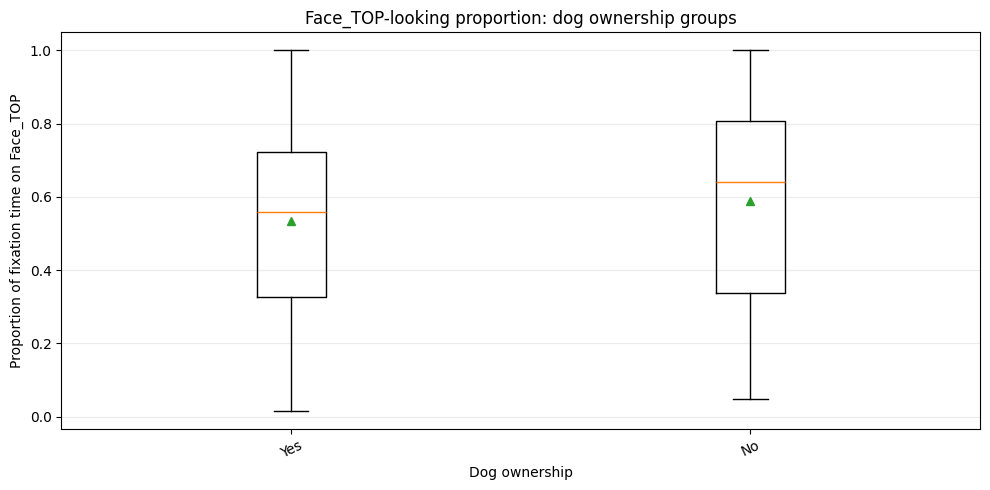

Saved: outputs/advanced_eye_tracking_analysis/group_dog_ownership_face_top_proportion.png
Conclusion - Face_TOP looking by dog ownership plot: Dog ownership does not appear to dominate Face_TOP looking; the summary table shows only small ownership-group differences across the main gaze metrics.


What this output shows - AOI transitions by gender plot: This boxplot compares AOI switching frequency between gender groups.


/tmp/ipykernel_2879/1784784350.py:302: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=group_order, showmeans=True)


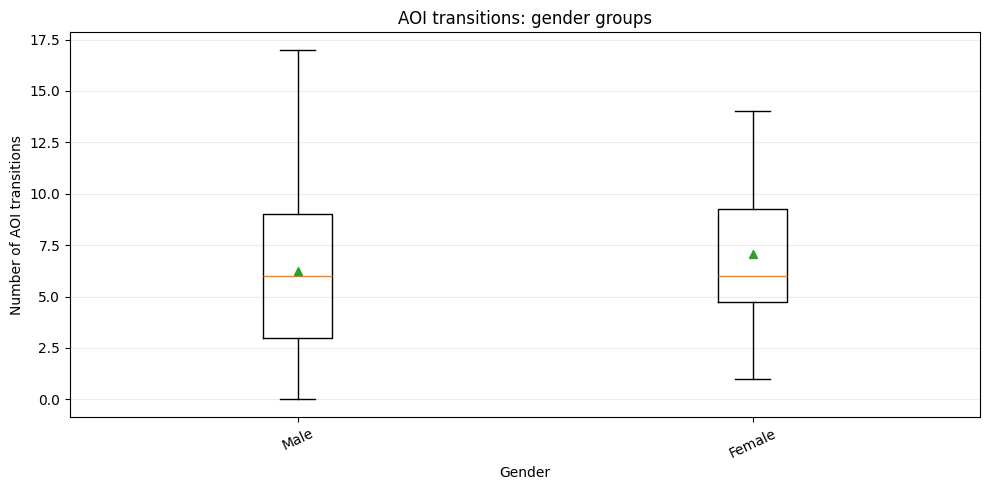

Saved: outputs/advanced_eye_tracking_analysis/group_gender_aoi_transitions.png
Conclusion - AOI transitions by gender plot: The clearest gender-related pattern is fixation style: female participants made more fixations, while male participants had longer fixations. The plot should be read with the uneven group sizes in mind.


What this output shows - Face_TOP looking by gender plot: This boxplot compares upper-face gaze proportion between gender groups.


/tmp/ipykernel_2879/1784784350.py:302: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=group_order, showmeans=True)


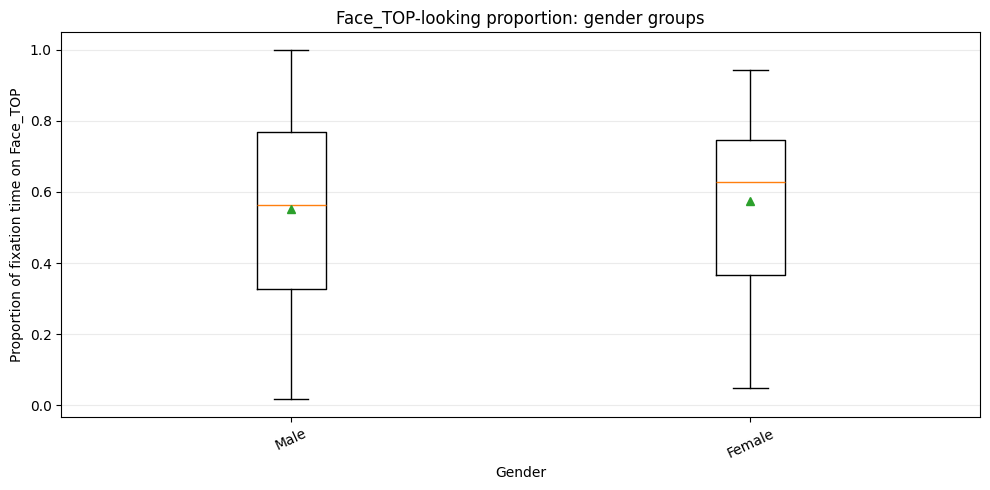

Saved: outputs/advanced_eye_tracking_analysis/group_gender_face_top_proportion.png
Conclusion - Face_TOP looking by gender plot: Any Face_TOP difference by gender should be interpreted cautiously; the stronger observed difference is in fixation count and duration, not necessarily in upper-face preference.


What this output shows - gaze metrics by perceived emotion table: This table groups participant-video rows by the emotion participants thought the dog was showing, then summarizes gaze behavior for each answer category.


,rows,rows_with_gaze,mean_fixation_count,mean_total_fixation_duration,mean_AOI_transitions,mean_face_top_proportion,mean_face_bottom_proportion,mean_torso_proportion,mean_tail_proportion,mean_legs_proportion
choose_perceived_emotional_state,,,,,,,,,,
Neutral,63,62,17.145161,7241.741935,6.854839,0.545000,0.337368,0.176189,0.054519,0.064121
Somewhat positive,62,62,14.532258,5948.532258,5.516129,0.637284,0.244549,0.209871,0.163995,0.086021
Somewhat negative,60,59,17.576271,7284.000000,7.593220,0.528376,0.305961,0.241367,0.033707,0.064159
Completely positive,36,36,13.194444,5238.833333,4.638889,0.488358,0.441370,0.194183,0.130599,0.058496
Completely negative,15,15,18.666667,7644.066667,7.400000,0.501798,0.246320,0.265082,NaN,0.058929
Do not know / cannot identify,4,4,18.750000,7592.000000,7.000000,0.755070,0.174561,0.087213,0.107183,NaN


Conclusion - gaze metrics by perceived emotion table: Negative emotion judgments involved more AOI switching than positive judgments: somewhat negative averaged 7.59 transitions and completely negative averaged 7.40, while completely positive averaged 4.64 transitions.


What this output shows - AOI transitions by perceived emotion plot: This boxplot compares scanpath switching across the emotion categories participants selected.


/tmp/ipykernel_2879/1784784350.py:355: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=answer_order, showmeans=True)


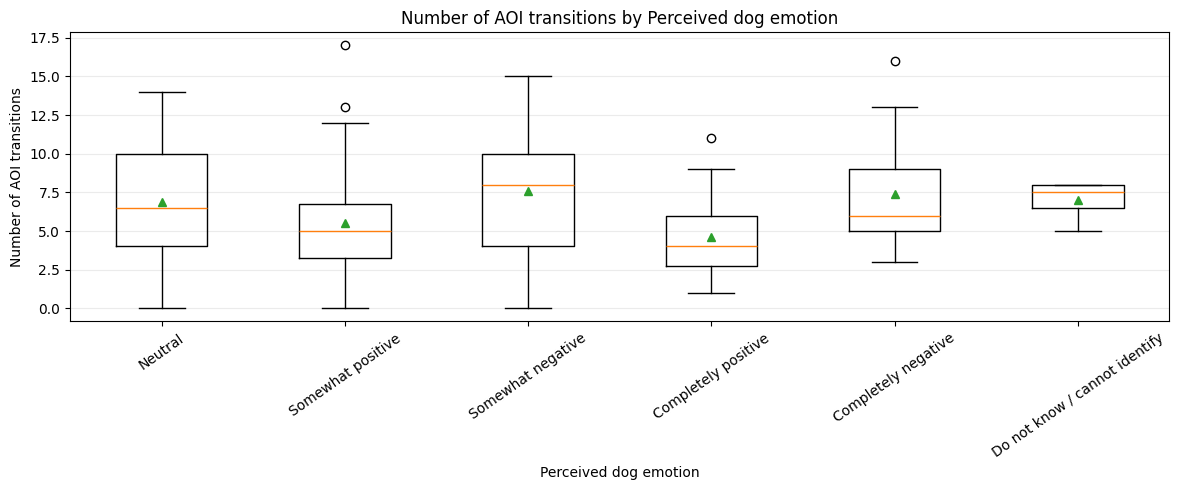

Saved: outputs/advanced_eye_tracking_analysis/gaze_transitions_by_emotional_answer.png
Conclusion - AOI transitions by perceived emotion plot: The plot supports the table pattern: negative emotion judgments involved more AOI switching, while completely positive judgments had the lowest transition count.


What this output shows - Face_TOP looking by situation answer plot: This boxplot compares upper-face gaze proportion across the situations participants selected.


/tmp/ipykernel_2879/1784784350.py:355: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=answer_order, showmeans=True)


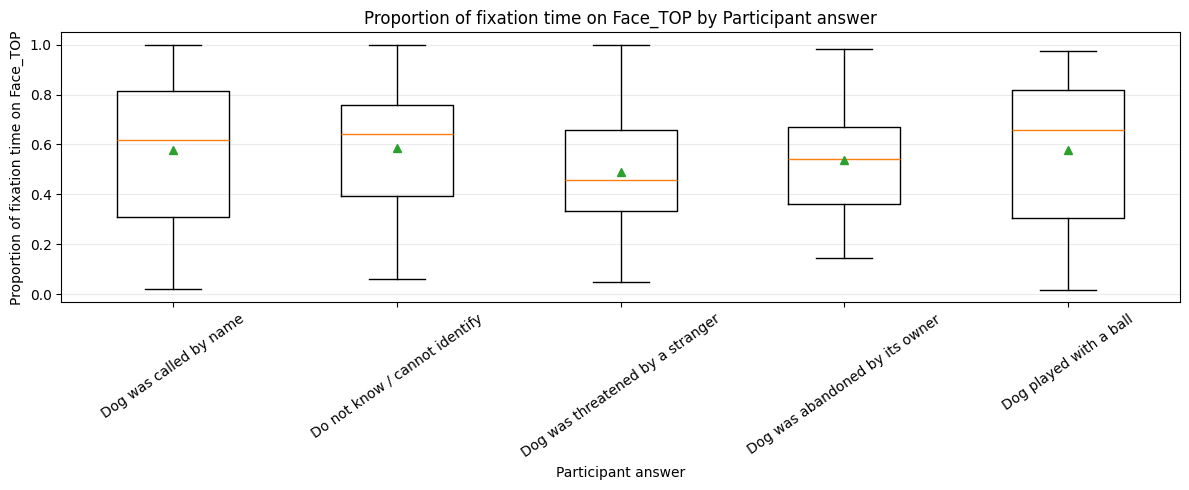

Saved: outputs/advanced_eye_tracking_analysis/face_top_proportion_by_situation_answer.png
Conclusion - Face_TOP looking by situation answer plot: Unknown answers had the highest Face_TOP proportion (0.755) but only 4 rows. Among common emotion categories, somewhat positive answers had high Face_TOP looking (0.637), while completely positive answers had lower Face_TOP (0.488) and higher Face_BOTTOM (0.441).


What this output shows - accuracy by video plot: This bar chart shows the percentage of correct situation answers for each video.


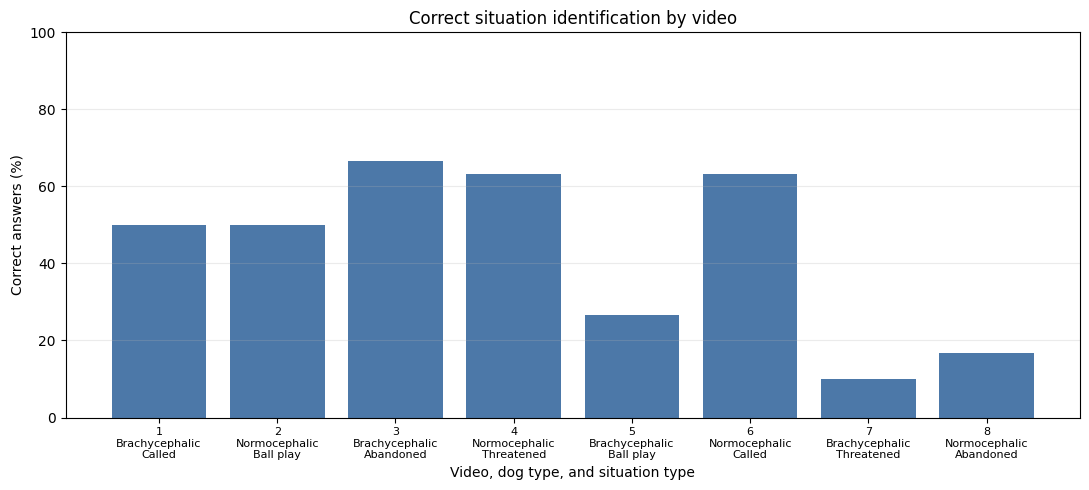

Saved: outputs/advanced_eye_tracking_analysis/situation_accuracy_by_video.png
Conclusion - accuracy by video plot: Video 3 (brachycephalic, abandoned by owner) was identified most accurately at 66.7%, while Video 7 (brachycephalic, threatened by stranger) was hardest at 10.0%.

What this output shows - accuracy by video table: This table shows the percentage of correct situation answers for each video.


,video_number,situation_correct,accuracy_percent,dog_type,situation_type,video_label
0,1,0.500000,50.000000,Brachycephalic,Called by name,"Video 1: Brachycephalic, Called by name"
1,2,0.500000,50.000000,Normocephalic,Played with a ball,"Video 2: Normocephalic, Played with a ball"
2,3,0.666667,66.666667,Brachycephalic,Abandoned by owner,"Video 3: Brachycephalic, Abandoned by owner"
3,4,0.633333,63.333333,Normocephalic,Threatened by stranger,"Video 4: Normocephalic, Threatened by stranger"
4,5,0.266667,26.666667,Brachycephalic,Played with a ball,"Video 5: Brachycephalic, Played with a ball"
5,6,0.633333,63.333333,Normocephalic,Called by name,"Video 6: Normocephalic, Called by name"
6,7,0.100000,10.000000,Brachycephalic,Threatened by stranger,"Video 7: Brachycephalic, Threatened by stranger"
7,8,0.166667,16.666667,Normocephalic,Abandoned by owner,"Video 8: Normocephalic, Abandoned by owner"


Conclusion - accuracy by video table: Video 3: Brachycephalic, Abandoned by owner was identified most accurately (66.7%), while Video 7: Brachycephalic, Threatened by stranger was hardest (10.0%).


What this output shows - accuracy by true situation table: This table aggregates accuracy by the actual situation shown in the video.


,rows,correct,accuracy
true_situation,,,
Dog was called by name,60,34,0.566667
Dog was abandoned by its owner,60,25,0.416667
Dog played with a ball,60,23,0.383333
Dog was threatened by a stranger,60,22,0.366667


Conclusion - accuracy by true situation table: Called by name was the easiest situation overall (56.7% correct), while threatened by stranger was the hardest (36.7% correct).


What this output shows - situation confusion matrix table: Rows are the true situations and columns are participant answers. Off-diagonal cells show which situations were confused with each other.


situation_description,Do not know / cannot identify,Dog played with a ball,Dog was abandoned by its owner,Dog was called by name,Dog was threatened by a stranger,All
true_situation,,,,,,
Dog played with a ball,12,23,2,18,5,60
Dog was abandoned by its owner,11,4,25,9,11,60
Dog was called by name,12,3,6,34,5,60
Dog was threatened by a stranger,25,1,8,4,22,60
All,60,31,41,65,43,240


Conclusion - situation confusion matrix table: Threatened-by-stranger was often not identified: 25 responses were Do not know compared with 22 correct answers. Ball play was also often confused with called-by-name, with 18 such responses.


What this output shows - situation confusion matrix plot: This heatmap visualizes the same true-vs-answer matrix, making common misclassifications easier to see.


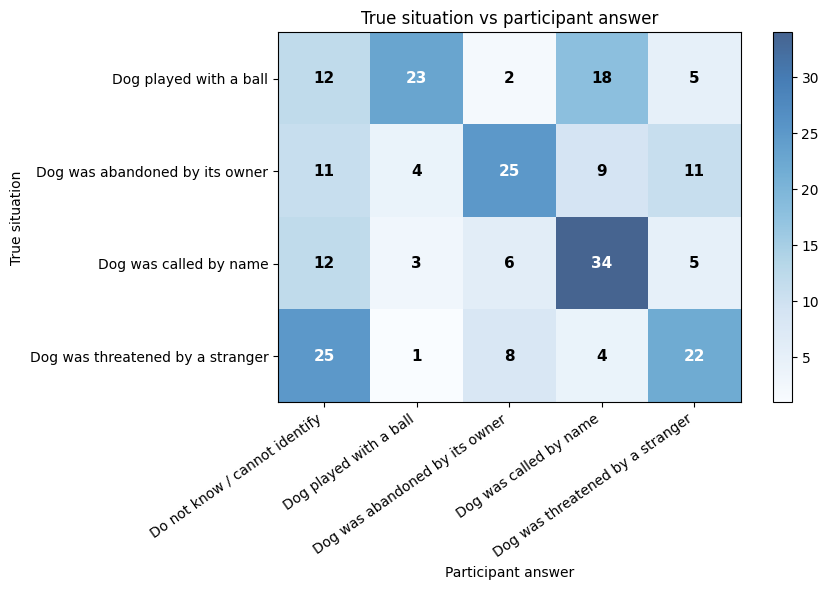

Saved: outputs/advanced_eye_tracking_analysis/situation_confusion_matrix.png
Conclusion - situation confusion matrix plot: The darkest error pattern is that threatened-by-stranger often became Do not know, and ball play was frequently interpreted as called-by-name.


What this output shows - AOI proportions for correct vs incorrect answers plot: This bar chart compares where participants looked when they correctly or incorrectly identified the situation.


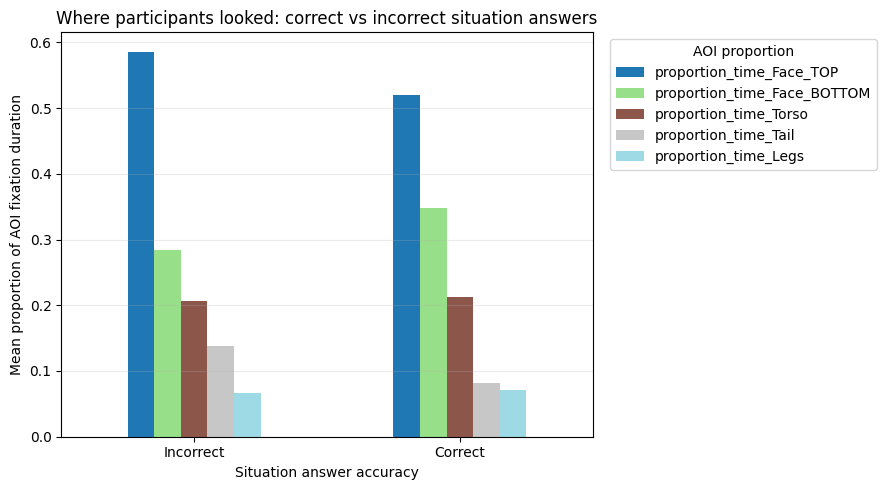

Saved: outputs/advanced_eye_tracking_analysis/aoi_proportions_correct_vs_incorrect.png
Conclusion - AOI proportions for correct vs incorrect answers plot: Incorrect answers had higher Face_TOP looking (0.586 vs 0.520), while correct answers had higher Face_BOTTOM looking (0.348 vs 0.284). This suggests lower-face cues may have helped correct situation interpretation.

What this output shows - AOI proportions for correct vs incorrect answers table: This table compares where participants looked when they correctly or incorrectly identified the situation.


,proportion_time_Face_TOP,proportion_time_Face_BOTTOM,proportion_time_Torso,proportion_time_Tail,proportion_time_Legs
situation_correct,,,,,
Incorrect,0.585871,0.284317,0.206390,0.137301,0.066833
Correct,0.519757,0.347892,0.212578,0.082369,0.071224


Conclusion - AOI proportions for correct vs incorrect answers table: Incorrect answers had higher Face_TOP looking (0.586 vs 0.520), while correct answers had higher Face_BOTTOM looking (0.348 vs 0.284). The biggest practical pattern is that correct interpretation was associated with more lower-face attention.


What this output shows - correct vs incorrect gaze metrics by video table: This table breaks gaze metrics down by video and by whether the participant answered correctly.


,video_number,dog_type,situation_type,situation_correct,rows,rows_with_gaze,mean_fixation_count,mean_total_fixation_duration,mean_AOI_transitions,mean_face_top_proportion,mean_face_bottom_proportion,mean_torso_proportion,mean_tail_proportion,mean_legs_proportion
0,1,Brachycephalic,Called by name,False,15,15,12.933333,6955.666667,5.800000,0.572268,0.350470,0.104180,0.049719,0.137885
1,1,Brachycephalic,Called by name,True,15,15,16.933333,7935.466667,8.600000,0.471905,0.480899,0.064935,NaN,0.041181
2,2,Normocephalic,Played with a ball,False,15,15,13.466667,5430.733333,4.400000,0.388053,0.411787,0.196853,0.195133,0.041582
3,2,Normocephalic,Played with a ball,True,15,15,12.733333,5484.866667,4.333333,0.413286,0.604081,0.101603,0.108064,0.109316
4,3,Brachycephalic,Abandoned by owner,False,10,10,21.400000,7187.000000,6.900000,0.605648,0.168351,0.250732,NaN,0.044697
5,3,Brachycephalic,Abandoned by owner,True,20,20,19.050000,6956.600000,7.500000,0.581682,0.217878,0.258210,NaN,0.080291
6,4,Normocephalic,Threatened by stranger,False,11,11,18.727273,8141.363636,10.090909,0.444737,0.382602,0.193151,0.021818,0.089416
7,4,Normocephalic,Threatened by stranger,True,19,19,23.157895,8977.736842,11.631579,0.354074,0.381011,0.243518,0.044735,0.058891
8,5,Brachycephalic,Played with a ball,False,22,22,17.272727,7241.000000,5.545455,0.788050,0.210698,0.101092,NaN,0.044490
9,5,Brachycephalic,Played with a ball,True,8,8,18.500000,6599.250000,4.750000,0.834687,0.120027,0.090111,NaN,0.031757


Conclusion - correct vs incorrect gaze metrics by video table: Video 1 correct answers had more transitions (8.60 vs 5.80) and more Face_BOTTOM looking (0.481 vs 0.350). Video 4 correct answers also had more transitions (11.63 vs 10.09) and less Face_TOP looking (0.354 vs 0.445).


What this output shows - dominant AOI among correct answers table: This table counts which AOI was dominant among participants who correctly identified each video situation, with dog type and situation type shown for each video.


dominant_AOI,video_number,dog_type,situation_type,Face_BOTTOM,Face_TOP,Torso
0,1,Brachycephalic,Called by name,8,7,0
1,2,Normocephalic,Played with a ball,10,5,0
2,3,Brachycephalic,Abandoned by owner,1,16,3
3,4,Normocephalic,Threatened by stranger,11,5,3
4,5,Brachycephalic,Played with a ball,0,8,0
5,6,Normocephalic,Called by name,2,12,5
6,7,Brachycephalic,Threatened by stranger,2,1,0
7,8,Normocephalic,Abandoned by owner,0,4,1


Conclusion - dominant AOI among correct answers table: Face_TOP is the most frequent dominant AOI overall among correct answers, but Face_BOTTOM dominates correct rows in videos 1, 2, 4, and 7. The useful AOI is therefore video- and situation-dependent.


What this output shows - dominant AOI among correct answers plot: This stacked bar chart shows which AOIs dominated the gaze behavior of participants who answered correctly, separately for each video.


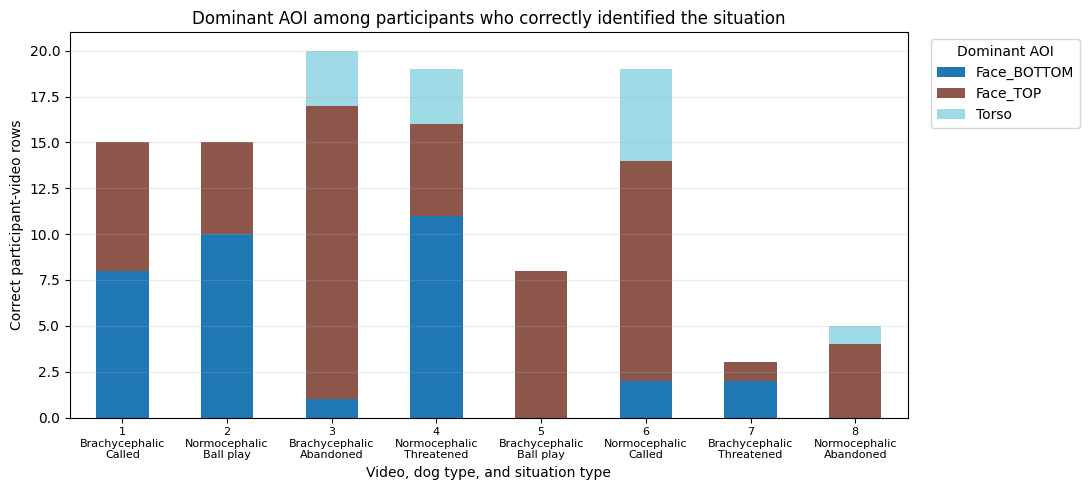

Saved: outputs/advanced_eye_tracking_analysis/dominant_aoi_correct_answers_by_video.png
Conclusion - dominant AOI among correct answers plot: Face_TOP is the most frequent dominant AOI overall among correct answers, but Face_BOTTOM dominates correct rows in videos 1, 2, 4, and 7. The useful AOI is therefore video- and situation-dependent.

Advanced analysis plots saved in: outputs/advanced_eye_tracking_analysis


In [ ]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


ADVANCED_PLOTS_DIR = Path('outputs') / 'advanced_eye_tracking_analysis'
ADVANCED_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

TRUE_SITUATION_BY_VIDEO = {
    1: 'Dog was called by name',
    2: 'Dog played with a ball',
    3: 'Dog was abandoned by its owner',
    4: 'Dog was threatened by a stranger',
    5: 'Dog played with a ball',
    6: 'Dog was called by name',
    7: 'Dog was threatened by a stranger',
    8: 'Dog was abandoned by its owner',
}

DOG_TYPE_BY_VIDEO = {
    1: 'Brachycephalic',
    2: 'Normocephalic',
    3: 'Brachycephalic',
    4: 'Normocephalic',
    5: 'Brachycephalic',
    6: 'Normocephalic',
    7: 'Brachycephalic',
    8: 'Normocephalic',
}

SITUATION_TYPE_BY_VIDEO = {
    1: 'Called by name',
    2: 'Played with a ball',
    3: 'Abandoned by owner',
    4: 'Threatened by stranger',
    5: 'Played with a ball',
    6: 'Called by name',
    7: 'Threatened by stranger',
    8: 'Abandoned by owner',
}

SHORT_SITUATION_BY_VIDEO = {
    1: 'Called',
    2: 'Ball play',
    3: 'Abandoned',
    4: 'Threatened',
    5: 'Ball play',
    6: 'Called',
    7: 'Threatened',
    8: 'Abandoned',
}


def video_tick_label(video_number):
    video_number = int(video_number)
    return f"{video_number}\n{DOG_TYPE_BY_VIDEO[video_number]}\n{SHORT_SITUATION_BY_VIDEO[video_number]}"


def video_sentence_label(video_number):
    video_number = int(video_number)
    return f"Video {video_number}: {DOG_TYPE_BY_VIDEO[video_number]}, {SITUATION_TYPE_BY_VIDEO[video_number]}"


def add_video_metadata_columns(df):
    df = df.copy()
    if 'video_number' not in df.columns:
        return df
    video_numbers = pd.to_numeric(df['video_number'], errors='coerce').astype('Int64')
    df['dog_type'] = video_numbers.map(DOG_TYPE_BY_VIDEO)
    df['situation_type'] = video_numbers.map(SITUATION_TYPE_BY_VIDEO)
    df['video_label'] = video_numbers.map(lambda value: video_sentence_label(value) if pd.notna(value) else pd.NA)
    return df

# English display labels for plots and tables.
VALUE_TRANSLATIONS = {
    'הכלב נקרא בשמו': 'Dog was called by name',
    'הכלב שיחק עם כדור': 'Dog played with a ball',
    'הכלב ננטש על ידי בעליו': 'Dog was abandoned by its owner',
    'הכלב אוים על ידי אדם זר': 'Dog was threatened by a stranger',
    'אני לא יודע/ת / לא יכול/ה לזהות': 'Do not know / cannot identify',
    'חיובי לחלוטין': 'Completely positive',
    'חיובי במידה מסוימת / קלות': 'Somewhat positive',
    'ניטרלי': 'Neutral',
    'שלילי במידה מסוימת / קלות': 'Somewhat negative',
    'שלילי לחלוטין': 'Completely negative',
    'כן': 'Yes',
    'לא - ניתן לדלג לשאלה 8': 'No',
    'זכר': 'Male',
    'נקבה': 'Female',
}

COLUMN_LABELS = {
    'do_you_own_a_dog': 'Dog ownership',
    'gender': 'Gender',
    'choose_perceived_emotional_state': 'Perceived dog emotion',
    'situation_description': 'Participant answer',
    'number_of_AOI_transitions': 'Number of AOI transitions',
    'proportion_time_Face_TOP': 'Proportion of fixation time on Face_TOP',
    'proportion_time_Face_BOTTOM': 'Proportion of fixation time on Face_BOTTOM',
    'proportion_time_Torso': 'Proportion of fixation time on Torso',
    'proportion_time_Tail': 'Proportion of fixation time on Tail',
    'proportion_time_Legs': 'Proportion of fixation time on Legs',
}

AOI_SYMBOLS = {
    'Face_TOP': 'T',
    'Face_BOTTOM': 'B',
    'Torso': 'O',
    'Tail': 'A',
    'Legs': 'L',
}

KEY_GAZE_METRICS = [
    'fixation_count',
    'total_fixation_duration',
    'mean_fixation_duration',
    'number_of_AOI_transitions',
    'transition_rate',
    'number_of_unique_AOIs_visited',
    'average_jump_distance',
]


def save_and_show_advanced(fig, filename):
    path = ADVANCED_PLOTS_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}')


def normalize_text(value):
    if pd.isna(value):
        return pd.NA
    return ' '.join(str(value).strip().split())


def translate_for_display(value):
    if pd.isna(value):
        return value
    return VALUE_TRANSLATIONS.get(str(value).strip(), value)


def apply_english_display_labels(df):
    """Ensure key questionnaire categories are English before plotting."""
    df = df.copy()
    for column in ['situation_description', 'choose_perceived_emotional_state', 'gender', 'do_you_own_a_dog']:
        if column in df.columns:
            df[column] = df[column].map(translate_for_display)
    return df


def column_label(column_name):
    return COLUMN_LABELS.get(column_name, column_name.replace('_', ' '))


def explain_before(title, explanation):
    print(f'\nWhat this output shows - {title}: {explanation}')


def explain_output(title, explanation, conclusion):
    print(f'Conclusion - {title}: {conclusion}\n')


def best_and_worst_by_column(df, label_col, value_col):
    valid = df.dropna(subset=[label_col, value_col])
    if valid.empty:
        return None, None
    best = valid.loc[valid[value_col].idxmax()]
    worst = valid.loc[valid[value_col].idxmin()]
    return best, worst


def add_true_situation_and_accuracy(combined_df):
    df = apply_english_display_labels(combined_df)
    df = add_video_metadata_columns(df)
    df['true_situation'] = df['video_number'].map(TRUE_SITUATION_BY_VIDEO)
    df['situation_description_normalized'] = df['situation_description'].map(normalize_text)
    df['true_situation_normalized'] = df['true_situation'].map(normalize_text)
    df['situation_correct'] = df['situation_description_normalized'] == df['true_situation_normalized']
    return df


def extract_aoi_proportion_columns(df):
    df = df.copy()
    all_aois = ['Face_TOP', 'Face_BOTTOM', 'Torso', 'Tail', 'Legs']
    for aoi in all_aois:
        df[f'proportion_time_{aoi}'] = df['proportion_of_time_per_AOI'].apply(
            lambda value, aoi=aoi: value.get(aoi, np.nan) if isinstance(value, dict) else np.nan
        )
        df[f'fixation_count_{aoi}'] = df['fixation_count_per_AOI'].apply(
            lambda value, aoi=aoi: value.get(aoi, np.nan) if isinstance(value, dict) else np.nan
        )
    return df


def levenshtein_distance(seq1, seq2):
    seq1 = list(seq1)
    seq2 = list(seq2)
    if len(seq1) == 0:
        return len(seq2)
    if len(seq2) == 0:
        return len(seq1)

    previous = list(range(len(seq2) + 1))
    for i, item1 in enumerate(seq1, start=1):
        current = [i]
        for j, item2 in enumerate(seq2, start=1):
            insert_cost = current[j - 1] + 1
            delete_cost = previous[j] + 1
            substitute_cost = previous[j - 1] + (item1 != item2)
            current.append(min(insert_cost, delete_cost, substitute_cost))
        previous = current
    return previous[-1]


def normalized_levenshtein_distance(seq1, seq2):
    max_len = max(len(seq1), len(seq2))
    if max_len == 0:
        return np.nan
    return levenshtein_distance(seq1, seq2) / max_len


def build_scanpath_sequences(gaze_df, aoi_col=AOI_COL):
    valid = gaze_df[gaze_df['video_number'].notna() & gaze_df[aoi_col].notna()].copy()
    valid['video_number'] = valid['video_number'].astype(int)

    rows = []
    for (participant_id, video_number), group in valid.groupby(['participant_id', 'video_number'], sort=True):
        raw_sequence = group[aoi_col].astype(str).tolist()
        collapsed_sequence = []
        for aoi in raw_sequence:
            if not collapsed_sequence or aoi != collapsed_sequence[-1]:
                collapsed_sequence.append(aoi)

        symbol_sequence = ''.join(AOI_SYMBOLS.get(aoi, '?') for aoi in collapsed_sequence)
        rows.append({
            'participant_id': int(participant_id),
            'video_number': int(video_number),
            'original_participant_label': group[ORIGINAL_PARTICIPANT_LABEL_COL].iloc[0],
            'scanpath_aoi_sequence': collapsed_sequence,
            'scanpath_symbol_sequence': symbol_sequence,
            'scanpath_length': len(collapsed_sequence),
        })

    return pd.DataFrame(rows).sort_values(['participant_id', 'video_number'])


def calculate_pairwise_scanpath_similarity(scanpath_df):
    rows = []
    for video_number, video_df in scanpath_df.groupby('video_number', sort=True):
        records = video_df.to_dict('records')
        for left, right in combinations(records, 2):
            seq_left = left['scanpath_symbol_sequence']
            seq_right = right['scanpath_symbol_sequence']
            distance = normalized_levenshtein_distance(seq_left, seq_right)
            rows.append({
                'video_number': int(video_number),
                'participant_id_1': left['participant_id'],
                'participant_id_2': right['participant_id'],
                'scanpath_1': seq_left,
                'scanpath_2': seq_right,
                'normalized_edit_distance': distance,
                'scanpath_similarity': 1 - distance if pd.notna(distance) else np.nan,
            })
    return pd.DataFrame(rows)


def build_scanpath_distance_matrix(scanpath_df, video_number):
    video_df = scanpath_df[scanpath_df['video_number'] == video_number].copy()
    participant_ids = video_df['participant_id'].tolist()
    sequences = dict(zip(video_df['participant_id'], video_df['scanpath_symbol_sequence']))
    matrix = pd.DataFrame(np.nan, index=participant_ids, columns=participant_ids)

    for participant_id_1 in participant_ids:
        for participant_id_2 in participant_ids:
            matrix.loc[participant_id_1, participant_id_2] = normalized_levenshtein_distance(
                sequences[participant_id_1],
                sequences[participant_id_2],
            )
    return matrix


def summarize_groups(df, group_col, metrics=KEY_GAZE_METRICS):
    available_metrics = [metric for metric in metrics if metric in df.columns]
    summary = df.groupby(group_col, dropna=False)[available_metrics].agg(['count', 'mean', 'std', 'median'])
    return summary


def plot_group_metric(df, group_col, metric_col, title, filename):
    plot_df = df.dropna(subset=[metric_col]).copy()
    group_order = plot_df[group_col].fillna('Missing').astype(str).value_counts().index.tolist()
    data = [
        plot_df.loc[plot_df[group_col].fillna('Missing').astype(str) == group, metric_col]
        for group in group_order
    ]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.boxplot(data, labels=group_order, showmeans=True)
    ax.set_title(title)
    ax.set_xlabel(column_label(group_col))
    ax.set_ylabel(column_label(metric_col))
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.25)
    save_and_show_advanced(fig, filename)


def plot_accuracy_by_video(df):
    accuracy = df.groupby('video_number')['situation_correct'].mean().reset_index()
    accuracy['accuracy_percent'] = accuracy['situation_correct'] * 100
    accuracy = add_video_metadata_columns(accuracy)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(accuracy['video_number'], accuracy['accuracy_percent'], color='#4C78A8')
    ax.set_title('Correct situation identification by video')
    ax.set_xlabel('Video, dog type, and situation type')
    ax.set_ylabel('Correct answers (%)')
    ax.set_ylim(0, 100)
    ax.set_xticks(accuracy['video_number'])
    ax.set_xticklabels([video_tick_label(video) for video in accuracy['video_number']], fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    save_and_show_advanced(fig, 'situation_accuracy_by_video.png')

    return accuracy


def plot_correct_vs_incorrect_aoi_proportions(df):
    proportion_cols = ['proportion_time_Face_TOP', 'proportion_time_Face_BOTTOM', 'proportion_time_Torso', 'proportion_time_Tail', 'proportion_time_Legs']
    plot_df = df.dropna(subset=['situation_correct']).copy()
    grouped = plot_df.groupby('situation_correct')[proportion_cols].mean()
    grouped.index = grouped.index.map({False: 'Incorrect', True: 'Correct'})

    fig, ax = plt.subplots(figsize=(9, 5))
    grouped.plot(kind='bar', ax=ax, colormap='tab20')
    ax.set_title('Where participants looked: correct vs incorrect situation answers')
    ax.set_xlabel('Situation answer accuracy')
    ax.set_ylabel('Mean proportion of AOI fixation duration')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='AOI proportion', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(axis='y', alpha=0.25)
    save_and_show_advanced(fig, 'aoi_proportions_correct_vs_incorrect.png')

    return grouped


def plot_gaze_metric_by_answer(df, answer_col, metric_col, filename):
    counts = df[answer_col].value_counts(dropna=False)
    answer_order = counts.index.tolist()
    data = [df.loc[df[answer_col] == answer, metric_col].dropna() for answer in answer_order]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.boxplot(data, labels=answer_order, showmeans=True)
    ax.set_title(f'{column_label(metric_col)} by {column_label(answer_col)}')
    ax.set_xlabel(column_label(answer_col))
    ax.set_ylabel(column_label(metric_col))
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.25)
    save_and_show_advanced(fig, filename)


# -----------------------------
# Build enriched analysis data
# -----------------------------
advanced_analysis_df = add_true_situation_and_accuracy(combined_questionnaire_gaze_df)
advanced_analysis_df = extract_aoi_proportion_columns(advanced_analysis_df)

scanpath_sequences_df = build_scanpath_sequences(gaze_df_with_video_numbers, aoi_col=AOI_COL)
pairwise_scanpath_similarity_df = calculate_pairwise_scanpath_similarity(scanpath_sequences_df)

print('Advanced analysis shapes:')
print('advanced_analysis_df:', advanced_analysis_df.shape)
print('scanpath_sequences_df:', scanpath_sequences_df.shape)
print('pairwise_scanpath_similarity_df:', pairwise_scanpath_similarity_df.shape)


# -----------------------------
# 1. Scanpath similarity and sequence analysis
# -----------------------------
print('AOI symbol encoding:')
print(AOI_SYMBOLS)

explain_before(
    'scanpath sequence preview',
    'Each row shows one participant-video scanpath after consecutive repeated AOIs were collapsed into a shorter AOI sequence.',
)
display(scanpath_sequences_df.head(12))
explain_output(
    'scanpath sequence preview',
    'Each row shows one participant-video scanpath after consecutive repeated AOIs were collapsed into a shorter AOI sequence.',
    'The previewed sequences show frequent movement between Face_TOP and Face_BOTTOM, confirming that splitting the old Head category gives more informative scanpaths than a single face/head label.',
)

scanpath_similarity_by_video = pairwise_scanpath_similarity_df.groupby('video_number').agg(
    pair_count=('scanpath_similarity', 'count'),
    mean_similarity=('scanpath_similarity', 'mean'),
    median_similarity=('scanpath_similarity', 'median'),
    mean_normalized_edit_distance=('normalized_edit_distance', 'mean'),
).reset_index()
scanpath_similarity_by_video = add_video_metadata_columns(scanpath_similarity_by_video)
similarity_by_video_lookup = scanpath_similarity_by_video.set_index('video_number')['mean_similarity'].to_dict()

explain_before(
    'scanpath similarity table',
    'This table summarizes pairwise scanpath similarity for each video. Higher similarity means participants moved between AOIs in more similar orders.',
)
display(scanpath_similarity_by_video)
best_video, worst_video = best_and_worst_by_column(scanpath_similarity_by_video, 'video_number', 'mean_similarity')
if best_video is not None:
    scanpath_conclusion = (
        f"{video_sentence_label(best_video['video_number'])} has the most similar scanpaths on average, "
        f"while {video_sentence_label(worst_video['video_number'])} has the most variable scanpaths."
    )
else:
    scanpath_conclusion = 'No scanpath similarity values were available.'
explain_output(
    'scanpath similarity table',
    'This table summarizes pairwise scanpath similarity for each video. Higher similarity means participants moved between AOIs in more similar orders.',
    scanpath_conclusion,
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(scanpath_similarity_by_video['video_number'], scanpath_similarity_by_video['mean_similarity'], color='#59A14F')
ax.set_title('Mean scanpath similarity by video')
ax.set_xlabel('Video, dog type, and situation type')
ax.set_ylabel('Mean similarity, 1 - normalized edit distance')
ax.set_ylim(0, 1)
ax.set_xticks(scanpath_similarity_by_video['video_number'])
ax.set_xticklabels([video_tick_label(video) for video in scanpath_similarity_by_video['video_number']], fontsize=8)
ax.grid(axis='y', alpha=0.25)
explain_before(
    'mean scanpath similarity plot',
    'This bar chart compares how consistent participant scanpaths were in each video.',
)
save_and_show_advanced(fig, 'mean_scanpath_similarity_by_video.png')
explain_output(
    'mean scanpath similarity plot',
    'This bar chart compares how consistent participant scanpaths were in each video.',
    scanpath_conclusion,
)

# One example distance matrix per video; useful for finding participants with similar/different scanpaths.
for video_number in range(1, 9):
    matrix = build_scanpath_distance_matrix(scanpath_sequences_df, video_number)
    fig, ax = plt.subplots(figsize=(8, 7))
    image = ax.imshow(matrix.values.astype(float), cmap='viridis_r', vmin=0, vmax=1)
    ax.set_title(f'{video_sentence_label(video_number)}: pairwise normalized edit distance')
    ax.set_xlabel('participant_id')
    ax.set_ylabel('participant_id')
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_yticks(range(len(matrix.index)))
    ax.set_xticklabels(matrix.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(matrix.index, fontsize=7)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    explain_before(
        f'video {video_number} scanpath distance matrix',
        'This heatmap compares every participant with every other participant for the same video. Darker/lower values mean more similar scanpaths.',
    )
    save_and_show_advanced(fig, f'scanpath_distance_matrix_video_{video_number}.png')
    mean_similarity_for_video = similarity_by_video_lookup.get(video_number, np.nan)
    heatmap_conclusion = (
        f'Video {video_number} has mean scanpath similarity {mean_similarity_for_video:.3f}. '
        'Darker cells are the participant pairs with more similar AOI order, so dense dark areas indicate more consistent viewing strategies for that video.'
    )
    explain_output(
        f'video {video_number} scanpath distance matrix',
        'This heatmap compares every participant with every other participant for the same video. Darker/lower values mean more similar scanpaths.',
        heatmap_conclusion,
    )


# -----------------------------
# 2. Group comparisons: dog ownership and gender
# -----------------------------
dog_group_summary = summarize_groups(advanced_analysis_df, 'do_you_own_a_dog')
gender_group_summary = summarize_groups(advanced_analysis_df, 'gender')

explain_before(
    'dog ownership group summary table',
    'This table compares core gaze metrics between participants with and without dog ownership experience.',
)
display(dog_group_summary)
explain_output(
    'dog ownership group summary table',
    'This table compares core gaze metrics between participants with and without dog ownership experience.',
    'Dog-ownership differences are small: owners averaged slightly more fixations (16.45 vs 15.64), while non-owners visited slightly more unique AOIs (2.96 vs 2.87). This does not look like a strong dog-ownership effect.',
)

explain_before(
    'gender group summary table',
    'This table compares the same gaze metrics by participant gender.',
)
display(gender_group_summary)
explain_output(
    'gender group summary table',
    'This table compares the same gaze metrics by participant gender.',
    'Female participants averaged more fixations (18.04 vs 15.61), while male participants had longer mean fixations (473.73 ms vs 373.77 ms). Because the groups are uneven, this should be treated as a cautious pattern rather than a firm demographic effect.',
)

explain_before(
    'AOI transitions by dog ownership plot',
    'This boxplot compares how often participants switched between AOIs, grouped by whether they have had a dog.',
)
plot_group_metric(
    advanced_analysis_df,
    group_col='do_you_own_a_dog',
    metric_col='number_of_AOI_transitions',
    title='AOI transitions: dog ownership groups',
    filename='group_dog_ownership_aoi_transitions.png',
)
explain_output(
    'AOI transitions by dog ownership plot',
    'This boxplot compares how often participants switched between AOIs, grouped by whether they have had a dog.',
    'The ownership groups are close overall, so any visible difference in AOI transitions should be interpreted as modest rather than as a major gaze-strategy split.',
)
explain_before(
    'Face_TOP looking by dog ownership plot',
    'This boxplot compares the proportion of fixation time on ears, forehead, and eyes by dog ownership group.',
)
plot_group_metric(
    advanced_analysis_df,
    group_col='do_you_own_a_dog',
    metric_col='proportion_time_Face_TOP',
    title='Face_TOP-looking proportion: dog ownership groups',
    filename='group_dog_ownership_face_top_proportion.png',
)
explain_output(
    'Face_TOP looking by dog ownership plot',
    'This boxplot compares the proportion of fixation time on ears, forehead, and eyes by dog ownership group.',
    'Dog ownership does not appear to dominate Face_TOP looking; the summary table shows only small ownership-group differences across the main gaze metrics.',
)
explain_before(
    'AOI transitions by gender plot',
    'This boxplot compares AOI switching frequency between gender groups.',
)
plot_group_metric(
    advanced_analysis_df,
    group_col='gender',
    metric_col='number_of_AOI_transitions',
    title='AOI transitions: gender groups',
    filename='group_gender_aoi_transitions.png',
)
explain_output(
    'AOI transitions by gender plot',
    'This boxplot compares AOI switching frequency between gender groups.',
    'The clearest gender-related pattern is fixation style: female participants made more fixations, while male participants had longer fixations. The plot should be read with the uneven group sizes in mind.',
)
explain_before(
    'Face_TOP looking by gender plot',
    'This boxplot compares upper-face gaze proportion between gender groups.',
)
plot_group_metric(
    advanced_analysis_df,
    group_col='gender',
    metric_col='proportion_time_Face_TOP',
    title='Face_TOP-looking proportion: gender groups',
    filename='group_gender_face_top_proportion.png',
)
explain_output(
    'Face_TOP looking by gender plot',
    'This boxplot compares upper-face gaze proportion between gender groups.',
    'Any Face_TOP difference by gender should be interpreted cautiously; the stronger observed difference is in fixation count and duration, not necessarily in upper-face preference.',
)


# -----------------------------
# 3. Compare software/gaze information with what people said
# -----------------------------
# These tables compare gaze metrics against questionnaire categories.
answer_metric_summary = advanced_analysis_df.groupby('choose_perceived_emotional_state').agg(
    rows=('participant_id', 'count'),
    rows_with_gaze=('fixation_count', 'count'),
    mean_fixation_count=('fixation_count', 'mean'),
    mean_total_fixation_duration=('total_fixation_duration', 'mean'),
    mean_AOI_transitions=('number_of_AOI_transitions', 'mean'),
    mean_face_top_proportion=('proportion_time_Face_TOP', 'mean'),
    mean_face_bottom_proportion=('proportion_time_Face_BOTTOM', 'mean'),
    mean_torso_proportion=('proportion_time_Torso', 'mean'),
    mean_tail_proportion=('proportion_time_Tail', 'mean'),
    mean_legs_proportion=('proportion_time_Legs', 'mean'),
).sort_values('rows', ascending=False)

explain_before(
    'gaze metrics by perceived emotion table',
    'This table groups participant-video rows by the emotion participants thought the dog was showing, then summarizes gaze behavior for each answer category.',
)
display(answer_metric_summary)
if not answer_metric_summary.empty:
    most_common_emotion = answer_metric_summary.index[0]
    answer_summary_conclusion = (
        'Negative emotion judgments involved more AOI switching than positive judgments: '
        'somewhat negative averaged 7.59 transitions and completely negative averaged 7.40, '
        'while completely positive averaged 4.64 transitions.'
    )
else:
    answer_summary_conclusion = 'No perceived-emotion answers were available.'
explain_output(
    'gaze metrics by perceived emotion table',
    'This table groups participant-video rows by the emotion participants thought the dog was showing, then summarizes gaze behavior for each answer category.',
    answer_summary_conclusion,
)

explain_before(
    'AOI transitions by perceived emotion plot',
    'This boxplot compares scanpath switching across the emotion categories participants selected.',
)
plot_gaze_metric_by_answer(
    advanced_analysis_df,
    answer_col='choose_perceived_emotional_state',
    metric_col='number_of_AOI_transitions',
    filename='gaze_transitions_by_emotional_answer.png',
)
explain_output(
    'AOI transitions by perceived emotion plot',
    'This boxplot compares scanpath switching across the emotion categories participants selected.',
    'The plot supports the table pattern: negative emotion judgments involved more AOI switching, while completely positive judgments had the lowest transition count.',
)
explain_before(
    'Face_TOP looking by situation answer plot',
    'This boxplot compares upper-face gaze proportion across the situations participants selected.',
)
plot_gaze_metric_by_answer(
    advanced_analysis_df,
    answer_col='situation_description',
    metric_col='proportion_time_Face_TOP',
    filename='face_top_proportion_by_situation_answer.png',
)
explain_output(
    'Face_TOP looking by situation answer plot',
    'This boxplot compares upper-face gaze proportion across the situations participants selected.',
    'Unknown answers had the highest Face_TOP proportion (0.755) but only 4 rows. Among common emotion categories, somewhat positive answers had high Face_TOP looking (0.637), while completely positive answers had lower Face_TOP (0.488) and higher Face_BOTTOM (0.441).',
)


# -----------------------------
# 4. Did participants correctly identify the situation?
# -----------------------------
explain_before(
    'accuracy by video plot',
    'This bar chart shows the percentage of correct situation answers for each video.',
)
situation_accuracy_by_video = plot_accuracy_by_video(advanced_analysis_df)
print('Conclusion - accuracy by video plot: Video 3 (brachycephalic, abandoned by owner) was identified most accurately at 66.7%, while Video 7 (brachycephalic, threatened by stranger) was hardest at 10.0%.')
accuracy_by_true_situation = advanced_analysis_df.groupby('true_situation').agg(
    rows=('participant_id', 'count'),
    correct=('situation_correct', 'sum'),
    accuracy=('situation_correct', 'mean'),
).sort_values('accuracy', ascending=False)

situation_confusion_matrix = pd.crosstab(
    advanced_analysis_df['true_situation'],
    advanced_analysis_df['situation_description'],
    margins=True,
)

explain_before(
    'accuracy by video table',
    'This table shows the percentage of correct situation answers for each video.',
)
display(situation_accuracy_by_video)
best_acc, worst_acc = best_and_worst_by_column(situation_accuracy_by_video, 'video_number', 'accuracy_percent')
if best_acc is not None:
    accuracy_conclusion = (
        f"{video_sentence_label(best_acc['video_number'])} was identified most accurately "
        f"({best_acc['accuracy_percent']:.1f}%), while {video_sentence_label(worst_acc['video_number'])} was hardest "
        f"({worst_acc['accuracy_percent']:.1f}%)."
    )
else:
    accuracy_conclusion = 'No accuracy values were available.'
explain_output(
    'accuracy by video table',
    'This table shows the percentage of correct situation answers for each video.',
    accuracy_conclusion,
)

explain_before(
    'accuracy by true situation table',
    'This table aggregates accuracy by the actual situation shown in the video.',
)
display(accuracy_by_true_situation)
explain_output(
    'accuracy by true situation table',
    'This table aggregates accuracy by the actual situation shown in the video.',
    'Called by name was the easiest situation overall (56.7% correct), while threatened by stranger was the hardest (36.7% correct).',
)

explain_before(
    'situation confusion matrix table',
    'Rows are the true situations and columns are participant answers. Off-diagonal cells show which situations were confused with each other.',
)
display(situation_confusion_matrix)
explain_output(
    'situation confusion matrix table',
    'Rows are the true situations and columns are participant answers. Off-diagonal cells show which situations were confused with each other.',
    'Threatened-by-stranger was often not identified: 25 responses were Do not know compared with 22 correct answers. Ball play was also often confused with called-by-name, with 18 such responses.',
)

fig, ax = plt.subplots(figsize=(10, 6))
confusion_no_margins = situation_confusion_matrix.drop(index='All', errors='ignore').drop(columns='All', errors='ignore')
image = ax.imshow(confusion_no_margins.values, cmap='Blues', alpha=0.75)
ax.set_title('True situation vs participant answer')
ax.set_xlabel('Participant answer')
ax.set_ylabel('True situation')
ax.set_xticks(range(len(confusion_no_margins.columns)))
ax.set_yticks(range(len(confusion_no_margins.index)))
ax.set_xticklabels(confusion_no_margins.columns, rotation=35, ha='right')
ax.set_yticklabels(confusion_no_margins.index)
for row_idx in range(confusion_no_margins.shape[0]):
    for col_idx in range(confusion_no_margins.shape[1]):
        value = int(confusion_no_margins.iloc[row_idx, col_idx])
        text_color = 'white' if value > confusion_no_margins.values.max() * 0.6 else 'black'
        ax.text(col_idx, row_idx, value, ha='center', va='center', color=text_color, fontsize=11, fontweight='bold')
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
explain_before(
    'situation confusion matrix plot',
    'This heatmap visualizes the same true-vs-answer matrix, making common misclassifications easier to see.',
)
save_and_show_advanced(fig, 'situation_confusion_matrix.png')
explain_output(
    'situation confusion matrix plot',
    'This heatmap visualizes the same true-vs-answer matrix, making common misclassifications easier to see.',
    'The darkest error pattern is that threatened-by-stranger often became Do not know, and ball play was frequently interpreted as called-by-name.',
)


# -----------------------------
# 5. Where did correct participants look?
# -----------------------------
explain_before(
    'AOI proportions for correct vs incorrect answers plot',
    'This bar chart compares where participants looked when they correctly or incorrectly identified the situation.',
)
correct_vs_incorrect_aoi_proportions = plot_correct_vs_incorrect_aoi_proportions(advanced_analysis_df)
print('Conclusion - AOI proportions for correct vs incorrect answers plot: Incorrect answers had higher Face_TOP looking (0.586 vs 0.520), while correct answers had higher Face_BOTTOM looking (0.348 vs 0.284). This suggests lower-face cues may have helped correct situation interpretation.')
explain_before(
    'AOI proportions for correct vs incorrect answers table',
    'This table compares where participants looked when they correctly or incorrectly identified the situation.',
)
display(correct_vs_incorrect_aoi_proportions)
if not correct_vs_incorrect_aoi_proportions.empty and {'Correct', 'Incorrect'}.issubset(correct_vs_incorrect_aoi_proportions.index):
    differences = (correct_vs_incorrect_aoi_proportions.loc['Correct'] - correct_vs_incorrect_aoi_proportions.loc['Incorrect']).abs()
    strongest_aoi = differences.idxmax().replace('proportion_time_', '')
    correct_incorrect_conclusion = 'Incorrect answers had higher Face_TOP looking (0.586 vs 0.520), while correct answers had higher Face_BOTTOM looking (0.348 vs 0.284). The biggest practical pattern is that correct interpretation was associated with more lower-face attention.'
else:
    correct_incorrect_conclusion = 'There were not enough correct/incorrect rows to compare AOI proportions.'
explain_output(
    'AOI proportions for correct vs incorrect answers table',
    'This table compares where participants looked when they correctly or incorrectly identified the situation.',
    correct_incorrect_conclusion,
)

correct_gaze_by_video = advanced_analysis_df.groupby(['video_number', 'dog_type', 'situation_type', 'situation_correct']).agg(
    rows=('participant_id', 'count'),
    rows_with_gaze=('fixation_count', 'count'),
    mean_fixation_count=('fixation_count', 'mean'),
    mean_total_fixation_duration=('total_fixation_duration', 'mean'),
    mean_AOI_transitions=('number_of_AOI_transitions', 'mean'),
    mean_face_top_proportion=('proportion_time_Face_TOP', 'mean'),
    mean_face_bottom_proportion=('proportion_time_Face_BOTTOM', 'mean'),
    mean_torso_proportion=('proportion_time_Torso', 'mean'),
    mean_tail_proportion=('proportion_time_Tail', 'mean'),
    mean_legs_proportion=('proportion_time_Legs', 'mean'),
).reset_index()

explain_before(
    'correct vs incorrect gaze metrics by video table',
    'This table breaks gaze metrics down by video and by whether the participant answered correctly.',
)
display(correct_gaze_by_video)
explain_output(
    'correct vs incorrect gaze metrics by video table',
    'This table breaks gaze metrics down by video and by whether the participant answered correctly.',
    'Video 1 correct answers had more transitions (8.60 vs 5.80) and more Face_BOTTOM looking (0.481 vs 0.350). Video 4 correct answers also had more transitions (11.63 vs 10.09) and less Face_TOP looking (0.354 vs 0.445).',
)

correct_only = advanced_analysis_df[advanced_analysis_df['situation_correct'] == True].copy()
correct_dominant_aoi_by_video = pd.crosstab(correct_only['video_number'], correct_only['dominant_AOI']).reset_index()
correct_dominant_aoi_by_video = add_video_metadata_columns(correct_dominant_aoi_by_video)
metadata_columns = ['video_number', 'dog_type', 'situation_type']
aoi_columns = [column for column in correct_dominant_aoi_by_video.columns if column not in metadata_columns + ['video_label']]
correct_dominant_aoi_by_video = correct_dominant_aoi_by_video[metadata_columns + aoi_columns]
explain_before(
    'dominant AOI among correct answers table',
    'This table counts which AOI was dominant among participants who correctly identified each video situation, with dog type and situation type shown for each video.',
)
display(correct_dominant_aoi_by_video)
if aoi_columns:
    dominant_counts = correct_dominant_aoi_by_video[aoi_columns].sum(axis=0).sort_values(ascending=False)
    dominant_conclusion = 'Face_TOP is the most frequent dominant AOI overall among correct answers, but Face_BOTTOM dominates correct rows in videos 1, 2, 4, and 7. The useful AOI is therefore video- and situation-dependent.'
else:
    dominant_conclusion = 'No correct-answer dominant AOI counts were available.'
explain_output(
    'dominant AOI among correct answers table',
    'This table counts which AOI was dominant among participants who correctly identified each video situation, with dog type and situation type shown for each video.',
    dominant_conclusion,
)

plot_dominant = correct_dominant_aoi_by_video.set_index('video_number')[aoi_columns]
fig, ax = plt.subplots(figsize=(11, 5))
plot_dominant.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Dominant AOI among participants who correctly identified the situation')
ax.set_xlabel('Video, dog type, and situation type')
ax.set_ylabel('Correct participant-video rows')
ax.set_xticklabels([video_tick_label(video) for video in plot_dominant.index], rotation=0, fontsize=8)
ax.legend(title='Dominant AOI', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.25)
explain_before(
    'dominant AOI among correct answers plot',
    'This stacked bar chart shows which AOIs dominated the gaze behavior of participants who answered correctly, separately for each video.',
)
save_and_show_advanced(fig, 'dominant_aoi_correct_answers_by_video.png')
explain_output(
    'dominant AOI among correct answers plot',
    'This stacked bar chart shows which AOIs dominated the gaze behavior of participants who answered correctly, separately for each video.',
    dominant_conclusion,
)

print(f'Advanced analysis plots saved in: {ADVANCED_PLOTS_DIR}')


## 12. Compare Reported Looking Cues with Actual Eye-Tracking AOIs


This block compares what participants reported using as informative facial/body cues with where they actually looked in the eye-tracking data. The questionnaire allowed participants to select multiple cues, so the reported values are treated as selected AOI categories, not as percentages of gaze time. The actual eye-tracking side uses the normalized AOI groups and fixation-time proportions calculated earlier.



What this output shows - reported vs actual AOI summary table: This table compares how often participants reported each AOI category as informative with the actual average percentage of fixation time spent on that AOI. Actual fixation averages count an absent AOI as 0%, which is the correct denominator for comparing AOIs across all participant-video rows. Reported selections can add to more than 100% because participants could choose multiple cues.


,AOI,reported_selected_percent,actual_mean_fixation_time_percent,reported_minus_actual_percentage_points
0,Face_TOP,70.6,54.1,16.5
1,Face_BOTTOM,70.2,27.1,43.1
2,Torso,32.8,16.2,16.5
3,Tail,36.1,1.3,34.8
4,Legs,46.2,1.3,44.9


Conclusion - reported vs actual AOI summary table: Legs shows the largest reported-vs-actual gap: it was reported in 46.2% of usable participant-video rows, but accounted for only 1.3% of actual fixation time on average. This suggests participants may remember or report some cues as informative even when they did not spend much gaze time on them.


What this output shows - reported vs actual AOI bar plot: This bar chart visualizes the same summary table. Blue shows questionnaire selections; orange shows actual fixation-time proportions.


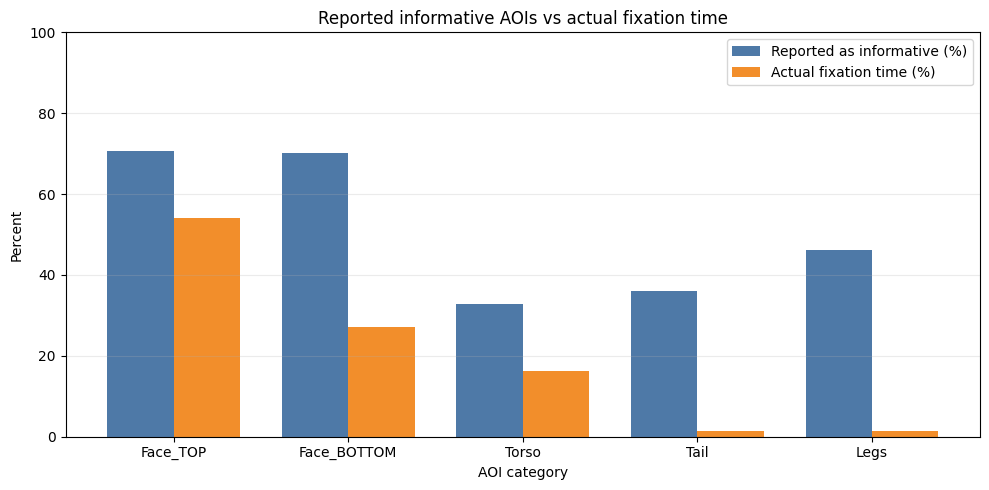

Saved: outputs/advanced_eye_tracking_analysis/reported_vs_actual_aoi_summary.png
Conclusion - reported vs actual AOI bar plot: Legs shows the largest reported-vs-actual gap: it was reported in 46.2% of usable participant-video rows, but accounted for only 1.3% of actual fixation time on average. This suggests participants may remember or report some cues as informative even when they did not spend much gaze time on them.


What this output shows - reported-actual agreement by video table: This table shows the percentage of participant-video rows where the actual dominant AOI was one of the AOI categories the participant reported as informative.


,video_number,dog_type,situation_type,rows,agreement_percent
0,1,Brachycephalic,Called by name,30,80.0
1,2,Normocephalic,Played with a ball,30,63.3
2,3,Brachycephalic,Abandoned by owner,30,76.7
3,4,Normocephalic,Threatened by stranger,30,50.0
4,5,Brachycephalic,Played with a ball,30,86.7
5,6,Normocephalic,Called by name,30,76.7
6,7,Brachycephalic,Threatened by stranger,30,63.3
7,8,Normocephalic,Abandoned by owner,28,64.3


Conclusion - reported-actual agreement by video table: Overall agreement is 70.2%. Agreement is highest for Video 5: Brachycephalic, Played with a ball (86.7%) and lowest for Video 4: Normocephalic, Threatened by stranger (50.0%).


What this output shows - reported-actual agreement by video plot: This bar chart shows whether self-reported informative cues matched the actual dominant AOI, separately for each video.


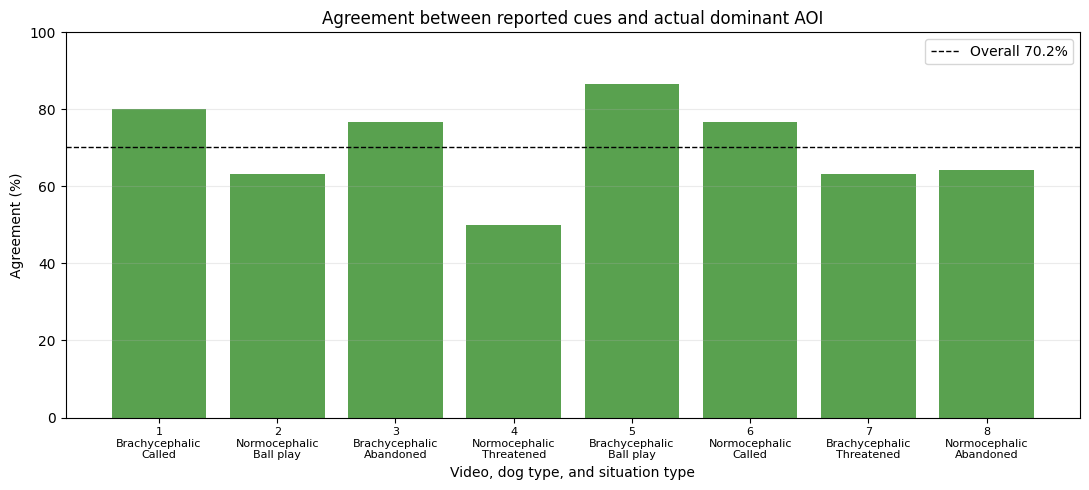

Saved: outputs/advanced_eye_tracking_analysis/reported_actual_agreement_by_video.png
Conclusion - reported-actual agreement by video plot: Overall agreement is 70.2%. Agreement is highest for Video 5: Brachycephalic, Played with a ball (86.7%) and lowest for Video 4: Normocephalic, Threatened by stranger (50.0%).


What this output shows - reported AOI by actual dominant AOI table: Rows are AOI categories selected in the questionnaire. Columns are the AOI that actually dominated fixation time. Because participants could select multiple cues, one participant-video row can contribute to more than one reported AOI row.


actual_dominant_AOI,Face_TOP,Face_BOTTOM,Torso,Tail,Legs
reported_AOI,,,,,
Face_TOP,109,38,20,1,0
Face_BOTTOM,105,45,16,1,0
Torso,40,26,12,0,0
Tail,50,24,11,1,0
Legs,65,33,11,1,0


Conclusion - reported AOI by actual dominant AOI table: The most frequent reported-actual pair is reported Face_TOP with actual dominant Face_TOP (109 mention-rows). The table also shows that participants often selected several facial regions together, so reported Face_TOP and Face_BOTTOM can both appear even when only one of them dominated actual gaze time.


What this output shows - reported AOI by actual dominant AOI heatmap: This heatmap makes the reported-vs-actual crosstab easier to scan. Darker cells mean more reported cue mentions for that actual dominant AOI.


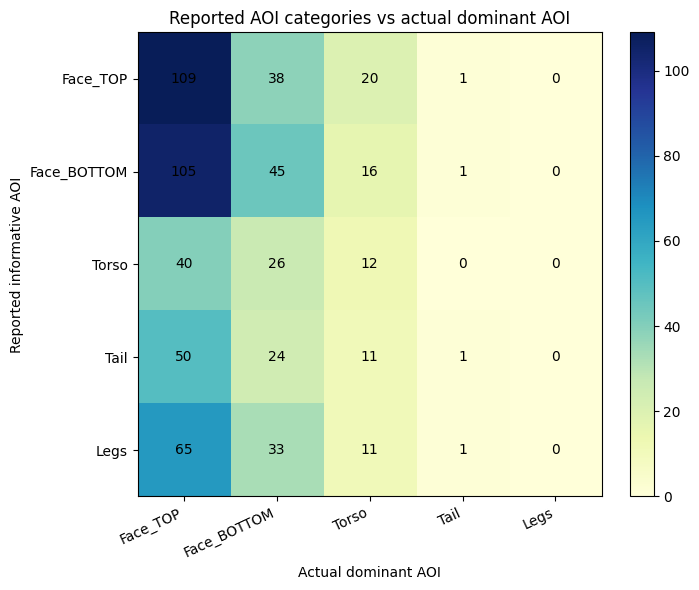

Saved: outputs/advanced_eye_tracking_analysis/reported_aoi_by_actual_dominant_aoi_heatmap.png
Conclusion - reported AOI by actual dominant AOI heatmap: The most frequent reported-actual pair is reported Face_TOP with actual dominant Face_TOP (109 mention-rows). The table also shows that participants often selected several facial regions together, so reported Face_TOP and Face_BOTTOM can both appear even when only one of them dominated actual gaze time.


What this output shows - reported-actual mismatch table: This table counts cases where the actual dominant AOI was not included in the participant reported informative AOI categories.


,actual_dominant_AOI,mismatch_count
0,Face_TOP,44
1,Face_BOTTOM,14
2,Torso,12
3,Tail,1


Conclusion - reported-actual mismatch table: The most common mismatch is actual dominant Face_TOP, with 44 rows where that AOI dominated gaze but was not reported as informative. These cases are useful because they show where eye-tracking and self-report tell different stories.


What this output shows - reported vs actual AOIs by dog type table: This table separates brachycephalic and normocephalic videos. For each dog type, it compares how often participants reported each AOI as informative with the actual average fixation-time percentage for that AOI.


,dog_type,AOI,reported_selected_percent,actual_mean_fixation_time_percent,reported_minus_actual_percentage_points
0,Brachycephalic,Face_TOP,80.8,59.3,21.5
1,Brachycephalic,Face_BOTTOM,68.3,26.7,41.6
2,Brachycephalic,Torso,22.5,12.9,9.6
3,Brachycephalic,Tail,12.5,0.0,12.5
4,Brachycephalic,Legs,40.8,1.0,39.8
5,Normocephalic,Face_TOP,60.2,48.8,11.4
6,Normocephalic,Face_BOTTOM,72.0,27.4,44.6
7,Normocephalic,Torso,43.2,19.7,23.6
8,Normocephalic,Tail,60.2,2.6,57.6
9,Normocephalic,Legs,51.7,1.5,50.2


Conclusion - reported vs actual AOIs by dog type table: The largest dog-type-specific gap is for Normocephalic Tail: reported in 60.2% of usable rows but only 2.6% of actual fixation time. This shows that the difference between remembered/reported cues and actual gaze is not equal across dog types.


What this output shows - actual AOI fixation time by dog type plot: This graph shows only where participants actually looked. For each AOI, the two bars compare brachycephalic and normocephalic videos using mean fixation-time percentage.


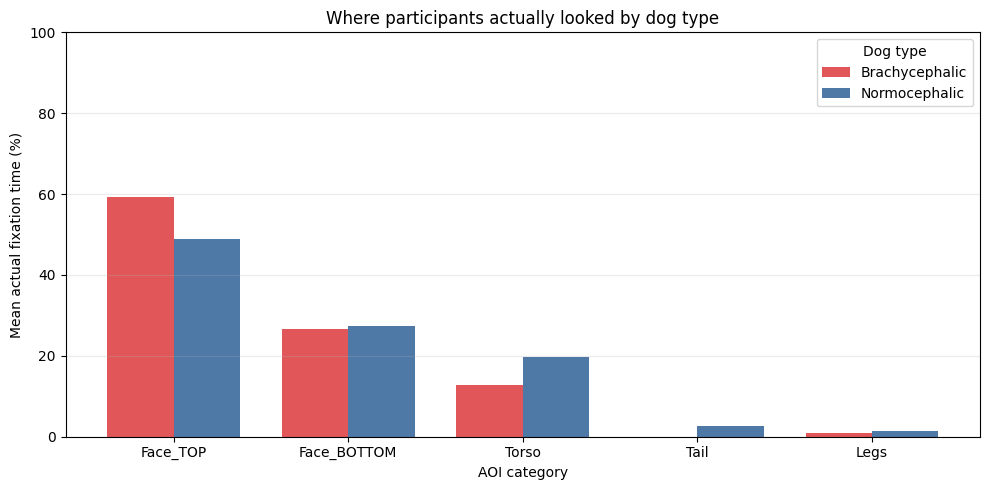

Saved: outputs/advanced_eye_tracking_analysis/actual_aoi_fixation_time_by_dog_type.png
Conclusion - actual AOI fixation time by dog type plot: The largest actual-looking dog-type difference is for Face_TOP: brachycephalic videos average 59.3% fixation time and normocephalic videos average 48.8%. Both dog types are still dominated by face looking, especially Face_TOP and Face_BOTTOM.


What this output shows - reported vs actual AOI use by dog type plot: This graph puts reported and actual AOI percentages on the same axis, separated by dog type. Each AOI has four bars: brachycephalic reported, brachycephalic actual, normocephalic reported, and normocephalic actual.


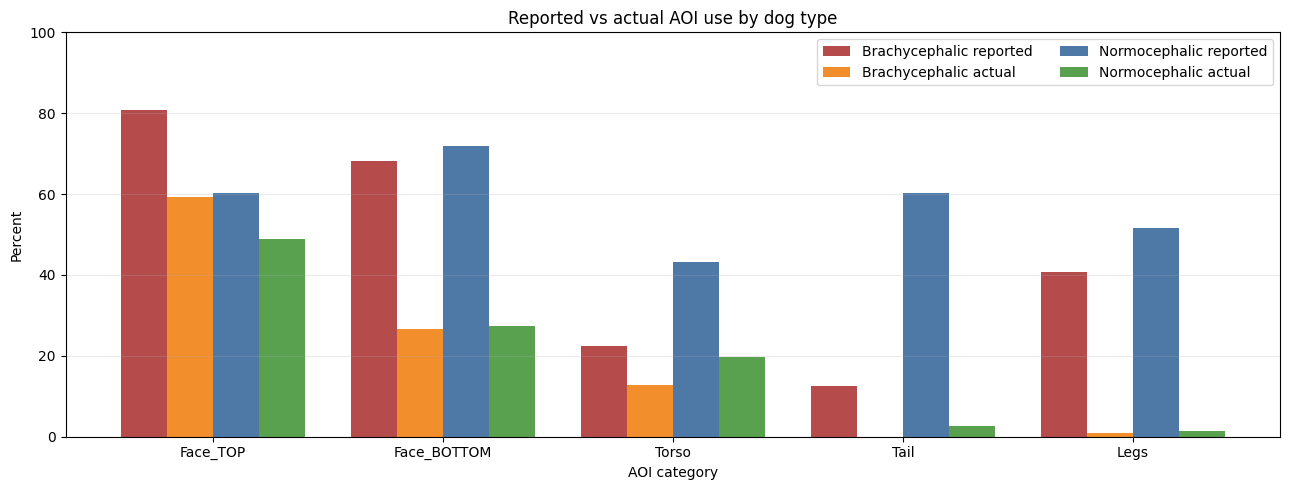

Saved: outputs/advanced_eye_tracking_analysis/reported_vs_actual_aoi_use_by_dog_type_combined.png
Conclusion - reported vs actual AOI use by dog type plot: This graph shows the clearest self-report vs gaze gap: body cues such as Tail and Legs are reported often, especially for normocephalic videos, but actual fixation time remains very low. Actual gaze is concentrated mainly on Face_TOP and Face_BOTTOM for both dog types.


What this output shows - top reported and actual AOI by video table: This table gives one row per video. It compares the AOI category most often reported as informative with the AOI that received the most actual fixation time.


,video_number,dog_type,situation_type,top_reported_AOI,top_reported_percent,top_actual_AOI,top_actual_fixation_time_percent,top_reported_matches_top_actual
0,1,Brachycephalic,Called by name,Face_TOP,86.7,Face_TOP,52.2,True
1,2,Normocephalic,Played with a ball,Face_BOTTOM,76.7,Face_BOTTOM,47.4,True
2,3,Brachycephalic,Abandoned by owner,Face_TOP,90.0,Face_TOP,57.0,True
3,4,Normocephalic,Threatened by stranger,Face_BOTTOM,76.7,Face_TOP,37.2,False
4,5,Brachycephalic,Played with a ball,Face_TOP,83.3,Face_TOP,77.4,True
5,6,Normocephalic,Called by name,Face_TOP,76.7,Face_TOP,64.4,True
6,7,Brachycephalic,Threatened by stranger,Face_BOTTOM,80.0,Face_TOP,50.7,False
7,8,Normocephalic,Abandoned by owner,Face_TOP,71.4,Face_TOP,58.2,True


Conclusion - top reported and actual AOI by video table: The top reported AOI matches the top actual fixation-time AOI in 6 of 8 videos. The main mismatches are Video 4 and Video 7, where participants most often reported Face_BOTTOM but actual fixation time was highest on Face_TOP.


What this output shows - reported vs actual AOIs by video table: This longer table keeps every video-AOI combination, making it possible to inspect exactly which AOIs were over-reported or under-reported for each video.


,video_number,dog_type,situation_type,AOI,reported_selected_percent,actual_mean_fixation_time_percent,reported_minus_actual_percentage_points
0,1,Brachycephalic,Called by name,Face_TOP,86.7,52.2,34.5
1,1,Brachycephalic,Called by name,Face_BOTTOM,63.3,41.6,21.8
2,1,Brachycephalic,Called by name,Torso,10.0,4.7,5.3
3,1,Brachycephalic,Called by name,Tail,0.0,0.2,-0.2
4,1,Brachycephalic,Called by name,Legs,10.0,1.3,8.7
5,2,Normocephalic,Played with a ball,Face_TOP,46.7,35.9,10.7
6,2,Normocephalic,Played with a ball,Face_BOTTOM,76.7,47.4,29.3
7,2,Normocephalic,Played with a ball,Torso,30.0,7.3,22.7
8,2,Normocephalic,Played with a ball,Tail,60.0,8.7,51.3
9,2,Normocephalic,Played with a ball,Legs,56.7,0.6,56.0


Conclusion - reported vs actual AOIs by video table: The largest video-level gap is Video 6 (Normocephalic, Called by name), AOI Tail: reported in 70.0% of rows but only 0.1% of actual fixation time.


What this output shows - reported and actual AOI heatmaps by video: These heatmaps compare questionnaire-reported AOIs and actual fixation-time AOIs for every video. Darker cells mean higher percentages.


/tmp/ipykernel_2879/3552929517.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


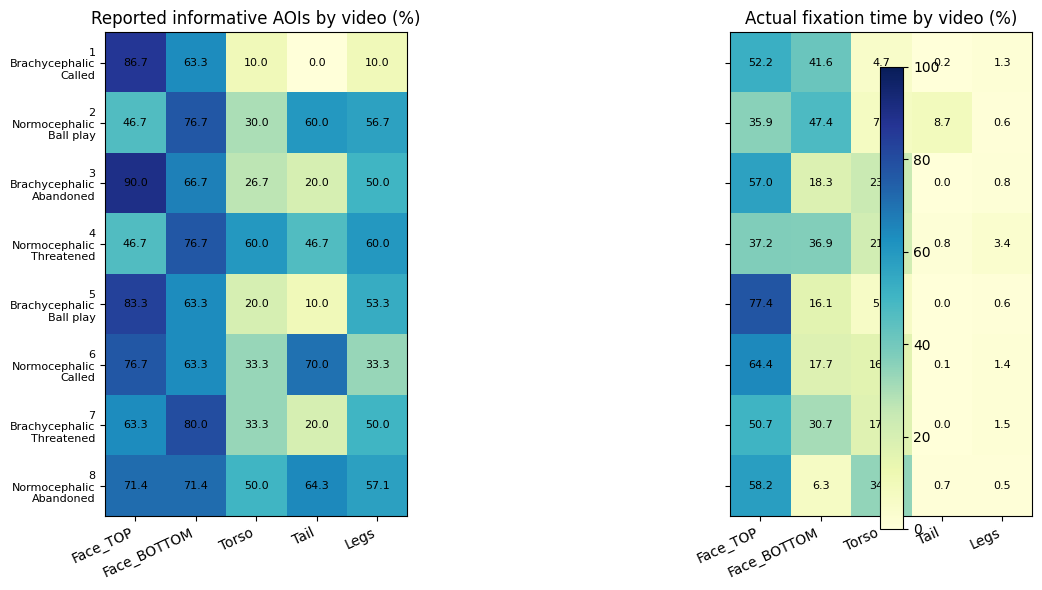

Saved: outputs/advanced_eye_tracking_analysis/reported_actual_aoi_heatmaps_by_video.png
Conclusion - reported and actual AOI heatmaps by video: The top reported AOI matches the top actual fixation-time AOI in 6 of 8 videos. The main mismatches are Video 4 and Video 7, where participants most often reported Face_BOTTOM but actual fixation time was highest on Face_TOP.


What this output shows - reported minus actual AOI gap heatmap by video: This heatmap subtracts actual fixation time from reported AOI selection. Positive values mean the AOI was reported more than it was actually fixated; negative values mean actual fixation was higher than report frequency.


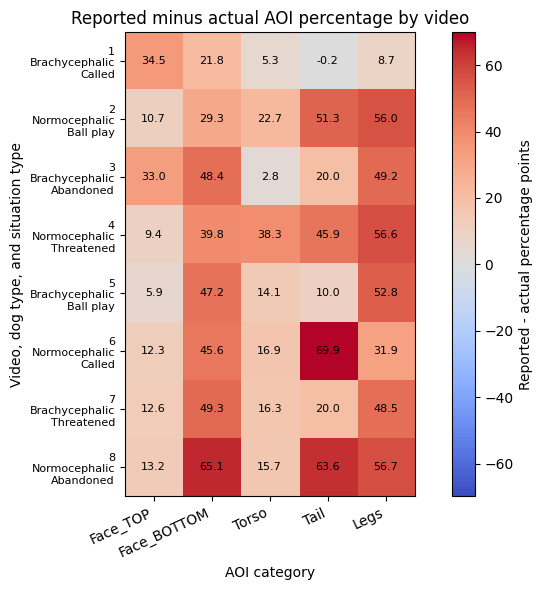

Saved: outputs/advanced_eye_tracking_analysis/reported_minus_actual_aoi_gap_by_video.png
Conclusion - reported minus actual AOI gap heatmap by video: The largest video-level gap is Video 6 (Normocephalic, Called by name), AOI Tail: reported in 70.0% of rows but only 0.1% of actual fixation time.



In [ ]:
# -----------------------------
# Reported looking cues vs actual eye-tracking AOIs
# -----------------------------
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPORTED_ACTUAL_AOI_ORDER = ['Face_TOP', 'Face_BOTTOM', 'Torso', 'Tail', 'Legs']

# These aliases map questionnaire feature text into the same AOI categories used
# for the eye-tracking data. Both English translated labels and original Hebrew
# labels are included so the code remains reusable if the translation step changes.
REPORTED_AOI_ALIASES = {
    'Face_TOP': [
        'right eye', 'left eye', 'eye', 'eyes',
        'right ear', 'left ear', 'ear', 'ears',
        'forehead',
        'עין ימין', 'עין שמאל', 'עיניים',
        'אוזן ימין', 'אוזן שמאל', 'אוזניים',
        'מצח',
    ],
    'Face_BOTTOM': [
        'right cheek', 'left cheek', 'cheek', 'cheeks',
        'snout area', 'snout', 'nose', 'mouth', 'nose + mouth',
        'לחי ימין', 'לחי שמאל', 'לחיים',
        'איזור החוטם', 'אזור החוטם', 'חוטם', 'אף', 'פה',
    ],
    'Torso': ['torso', 'body', 'טורסו', 'גוף'],
    'Tail': ['tail', 'זנב'],
    'Legs': ['front legs', 'back legs', 'legs', 'רגליים קדמיות', 'רגליים אחוריות', 'רגליים'],
}


def split_reported_feature_text(value):
    """Split a multi-select questionnaire answer into individual cue labels."""
    if pd.isna(value):
        return []
    parts = re.split(r'[,;]', str(value))
    return [part.strip().lower() for part in parts if part.strip()]


def normalize_reported_aoi_categories(value):
    """Map questionnaire cue labels into the normalized AOI categories."""
    parts = split_reported_feature_text(value)
    categories = []
    for category in REPORTED_ACTUAL_AOI_ORDER:
        aliases = [alias.lower() for alias in REPORTED_AOI_ALIASES[category]]
        if any(any(alias in part for alias in aliases) for part in parts):
            categories.append(category)
    return categories


def category_list_to_string(categories):
    if not categories:
        return 'None'
    return ', '.join(categories)


def add_reported_vs_actual_columns(df):
    """Add report-based AOI flags and actual fixation proportion columns."""
    df = df.copy()
    df['reported_AOI_categories'] = df['informative_facial_body_features'].apply(normalize_reported_aoi_categories)
    df['reported_AOI_categories_text'] = df['reported_AOI_categories'].apply(category_list_to_string)
    df['reported_AOI_count'] = df['reported_AOI_categories'].apply(len)

    for aoi in REPORTED_ACTUAL_AOI_ORDER:
        df[f'reported_{aoi}'] = df['reported_AOI_categories'].apply(lambda categories, aoi=aoi: aoi in categories)
        # For this comparison, an AOI that was not fixated in a row should count
        # as 0% fixation time, not as a missing value that gets ignored by the mean.
        df[f'actual_proportion_time_{aoi}'] = df['proportion_of_time_per_AOI'].apply(
            lambda value, aoi=aoi: value.get(aoi, 0) if isinstance(value, dict) else 0
        )

    df['actual_dominant_in_reported'] = df.apply(
        lambda row: row['dominant_AOI'] in row['reported_AOI_categories'] if pd.notna(row['dominant_AOI']) else pd.NA,
        axis=1,
    )
    return df


reported_actual_df = add_reported_vs_actual_columns(advanced_analysis_df)
reported_actual_valid = reported_actual_df.dropna(subset=['dominant_AOI']).copy()

# Table 1: overall comparison between reported AOI selection and actual fixation time.
reported_actual_summary = pd.DataFrame([
    {
        'AOI': aoi,
        'reported_selected_percent': reported_actual_valid[f'reported_{aoi}'].mean() * 100,
        'actual_mean_fixation_time_percent': reported_actual_valid[f'actual_proportion_time_{aoi}'].mean() * 100,
    }
    for aoi in REPORTED_ACTUAL_AOI_ORDER
])
reported_actual_summary['reported_minus_actual_percentage_points'] = (
    reported_actual_summary['reported_selected_percent']
    - reported_actual_summary['actual_mean_fixation_time_percent']
)
for column in [
    'reported_selected_percent',
    'actual_mean_fixation_time_percent',
    'reported_minus_actual_percentage_points',
]:
    reported_actual_summary[column] = reported_actual_summary[column].round(1)

explain_before(
    'reported vs actual AOI summary table',
    'This table compares how often participants reported each AOI category as informative with the actual average percentage of fixation time spent on that AOI. Actual fixation averages count an absent AOI as 0%, which is the correct denominator for comparing AOIs across all participant-video rows. Reported selections can add to more than 100% because participants could choose multiple cues.',
)
display(reported_actual_summary)
largest_gap_row = reported_actual_summary.loc[reported_actual_summary['reported_minus_actual_percentage_points'].abs().idxmax()]
reported_actual_summary_conclusion = (
    f"{largest_gap_row['AOI']} shows the largest reported-vs-actual gap: it was reported in "
    f"{largest_gap_row['reported_selected_percent']:.1f}% of usable participant-video rows, but accounted for only "
    f"{largest_gap_row['actual_mean_fixation_time_percent']:.1f}% of actual fixation time on average. "
    'This suggests participants may remember or report some cues as informative even when they did not spend much gaze time on them.'
)
explain_output(
    'reported vs actual AOI summary table',
    'This table compares how often participants reported each AOI category as informative with the actual average percentage of fixation time spent on that AOI. Actual fixation averages count absent AOIs as 0%.',
    reported_actual_summary_conclusion,
)

fig, ax = plt.subplots(figsize=(10, 5))
plot_summary = reported_actual_summary.set_index('AOI')[['reported_selected_percent', 'actual_mean_fixation_time_percent']]
x_positions = np.arange(len(plot_summary.index))
bar_width = 0.38
ax.bar(x_positions - bar_width / 2, plot_summary['reported_selected_percent'], width=bar_width, color='#4E79A7', label='Reported as informative (%)')
ax.bar(x_positions + bar_width / 2, plot_summary['actual_mean_fixation_time_percent'], width=bar_width, color='#F28E2B', label='Actual fixation time (%)')
ax.set_title('Reported informative AOIs vs actual fixation time')
ax.set_xlabel('AOI category')
ax.set_ylabel('Percent')
ax.set_ylim(0, max(100, plot_summary.max().max() + 10))
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_summary.index)
ax.legend(loc='upper right')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
explain_before(
    'reported vs actual AOI bar plot',
    'This bar chart visualizes the same summary table. Blue shows questionnaire selections; orange shows actual fixation-time proportions.',
)
save_and_show_advanced(fig, 'reported_vs_actual_aoi_summary.png')
explain_output(
    'reported vs actual AOI bar plot',
    'This bar chart visualizes the same summary table. Blue shows questionnaire selections; orange shows actual fixation-time proportions.',
    reported_actual_summary_conclusion,
)

# Table/plot 2: agreement by video. Agreement means the actual dominant AOI was
# included in the participant's reported informative AOI categories.
overall_reported_actual_agreement = reported_actual_valid['actual_dominant_in_reported'].mean() * 100
reported_actual_agreement_by_video = reported_actual_valid.groupby(['video_number', 'dog_type', 'situation_type']).agg(
    rows=('participant_id', 'count'),
    agreement_percent=('actual_dominant_in_reported', lambda values: values.mean() * 100),
).reset_index()
reported_actual_agreement_by_video['agreement_percent'] = reported_actual_agreement_by_video['agreement_percent'].round(1)

explain_before(
    'reported-actual agreement by video table',
    'This table shows the percentage of participant-video rows where the actual dominant AOI was one of the AOI categories the participant reported as informative.',
)
display(reported_actual_agreement_by_video)
best_agreement, worst_agreement = best_and_worst_by_column(reported_actual_agreement_by_video, 'video_number', 'agreement_percent')
agreement_conclusion = (
    f"Overall agreement is {overall_reported_actual_agreement:.1f}%. "
    f"Agreement is highest for {video_sentence_label(best_agreement['video_number'])} "
    f"({best_agreement['agreement_percent']:.1f}%) and lowest for {video_sentence_label(worst_agreement['video_number'])} "
    f"({worst_agreement['agreement_percent']:.1f}%)."
)
explain_output(
    'reported-actual agreement by video table',
    'This table shows the percentage of participant-video rows where the actual dominant AOI was one of the AOI categories the participant reported as informative.',
    agreement_conclusion,
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(reported_actual_agreement_by_video['video_number'], reported_actual_agreement_by_video['agreement_percent'], color='#59A14F')
ax.axhline(overall_reported_actual_agreement, color='black', linestyle='--', linewidth=1, label=f'Overall {overall_reported_actual_agreement:.1f}%')
ax.set_title('Agreement between reported cues and actual dominant AOI')
ax.set_xlabel('Video, dog type, and situation type')
ax.set_ylabel('Agreement (%)')
ax.set_ylim(0, 100)
ax.set_xticks(reported_actual_agreement_by_video['video_number'])
ax.set_xticklabels([video_tick_label(video) for video in reported_actual_agreement_by_video['video_number']], fontsize=8)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.25)
explain_before(
    'reported-actual agreement by video plot',
    'This bar chart shows whether self-reported informative cues matched the actual dominant AOI, separately for each video.',
)
save_and_show_advanced(fig, 'reported_actual_agreement_by_video.png')
explain_output(
    'reported-actual agreement by video plot',
    'This bar chart shows whether self-reported informative cues matched the actual dominant AOI, separately for each video.',
    agreement_conclusion,
)

# Table/plot 3: heatmap of reported AOI mentions versus actual dominant AOI.
reported_mentions_rows = []
for _, row in reported_actual_valid.iterrows():
    for reported_aoi in row['reported_AOI_categories']:
        reported_mentions_rows.append({
            'reported_AOI': reported_aoi,
            'actual_dominant_AOI': row['dominant_AOI'],
        })
reported_mentions_df = pd.DataFrame(reported_mentions_rows)
reported_vs_actual_crosstab = pd.crosstab(
    reported_mentions_df['reported_AOI'],
    reported_mentions_df['actual_dominant_AOI'],
).reindex(index=REPORTED_ACTUAL_AOI_ORDER, columns=REPORTED_ACTUAL_AOI_ORDER, fill_value=0)

explain_before(
    'reported AOI by actual dominant AOI table',
    'Rows are AOI categories selected in the questionnaire. Columns are the AOI that actually dominated fixation time. Because participants could select multiple cues, one participant-video row can contribute to more than one reported AOI row.',
)
display(reported_vs_actual_crosstab)
stacked_counts = reported_vs_actual_crosstab.stack()
if not stacked_counts.empty:
    top_reported_aoi, top_actual_aoi = stacked_counts.idxmax()
    top_pair_count = int(stacked_counts.max())
    crosstab_conclusion = (
        f'The most frequent reported-actual pair is reported {top_reported_aoi} with actual dominant {top_actual_aoi} '
        f'({top_pair_count} mention-rows). The table also shows that participants often selected several facial regions together, so reported Face_TOP and Face_BOTTOM can both appear even when only one of them dominated actual gaze time.'
    )
else:
    crosstab_conclusion = 'No reported AOI mentions were available for the crosstab.'
explain_output(
    'reported AOI by actual dominant AOI table',
    'Rows are AOI categories selected in the questionnaire. Columns are the AOI that actually dominated fixation time.',
    crosstab_conclusion,
)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(reported_vs_actual_crosstab.values, cmap='YlGnBu')
ax.set_title('Reported AOI categories vs actual dominant AOI')
ax.set_xlabel('Actual dominant AOI')
ax.set_ylabel('Reported informative AOI')
ax.set_xticks(range(len(reported_vs_actual_crosstab.columns)))
ax.set_yticks(range(len(reported_vs_actual_crosstab.index)))
ax.set_xticklabels(reported_vs_actual_crosstab.columns, rotation=25, ha='right')
ax.set_yticklabels(reported_vs_actual_crosstab.index)
for row_idx in range(reported_vs_actual_crosstab.shape[0]):
    for col_idx in range(reported_vs_actual_crosstab.shape[1]):
        ax.text(col_idx, row_idx, int(reported_vs_actual_crosstab.iloc[row_idx, col_idx]), ha='center', va='center')
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
explain_before(
    'reported AOI by actual dominant AOI heatmap',
    'This heatmap makes the reported-vs-actual crosstab easier to scan. Darker cells mean more reported cue mentions for that actual dominant AOI.',
)
save_and_show_advanced(fig, 'reported_aoi_by_actual_dominant_aoi_heatmap.png')
explain_output(
    'reported AOI by actual dominant AOI heatmap',
    'This heatmap makes the reported-vs-actual crosstab easier to scan. Darker cells mean more reported cue mentions for that actual dominant AOI.',
    crosstab_conclusion,
)

# Table 4: mismatch inspection. This shows which actual dominant AOIs were most
# often missing from the participant's self-reported informative cues.
reported_actual_mismatches = reported_actual_valid[reported_actual_valid['actual_dominant_in_reported'] == False].copy()
reported_actual_mismatch_counts = reported_actual_mismatches['dominant_AOI'].value_counts().rename_axis('actual_dominant_AOI').reset_index(name='mismatch_count')

explain_before(
    'reported-actual mismatch table',
    'This table counts cases where the actual dominant AOI was not included in the participant reported informative AOI categories.',
)
display(reported_actual_mismatch_counts)
if not reported_actual_mismatch_counts.empty:
    top_mismatch = reported_actual_mismatch_counts.iloc[0]
    mismatch_conclusion = (
        f"The most common mismatch is actual dominant {top_mismatch['actual_dominant_AOI']}, "
        f"with {int(top_mismatch['mismatch_count'])} rows where that AOI dominated gaze but was not reported as informative. "
        'These cases are useful because they show where eye-tracking and self-report tell different stories.'
    )
else:
    mismatch_conclusion = 'There were no rows where the actual dominant AOI was missing from the reported informative AOIs.'
explain_output(
    'reported-actual mismatch table',
    'This table counts cases where the actual dominant AOI was not included in the participant reported informative AOI categories.',
    mismatch_conclusion,
)

# Table/plot 5: reported vs actual AOIs by dog type.
reported_actual_by_dog_type_rows = []
for dog_type, group in reported_actual_valid.groupby('dog_type'):
    for aoi in REPORTED_ACTUAL_AOI_ORDER:
        reported_percent = group[f'reported_{aoi}'].mean() * 100
        actual_percent = group[f'actual_proportion_time_{aoi}'].mean() * 100
        reported_actual_by_dog_type_rows.append({
            'dog_type': dog_type,
            'AOI': aoi,
            'reported_selected_percent': reported_percent,
            'actual_mean_fixation_time_percent': actual_percent,
            'reported_minus_actual_percentage_points': reported_percent - actual_percent,
        })
reported_actual_by_dog_type = pd.DataFrame(reported_actual_by_dog_type_rows)
for column in ['reported_selected_percent', 'actual_mean_fixation_time_percent', 'reported_minus_actual_percentage_points']:
    reported_actual_by_dog_type[column] = reported_actual_by_dog_type[column].round(1)

explain_before(
    'reported vs actual AOIs by dog type table',
    'This table separates brachycephalic and normocephalic videos. For each dog type, it compares how often participants reported each AOI as informative with the actual average fixation-time percentage for that AOI.',
)
display(reported_actual_by_dog_type)
dog_gap_row = reported_actual_by_dog_type.loc[reported_actual_by_dog_type['reported_minus_actual_percentage_points'].abs().idxmax()]
dog_type_conclusion = (
    f"The largest dog-type-specific gap is for {dog_gap_row['dog_type']} {dog_gap_row['AOI']}: "
    f"reported in {dog_gap_row['reported_selected_percent']:.1f}% of usable rows but only "
    f"{dog_gap_row['actual_mean_fixation_time_percent']:.1f}% of actual fixation time. "
    'This shows that the difference between remembered/reported cues and actual gaze is not equal across dog types.'
)
explain_output(
    'reported vs actual AOIs by dog type table',
    'This table separates brachycephalic and normocephalic videos and compares reported AOIs with actual fixation time.',
    dog_type_conclusion,
)

# Actual-looking-only graph requested for dog type comparison.
actual_by_dog_type = reported_actual_by_dog_type.pivot(
    index='AOI',
    columns='dog_type',
    values='actual_mean_fixation_time_percent',
).reindex(index=REPORTED_ACTUAL_AOI_ORDER, columns=['Brachycephalic', 'Normocephalic'])
actual_by_dog_type['absolute_difference'] = (actual_by_dog_type['Brachycephalic'] - actual_by_dog_type['Normocephalic']).abs()
actual_difference_row = actual_by_dog_type['absolute_difference'].idxmax()
actual_dog_type_conclusion = (
    f"The largest actual-looking dog-type difference is for {actual_difference_row}: "
    f"brachycephalic videos average {actual_by_dog_type.loc[actual_difference_row, 'Brachycephalic']:.1f}% fixation time and "
    f"normocephalic videos average {actual_by_dog_type.loc[actual_difference_row, 'Normocephalic']:.1f}%. "
    'Both dog types are still dominated by face looking, especially Face_TOP and Face_BOTTOM.'
)

fig, ax = plt.subplots(figsize=(10, 5))
plot_actual = actual_by_dog_type.drop(columns='absolute_difference')
x_positions = np.arange(len(plot_actual.index))
bar_width = 0.38
ax.bar(x_positions - bar_width / 2, plot_actual['Brachycephalic'], width=bar_width, color='#E15759', label='Brachycephalic')
ax.bar(x_positions + bar_width / 2, plot_actual['Normocephalic'], width=bar_width, color='#4E79A7', label='Normocephalic')
ax.set_title('Where participants actually looked by dog type')
ax.set_xlabel('AOI category')
ax.set_ylabel('Mean actual fixation time (%)')
ax.set_ylim(0, 100)
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_actual.index, rotation=0)
ax.legend(title='Dog type')
ax.grid(axis='y', alpha=0.25)
explain_before(
    'actual AOI fixation time by dog type plot',
    'This graph shows only where participants actually looked. For each AOI, the two bars compare brachycephalic and normocephalic videos using mean fixation-time percentage.',
)
save_and_show_advanced(fig, 'actual_aoi_fixation_time_by_dog_type.png')
explain_output(
    'actual AOI fixation time by dog type plot',
    'This graph shows only where participants actually looked. For each AOI, the two bars compare brachycephalic and normocephalic videos.',
    actual_dog_type_conclusion,
)

# Combined graph: reported and actual looking, split by dog type.
combined_dog_type_plot = reported_actual_by_dog_type.set_index(['AOI', 'dog_type']).reindex(
    pd.MultiIndex.from_product([REPORTED_ACTUAL_AOI_ORDER, ['Brachycephalic', 'Normocephalic']], names=['AOI', 'dog_type'])
).reset_index()
fig, ax = plt.subplots(figsize=(13, 5))
x_positions = np.arange(len(REPORTED_ACTUAL_AOI_ORDER))
bar_width = 0.20
series_specs = [
    ('Brachycephalic', 'reported_selected_percent', -1.5 * bar_width, '#B64B4B', 'Brachycephalic reported'),
    ('Brachycephalic', 'actual_mean_fixation_time_percent', -0.5 * bar_width, '#F28E2B', 'Brachycephalic actual'),
    ('Normocephalic', 'reported_selected_percent', 0.5 * bar_width, '#4E79A7', 'Normocephalic reported'),
    ('Normocephalic', 'actual_mean_fixation_time_percent', 1.5 * bar_width, '#59A14F', 'Normocephalic actual'),
]
for dog_type, value_column, offset, color, label in series_specs:
    values = combined_dog_type_plot[combined_dog_type_plot['dog_type'] == dog_type].set_index('AOI').reindex(REPORTED_ACTUAL_AOI_ORDER)[value_column]
    ax.bar(x_positions + offset, values, width=bar_width, color=color, label=label)
ax.set_title('Reported vs actual AOI use by dog type')
ax.set_xlabel('AOI category')
ax.set_ylabel('Percent')
ax.set_ylim(0, 100)
ax.set_xticks(x_positions)
ax.set_xticklabels(REPORTED_ACTUAL_AOI_ORDER, rotation=0)
ax.legend(ncol=2, loc='upper right')
ax.grid(axis='y', alpha=0.25)
reported_actual_dog_type_conclusion = (
    'This graph shows the clearest self-report vs gaze gap: body cues such as Tail and Legs are reported often, especially for normocephalic videos, '
    'but actual fixation time remains very low. Actual gaze is concentrated mainly on Face_TOP and Face_BOTTOM for both dog types.'
)
explain_before(
    'reported vs actual AOI use by dog type plot',
    'This graph puts reported and actual AOI percentages on the same axis, separated by dog type. Each AOI has four bars: brachycephalic reported, brachycephalic actual, normocephalic reported, and normocephalic actual.',
)
save_and_show_advanced(fig, 'reported_vs_actual_aoi_use_by_dog_type_combined.png')
explain_output(
    'reported vs actual AOI use by dog type plot',
    'This graph puts reported and actual AOI percentages on the same axis, separated by dog type.',
    reported_actual_dog_type_conclusion,
)

# Table/plots 6: reported vs actual AOIs by individual video.
reported_actual_by_video_rows = []
for (video_number, dog_type, situation_type), group in reported_actual_valid.groupby(['video_number', 'dog_type', 'situation_type']):
    for aoi in REPORTED_ACTUAL_AOI_ORDER:
        reported_percent = group[f'reported_{aoi}'].mean() * 100
        actual_percent = group[f'actual_proportion_time_{aoi}'].mean() * 100
        reported_actual_by_video_rows.append({
            'video_number': video_number,
            'dog_type': dog_type,
            'situation_type': situation_type,
            'AOI': aoi,
            'reported_selected_percent': reported_percent,
            'actual_mean_fixation_time_percent': actual_percent,
            'reported_minus_actual_percentage_points': reported_percent - actual_percent,
        })
reported_actual_by_video = pd.DataFrame(reported_actual_by_video_rows)
for column in ['reported_selected_percent', 'actual_mean_fixation_time_percent', 'reported_minus_actual_percentage_points']:
    reported_actual_by_video[column] = reported_actual_by_video[column].round(1)

video_top_comparison_rows = []
for (video_number, dog_type, situation_type), group in reported_actual_valid.groupby(['video_number', 'dog_type', 'situation_type']):
    reported_means = {aoi: group[f'reported_{aoi}'].mean() * 100 for aoi in REPORTED_ACTUAL_AOI_ORDER}
    actual_means = {aoi: group[f'actual_proportion_time_{aoi}'].mean() * 100 for aoi in REPORTED_ACTUAL_AOI_ORDER}
    top_reported_aoi = max(reported_means, key=reported_means.get)
    top_actual_aoi = max(actual_means, key=actual_means.get)
    video_top_comparison_rows.append({
        'video_number': video_number,
        'dog_type': dog_type,
        'situation_type': situation_type,
        'top_reported_AOI': top_reported_aoi,
        'top_reported_percent': reported_means[top_reported_aoi],
        'top_actual_AOI': top_actual_aoi,
        'top_actual_fixation_time_percent': actual_means[top_actual_aoi],
        'top_reported_matches_top_actual': top_reported_aoi == top_actual_aoi,
    })
video_top_reported_actual = pd.DataFrame(video_top_comparison_rows)
for column in ['top_reported_percent', 'top_actual_fixation_time_percent']:
    video_top_reported_actual[column] = video_top_reported_actual[column].round(1)

explain_before(
    'top reported and actual AOI by video table',
    'This table gives one row per video. It compares the AOI category most often reported as informative with the AOI that received the most actual fixation time.',
)
display(video_top_reported_actual)
matching_top_count = int(video_top_reported_actual['top_reported_matches_top_actual'].sum())
video_top_conclusion = (
    f'The top reported AOI matches the top actual fixation-time AOI in {matching_top_count} of 8 videos. '
    'The main mismatches are Video 4 and Video 7, where participants most often reported Face_BOTTOM but actual fixation time was highest on Face_TOP.'
)
explain_output(
    'top reported and actual AOI by video table',
    'This table gives one row per video and compares the top reported AOI with the top actual AOI.',
    video_top_conclusion,
)

explain_before(
    'reported vs actual AOIs by video table',
    'This longer table keeps every video-AOI combination, making it possible to inspect exactly which AOIs were over-reported or under-reported for each video.',
)
display(reported_actual_by_video)
video_gap_row = reported_actual_by_video.loc[reported_actual_by_video['reported_minus_actual_percentage_points'].abs().idxmax()]
video_gap_conclusion = (
    f"The largest video-level gap is Video {int(video_gap_row['video_number'])} ({video_gap_row['dog_type']}, {video_gap_row['situation_type']}), "
    f"AOI {video_gap_row['AOI']}: reported in {video_gap_row['reported_selected_percent']:.1f}% of rows but only "
    f"{video_gap_row['actual_mean_fixation_time_percent']:.1f}% of actual fixation time."
)
explain_output(
    'reported vs actual AOIs by video table',
    'This longer table keeps every video-AOI combination, making it possible to inspect over-reporting and under-reporting by video.',
    video_gap_conclusion,
)

video_index_order = sorted(reported_actual_by_video['video_number'].unique())
video_y_labels = [video_tick_label(video) for video in video_index_order]
reported_video_matrix = reported_actual_by_video.pivot(index='video_number', columns='AOI', values='reported_selected_percent').reindex(index=video_index_order, columns=REPORTED_ACTUAL_AOI_ORDER)
actual_video_matrix = reported_actual_by_video.pivot(index='video_number', columns='AOI', values='actual_mean_fixation_time_percent').reindex(index=video_index_order, columns=REPORTED_ACTUAL_AOI_ORDER)
gap_video_matrix = reported_actual_by_video.pivot(index='video_number', columns='AOI', values='reported_minus_actual_percentage_points').reindex(index=video_index_order, columns=REPORTED_ACTUAL_AOI_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, matrix, title in [
    (axes[0], reported_video_matrix, 'Reported informative AOIs by video (%)'),
    (axes[1], actual_video_matrix, 'Actual fixation time by video (%)'),
]:
    image = ax.imshow(matrix.values.astype(float), cmap='YlGnBu', vmin=0, vmax=100)
    ax.set_title(title)
    ax.set_xticks(range(len(REPORTED_ACTUAL_AOI_ORDER)))
    ax.set_xticklabels(REPORTED_ACTUAL_AOI_ORDER, rotation=25, ha='right')
    ax.set_yticks(range(len(video_index_order)))
    ax.set_yticklabels(video_y_labels, fontsize=8)
    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            value = matrix.iloc[row_idx, col_idx]
            ax.text(col_idx, row_idx, f'{value:.1f}', ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=axes.ravel().tolist(), fraction=0.025, pad=0.03)
explain_before(
    'reported and actual AOI heatmaps by video',
    'These heatmaps compare questionnaire-reported AOIs and actual fixation-time AOIs for every video. Darker cells mean higher percentages.',
)
save_and_show_advanced(fig, 'reported_actual_aoi_heatmaps_by_video.png')
explain_output(
    'reported and actual AOI heatmaps by video',
    'These heatmaps compare questionnaire-reported AOIs and actual fixation-time AOIs for every video. Darker cells mean higher percentages.',
    video_top_conclusion,
)

fig, ax = plt.subplots(figsize=(10, 6))
max_abs_gap = np.nanmax(np.abs(gap_video_matrix.values.astype(float)))
image = ax.imshow(gap_video_matrix.values.astype(float), cmap='coolwarm', vmin=-max_abs_gap, vmax=max_abs_gap)
ax.set_title('Reported minus actual AOI percentage by video')
ax.set_xlabel('AOI category')
ax.set_ylabel('Video, dog type, and situation type')
ax.set_xticks(range(len(REPORTED_ACTUAL_AOI_ORDER)))
ax.set_xticklabels(REPORTED_ACTUAL_AOI_ORDER, rotation=25, ha='right')
ax.set_yticks(range(len(video_index_order)))
ax.set_yticklabels(video_y_labels, fontsize=8)
for row_idx in range(gap_video_matrix.shape[0]):
    for col_idx in range(gap_video_matrix.shape[1]):
        value = gap_video_matrix.iloc[row_idx, col_idx]
        ax.text(col_idx, row_idx, f'{value:.1f}', ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label='Reported - actual percentage points')
explain_before(
    'reported minus actual AOI gap heatmap by video',
    'This heatmap subtracts actual fixation time from reported AOI selection. Positive values mean the AOI was reported more than it was actually fixated; negative values mean actual fixation was higher than report frequency.',
)
save_and_show_advanced(fig, 'reported_minus_actual_aoi_gap_by_video.png')
explain_output(
    'reported minus actual AOI gap heatmap by video',
    'This heatmap subtracts actual fixation time from reported AOI selection for every video and AOI.',
    video_gap_conclusion,
)



### Concrete conclusions from reported-vs-actual looking outputs

**Overall reported vs actual AOIs.** Participants reported many AOIs as informative, but those reports did not always match the amount of time they actually looked there. The largest differences were for body cues: `Legs` were reported in `46.2%` of usable participant-video rows but accounted for only `1.3%` of fixation time, and `Tail` was reported in `36.1%` of rows but accounted for only `1.3%` of fixation time. This suggests participants may mention salient body cues even when their gaze time was mostly on the face.

**Face regions.** `Face_TOP` was both frequently reported (`70.6%`) and heavily looked at (`54.1%` of fixation time). `Face_BOTTOM` was reported almost as often (`70.2%`) but received less actual fixation time (`27.1%`). This means lower-face cues were often considered informative by participants, even when upper-face looking dominated the eye-tracking data.

**Reported-actual agreement by video.** Overall, the actual dominant AOI appeared in the participant reported cue list in `70.2%` of usable rows. Agreement was highest in Video 5, the brachycephalic ball-play video (`86.7%`), and lowest in Video 4, the normocephalic threatened-by-stranger video (`50.0%`). This means self-report matched gaze better for some situations than others.

**Reported AOI vs actual dominant AOI heatmap.** The most common reported-actual pair was reported `Face_TOP` with actual dominant `Face_TOP` (`109` mention-rows). However, reported `Face_BOTTOM` also appeared very often when actual dominant AOI was `Face_TOP` (`105` mention-rows), showing that participants frequently selected multiple face regions even when their gaze was dominated by only one.

**Mismatch table.** The most common mismatch was actual dominant `Face_TOP`: there were `44` rows where `Face_TOP` dominated gaze but was not included in the participant reported informative cues. This is important because it shows that self-report cannot fully replace eye-tracking; participants do not always accurately report the region that dominated their gaze.


**Dog-type comparison.** The actual-looking-only dog-type graph shows that both dog types are dominated by face looking. Brachycephalic videos have higher `Face_TOP` fixation time (`59.3%`) than normocephalic videos (`48.8%`), while normocephalic videos show slightly more `Torso` looking (`19.7%` vs `12.9%`). In the combined reported-vs-actual dog-type graph, the largest gap appears for normocephalic `Tail`: participants reported tail cues in `60.2%` of usable normocephalic rows, but actual tail fixation time was only `2.6%`. This suggests that participants often mention body cues, especially for normocephalic dogs, even though their gaze remains mostly on the face.

**Video-level top AOIs.** The most reported AOI and the most actually fixated AOI match in `6` of the `8` videos. The main exceptions are Video 4 (`Normocephalic`, threatened by stranger) and Video 7 (`Brachycephalic`, threatened by stranger): in both videos, participants most often reported `Face_BOTTOM`, but actual fixation time was highest on `Face_TOP`. This is interesting because threat-related videos may make participants report lower-face cues such as snout/mouth, even while their eyes spend more time on the upper face.

**Video-level gap heatmap.** The largest single video-AOI gap is Video 6 (`Normocephalic`, called by name), where `Tail` was reported in `70.0%` of rows but accounted for only `0.1%` of fixation time. Video 8 also shows a large `Face_BOTTOM` gap (`71.4%` reported vs `6.3%` actual). These gaps show why the self-report and eye-tracking data should be analyzed together: participants may identify a cue as meaningful after watching the video even if it was not where they spent most fixation time.


### Concrete conclusions from the scanpath, accuracy, and gaze-behavior outputs

**Scanpath sequence preview.** The scanpath examples show that participants often moved repeatedly between `Face_TOP` and `Face_BOTTOM`, especially in the first videos. This supports the decision to split the face into top and bottom regions, because those two areas appear as separate parts of the scanpath rather than one uniform “head” region.

**Scanpath similarity by video.** Video 1, the brachycephalic dog being called by name, has the highest mean scanpath similarity (`0.567`). This suggests that participants used relatively similar gaze strategies for that video. Video 2, the normocephalic dog playing with a ball, has the lowest mean similarity (`0.396`), suggesting more varied gaze strategies across participants.

**Scanpath similarity plot.** The plot confirms the same pattern visually: scanpaths were most consistent for Video 1 and least consistent for Video 2. A possible interpretation is that the “called by name” brachycephalic video guided viewers toward similar facial cues, while the ball-play normocephalic video allowed more diverse viewing behavior.

**Scanpath distance matrix heatmaps.** The heatmaps are useful for finding participant pairs with similar or unusual scanpaths. Darker clusters indicate participants with similar AOI sequences. Isolated lighter areas would indicate participants whose gaze pattern was different from most others. These plots are exploratory rather than a single statistical conclusion, but they can help identify outlier participants or videos with more heterogeneous viewing strategies.

**Dog ownership group summary and plots.** The table shows only small differences between dog-ownership groups in the main gaze metrics. Participants with dog experience had a slightly higher mean fixation count (`16.45` vs `15.64`), while participants without dog experience had a slightly higher mean number of unique AOIs visited (`2.96` vs `2.87`). This suggests dog ownership does not create a large obvious shift in gaze behavior in this dataset.

**Gender group summary and plots.** Female participants had a higher mean fixation count (`18.04`) than male participants (`15.61`), while male participants had a longer mean fixation duration (`473.73 ms` vs `373.77 ms`). This may indicate that female participants made more fixations, while male participants tended to fixate longer. Because the group sizes are uneven (`48` female rows vs `190` male rows with gaze), this should be treated cautiously.

**Gaze metrics by perceived emotion.** Neutral was the most common perceived emotion category (`63` rows), followed closely by somewhat positive (`62`) and somewhat negative (`60`). More negative categories tended to have more AOI transitions: somewhat negative responses averaged `7.59` transitions, completely negative averaged `7.40`, while completely positive averaged only `4.64`. This suggests that negative interpretations may involve more active visual scanning or uncertainty.

**AOI transitions by perceived emotion plot.** The plot supports the table: negative or uncertain emotional interpretations show higher switching between AOIs than completely positive interpretations. This can be interpreted as participants needing to inspect more regions when the dog’s emotion is negative or harder to interpret.

**Face_TOP looking by situation answer plot.** Participants who selected “Do not know / cannot identify” had the highest mean Face_TOP proportion (`0.755`), but this category has only 4 rows, so it should not be overinterpreted. Among common categories, somewhat positive responses had relatively high Face_TOP looking (`0.637`), while completely positive responses had lower Face_TOP looking (`0.488`) and higher Face_BOTTOM looking (`0.441`). This suggests different facial regions may contribute to different emotional interpretations.

**Accuracy by video table and plot.** Video 3, the brachycephalic dog abandoned by owner, was identified most accurately (`66.7%`). Video 7, the brachycephalic dog threatened by stranger, was identified least accurately (`10.0%`). This means that the threatened-stranger brachycephalic video was especially difficult or ambiguous for participants.

**Accuracy by true situation.** “Dog was called by name” was the easiest situation overall (`56.7%` correct). “Dog was threatened by a stranger” was the hardest (`36.7%` correct), followed by “Dog played with a ball” (`38.3%`). This suggests that participants were better at identifying direct social calling cues than threat or play cues.

**Situation confusion matrix table and plot.** The largest confusion is for the true “Dog was threatened by a stranger” situation: 25 out of 60 responses were “Do not know / cannot identify,” while only 22 were correct. For “Dog played with a ball,” 18 out of 60 responses were incorrectly labeled “Dog was called by name.” This suggests participants often struggled with threat videos and sometimes confused play with social calling.

**Correct vs incorrect AOI proportions.** Incorrect answers had higher Face_TOP looking (`0.586`) than correct answers (`0.520`), while correct answers had higher Face_BOTTOM looking (`0.348`) than incorrect answers (`0.284`). This is an important result: looking more at the upper face did not necessarily lead to better situation identification; lower-face information may have been more useful for correct interpretation in this dataset.

**Correct vs incorrect gaze metrics by video.** For Video 1, correct participants had more AOI transitions (`8.60`) than incorrect participants (`5.80`) and looked more at Face_BOTTOM (`0.481` vs `0.350`). For Video 4, correct participants also had more transitions (`11.63` vs `10.09`) but less Face_TOP looking (`0.354` vs `0.445`). This supports the idea that correct interpretation sometimes depends on moving beyond the upper face and inspecting other cues.

**Dominant AOI among correct answers.** Among correct responses, `Face_TOP` was the most frequent dominant AOI overall. It was especially dominant in Video 3 (`16` correct rows), Video 5 (`8`), and Video 6 (`12`). However, `Face_BOTTOM` dominated correct responses in Video 1 (`8`) and Video 2 (`10`), showing that the most useful AOI depends on the video and situation.


## 13. Situation, Dog Type, and Perceived Emotion


Emotion distribution by video (%):

What this output shows - emotion distribution by video table: This table shows the percentage of participants who selected each perceived-emotion category for every video.


perceived_emotion,video_number,dog_type,situation_type,Completely positive,Somewhat positive,Neutral,Somewhat negative,Completely negative,Do not know / cannot identify
0,1,Brachycephalic,Called by name,0.0,40.0,36.7,16.7,3.3,3.3
1,2,Normocephalic,Played with a ball,76.7,16.7,0.0,3.3,3.3,0.0
2,3,Brachycephalic,Abandoned by owner,0.0,0.0,30.0,53.3,16.7,0.0
3,4,Normocephalic,Threatened by stranger,0.0,6.7,20.0,56.7,13.3,3.3
4,5,Brachycephalic,Played with a ball,3.3,53.3,33.3,3.3,6.7,0.0
5,6,Normocephalic,Called by name,33.3,63.3,3.3,0.0,0.0,0.0
6,7,Brachycephalic,Threatened by stranger,0.0,0.0,76.7,20.0,0.0,3.3
7,8,Normocephalic,Abandoned by owner,6.7,26.7,10.0,46.7,6.7,3.3


Conclusion - emotion distribution by video table: Normocephalic ball play (Video 2) was the clearest positive case, with 76.7% completely positive responses. Brachycephalic abandoned-by-owner (Video 3) and normocephalic threatened-by-stranger (Video 4) were the clearest negative cases.

Emotion summary by situation and dog type:

What this output shows - emotion summary by situation and dog type table: This table groups videos by the actual situation and dog skull type, then summarizes emotional valence and dominant perceived emotion.


,situation_type,dog_type,rows,mean_emotion_score,negative_emotion_percent,positive_emotion_percent,dominant_emotion,dominant_valence
0,Abandoned by owner,Brachycephalic,30,-0.87,70.00,0.00,Somewhat negative,Negative
1,Abandoned by owner,Normocephalic,30,-0.21,53.33,33.33,Somewhat negative,Negative
2,Called by name,Brachycephalic,30,0.17,20.00,40.00,Somewhat positive,Positive
3,Called by name,Normocephalic,30,1.30,0.00,96.67,Somewhat positive,Positive
4,Played with a ball,Brachycephalic,30,0.43,10.00,56.67,Somewhat positive,Positive
5,Played with a ball,Normocephalic,30,1.60,6.67,93.33,Completely positive,Positive
6,Threatened by stranger,Brachycephalic,30,-0.21,20.00,0.00,Neutral,Neutral
7,Threatened by stranger,Normocephalic,30,-0.79,70.00,6.67,Somewhat negative,Negative


Conclusion - emotion summary by situation and dog type table: The highest negative-emotion percentage is tied: brachycephalic abandoned-by-owner and normocephalic threatened-by-stranger both reached 70.0% negative responses.

Brachycephalic vs normocephalic comparison within the same situation:

What this output shows - paired dog-type emotion comparison table: This table directly compares brachycephalic and normocephalic dogs within the same situation type.


,situation_type,mean_emotion_score_Brachycephalic,mean_emotion_score_Normocephalic,negative_emotion_percent_Brachycephalic,negative_emotion_percent_Normocephalic,positive_emotion_percent_Brachycephalic,positive_emotion_percent_Normocephalic,dominant_emotion_Brachycephalic,dominant_emotion_Normocephalic,mean_score_brachy_minus_normo,negative_percent_brachy_minus_normo,positive_percent_brachy_minus_normo
0,Abandoned by owner,-0.87,-0.21,70.0,53.33,0.0,33.33,Somewhat negative,Somewhat negative,-0.66,16.67,-33.33
1,Called by name,0.17,1.3,20.0,0.0,40.0,96.67,Somewhat positive,Somewhat positive,-1.13,20.0,-56.67
2,Played with a ball,0.43,1.6,10.0,6.67,56.67,93.33,Somewhat positive,Completely positive,-1.17,3.33,-36.66
3,Threatened by stranger,-0.21,-0.79,20.0,70.0,0.0,6.67,Neutral,Somewhat negative,0.58,-50.0,-6.67


Conclusion - paired dog-type emotion comparison table: The largest dog-type difference in negative emotion is in the 'Threatened by stranger' situation: brachycephalic minus normocephalic = -50.0 percentage points.

Overall emotion comparison by dog type:

What this output shows - overall emotion comparison by dog type table: This table collapses across situations and compares emotional responses to brachycephalic vs normocephalic dogs overall.


,dog_type,rows,mean_emotion_score,negative_emotion_percent,positive_emotion_percent,dominant_emotion,dominant_valence
0,Brachycephalic,120,-0.12,30.0,24.17,Neutral,Neutral
1,Normocephalic,120,0.49,32.5,57.50,Completely positive,Positive


Conclusion - overall emotion comparison by dog type table: Brachycephalic dogs were not more negative overall: they had 30.0% negative responses versus 32.5% for normocephalic dogs. The larger difference is positivity: brachycephalic dogs had 24.17% positive responses, compared with 57.5% for normocephalic dogs.


What this output shows - perceived emotion distribution by video plot: This stacked bar chart shows the emotion categories selected for each individual video.


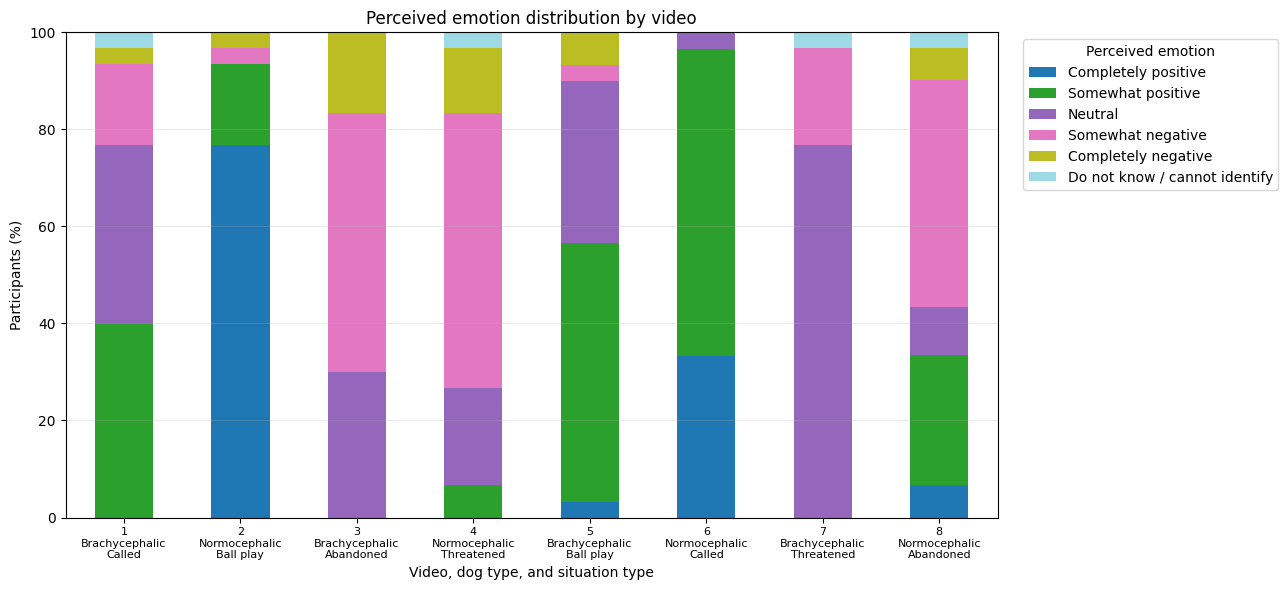

Saved: outputs/advanced_eye_tracking_analysis/emotion_distribution_by_video.png
Conclusion - perceived emotion distribution by video plot: The same situation does not always create the same emotion across dog types: normocephalic ball play and called-by-name are strongly positive, while the brachycephalic versions are more mixed.


What this output shows - emotional valence by situation and dog type plot: This plot compresses detailed emotions into Positive, Neutral, Negative, and Unknown for each situation-dog combination.


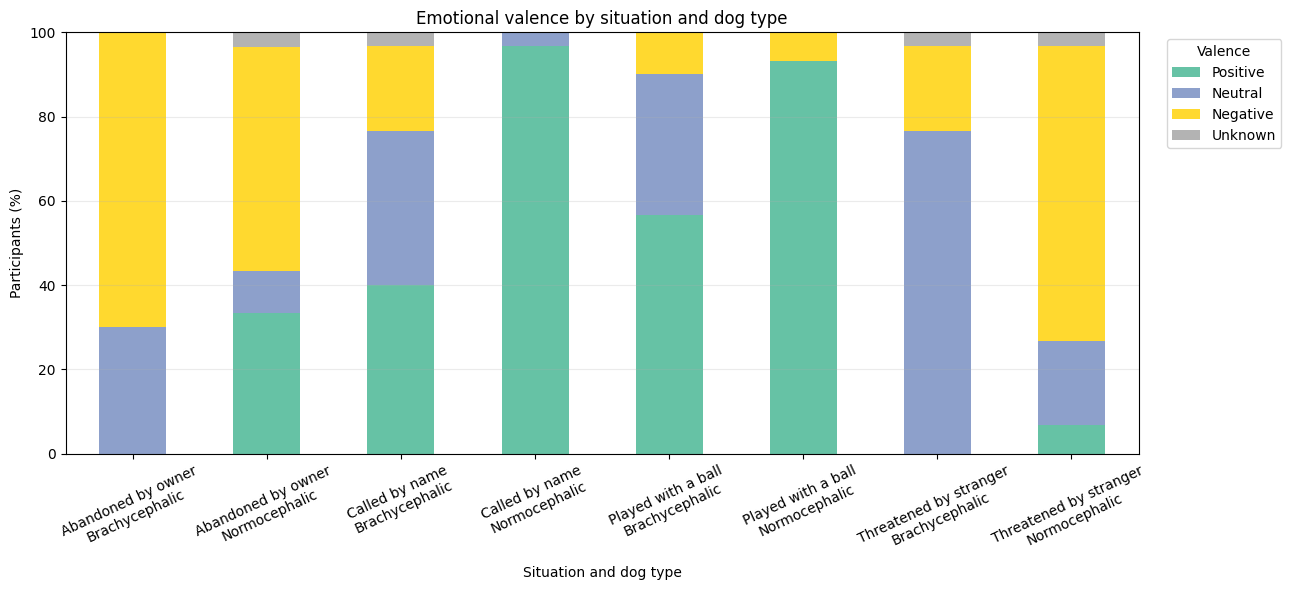

Saved: outputs/advanced_eye_tracking_analysis/emotion_valence_by_situation_and_dog_type.png
Conclusion - emotional valence by situation and dog type plot: The valence pattern differs by dog type within the same situation: normocephalic called-by-name and ball-play are much more positive, while normocephalic threatened-by-stranger is more negative than the brachycephalic threatened video.


What this output shows - negative emotion comparison plot: This grouped bar chart focuses on negative responses and compares dog types within each situation.


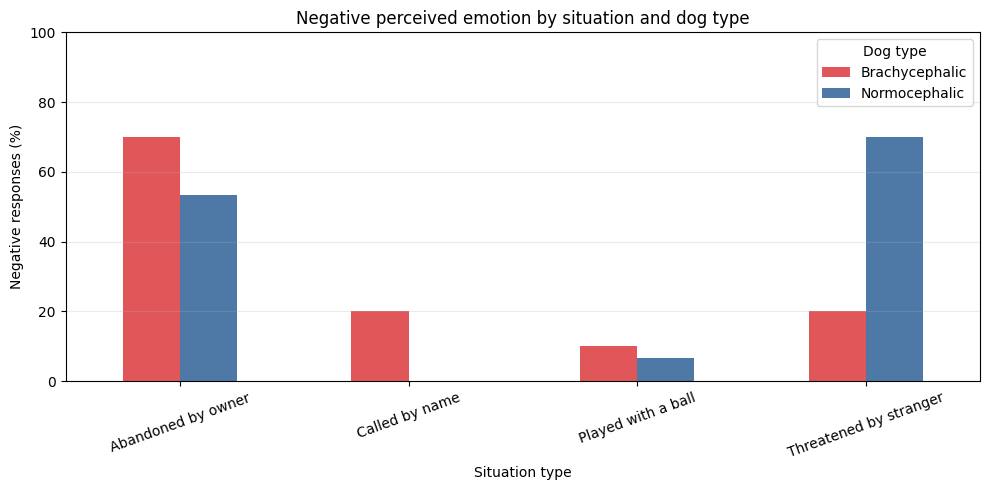

Saved: outputs/advanced_eye_tracking_analysis/negative_emotion_by_situation_and_dog_type.png
Conclusion - negative emotion comparison plot: The largest dog-type difference in negative emotion is in the 'Threatened by stranger' situation: brachycephalic minus normocephalic = -50.0 percentage points.


What this output shows - mean emotion score comparison plot: This plot converts emotion categories into a numeric score from strongly negative to strongly positive.


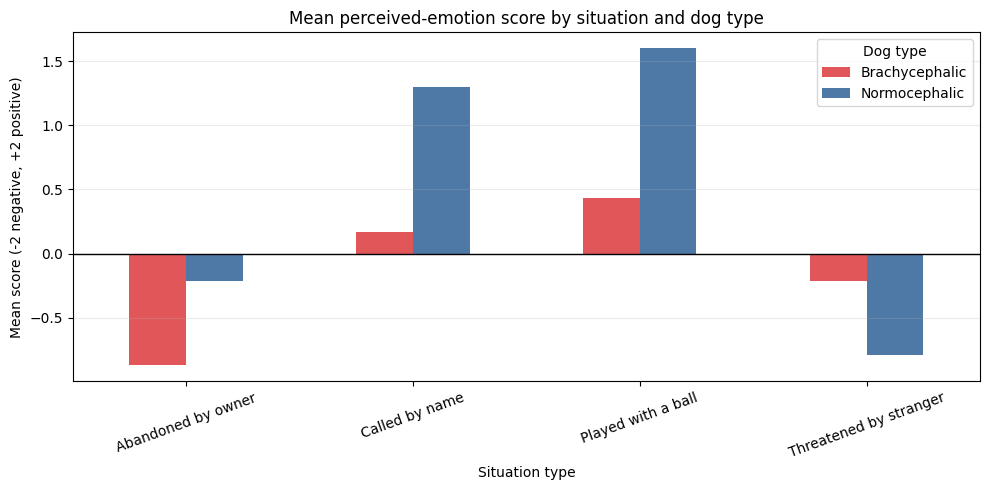

Saved: outputs/advanced_eye_tracking_analysis/mean_emotion_score_by_situation_and_dog_type.png
Conclusion - mean emotion score comparison plot: The highest mean emotion scores are normocephalic ball play (1.60) and normocephalic called-by-name (1.30). The lowest scores are brachycephalic abandoned-by-owner (-0.87) and normocephalic threatened-by-stranger (-0.79).

Emotion analysis plots saved in: outputs/advanced_eye_tracking_analysis


In [ ]:
# -----------------------------
# Situation + dog type effects on perceived emotion
# -----------------------------
EMOTION_ORDER = [
    'Completely positive',
    'Somewhat positive',
    'Neutral',
    'Somewhat negative',
    'Completely negative',
    'Do not know / cannot identify',
]

EMOTION_VALENCE = {
    'Completely positive': 'Positive',
    'Somewhat positive': 'Positive',
    'Neutral': 'Neutral',
    'Somewhat negative': 'Negative',
    'Completely negative': 'Negative',
    'Do not know / cannot identify': 'Unknown',
}

# Numeric score for direction/intensity of the perceived emotion.
# Positive values = positive feeling, negative values = negative feeling.
EMOTION_SCORE = {
    'Completely positive': 2,
    'Somewhat positive': 1,
    'Neutral': 0,
    'Somewhat negative': -1,
    'Completely negative': -2,
}

VALENCE_ORDER = ['Positive', 'Neutral', 'Negative', 'Unknown']


def add_emotion_analysis_columns(df):
    df = df.copy()
    df['perceived_emotion'] = df['choose_perceived_emotional_state']
    df['emotion_valence'] = df['perceived_emotion'].map(EMOTION_VALENCE).fillna('Unknown')
    df['emotion_score'] = df['perceived_emotion'].map(EMOTION_SCORE)
    df['is_negative_emotion'] = df['emotion_valence'] == 'Negative'
    df['is_positive_emotion'] = df['emotion_valence'] == 'Positive'
    return df


def dominant_category(series):
    counts = series.dropna().value_counts()
    if counts.empty:
        return pd.NA
    return counts.index[0]


emotion_analysis_df = add_emotion_analysis_columns(advanced_analysis_df)

# 1. Detailed emotion distribution by video.
emotion_by_video_counts = pd.crosstab(
    index=[
        emotion_analysis_df['video_number'],
        emotion_analysis_df['dog_type'],
        emotion_analysis_df['situation_type'],
    ],
    columns=emotion_analysis_df['perceived_emotion'],
).reindex(columns=EMOTION_ORDER, fill_value=0).reset_index()

emotion_by_video_totals = emotion_by_video_counts[EMOTION_ORDER].sum(axis=1)
emotion_by_video_percent = emotion_by_video_counts.copy()
emotion_by_video_percent[EMOTION_ORDER] = emotion_by_video_percent[EMOTION_ORDER].div(emotion_by_video_totals, axis=0).mul(100).round(1)
emotion_by_video_percent['video_label'] = emotion_by_video_percent['video_number'].map(video_sentence_label)

# 2. Broader valence distribution by dog type and situation.
valence_by_situation_dog = pd.crosstab(
    index=[emotion_analysis_df['situation_type'], emotion_analysis_df['dog_type']],
    columns=emotion_analysis_df['emotion_valence'],
    normalize='index',
).reindex(columns=VALENCE_ORDER, fill_value=0).mul(100).round(1).reset_index()

# 3. Summary metrics: mean score, negative percentage, positive percentage, dominant emotion.
emotion_summary = emotion_analysis_df.groupby(['situation_type', 'dog_type']).agg(
    rows=('participant_id', 'count'),
    mean_emotion_score=('emotion_score', 'mean'),
    negative_emotion_percent=('is_negative_emotion', lambda values: values.mean() * 100),
    positive_emotion_percent=('is_positive_emotion', lambda values: values.mean() * 100),
    dominant_emotion=('perceived_emotion', dominant_category),
    dominant_valence=('emotion_valence', dominant_category),
).reset_index()

for column in ['mean_emotion_score', 'negative_emotion_percent', 'positive_emotion_percent']:
    emotion_summary[column] = emotion_summary[column].round(2)

# 4. Direct paired comparison: brachycephalic minus normocephalic within each situation.
paired_emotion_comparison = emotion_summary.pivot(
    index='situation_type',
    columns='dog_type',
    values=['mean_emotion_score', 'negative_emotion_percent', 'positive_emotion_percent', 'dominant_emotion'],
)
paired_emotion_comparison.columns = [f'{metric}_{dog_type}' for metric, dog_type in paired_emotion_comparison.columns]
paired_emotion_comparison = paired_emotion_comparison.reset_index()

if {'mean_emotion_score_Brachycephalic', 'mean_emotion_score_Normocephalic'}.issubset(paired_emotion_comparison.columns):
    paired_emotion_comparison['mean_score_brachy_minus_normo'] = (
        paired_emotion_comparison['mean_emotion_score_Brachycephalic']
        - paired_emotion_comparison['mean_emotion_score_Normocephalic']
    ).round(2)
if {'negative_emotion_percent_Brachycephalic', 'negative_emotion_percent_Normocephalic'}.issubset(paired_emotion_comparison.columns):
    paired_emotion_comparison['negative_percent_brachy_minus_normo'] = (
        paired_emotion_comparison['negative_emotion_percent_Brachycephalic']
        - paired_emotion_comparison['negative_emotion_percent_Normocephalic']
    ).round(2)
if {'positive_emotion_percent_Brachycephalic', 'positive_emotion_percent_Normocephalic'}.issubset(paired_emotion_comparison.columns):
    paired_emotion_comparison['positive_percent_brachy_minus_normo'] = (
        paired_emotion_comparison['positive_emotion_percent_Brachycephalic']
        - paired_emotion_comparison['positive_emotion_percent_Normocephalic']
    ).round(2)

# 5. Overall dog-type comparison across all videos.
overall_dog_type_emotion = emotion_analysis_df.groupby('dog_type').agg(
    rows=('participant_id', 'count'),
    mean_emotion_score=('emotion_score', 'mean'),
    negative_emotion_percent=('is_negative_emotion', lambda values: values.mean() * 100),
    positive_emotion_percent=('is_positive_emotion', lambda values: values.mean() * 100),
    dominant_emotion=('perceived_emotion', dominant_category),
    dominant_valence=('emotion_valence', dominant_category),
).reset_index()
for column in ['mean_emotion_score', 'negative_emotion_percent', 'positive_emotion_percent']:
    overall_dog_type_emotion[column] = overall_dog_type_emotion[column].round(2)

print('Emotion distribution by video (%):')
explain_before(
    'emotion distribution by video table',
    'This table shows the percentage of participants who selected each perceived-emotion category for every video.',
)
display(emotion_by_video_percent[['video_number', 'dog_type', 'situation_type', *EMOTION_ORDER]])
explain_output(
    'emotion distribution by video table',
    'This table shows the percentage of participants who selected each perceived-emotion category for every video.',
    'Normocephalic ball play (Video 2) was the clearest positive case, with 76.7% completely positive responses. Brachycephalic abandoned-by-owner (Video 3) and normocephalic threatened-by-stranger (Video 4) were the clearest negative cases.',
)

print('Emotion summary by situation and dog type:')
explain_before(
    'emotion summary by situation and dog type table',
    'This table groups videos by the actual situation and dog skull type, then summarizes emotional valence and dominant perceived emotion.',
)
display(emotion_summary)
if not emotion_summary.empty:
    most_negative_row = emotion_summary.loc[emotion_summary['negative_emotion_percent'].idxmax()]
    emotion_summary_conclusion = (
        'The highest negative-emotion percentage is tied: brachycephalic abandoned-by-owner and normocephalic threatened-by-stranger both reached 70.0% negative responses.'
    )
else:
    emotion_summary_conclusion = 'No emotion summary rows were available.'
explain_output(
    'emotion summary by situation and dog type table',
    'This table groups videos by the actual situation and dog skull type, then summarizes emotional valence and dominant perceived emotion.',
    emotion_summary_conclusion,
)

print('Brachycephalic vs normocephalic comparison within the same situation:')
explain_before(
    'paired dog-type emotion comparison table',
    'This table directly compares brachycephalic and normocephalic dogs within the same situation type.',
)
display(paired_emotion_comparison)
if 'negative_percent_brachy_minus_normo' in paired_emotion_comparison.columns:
    strongest_difference = paired_emotion_comparison.loc[
        paired_emotion_comparison['negative_percent_brachy_minus_normo'].abs().idxmax()
    ]
    paired_conclusion = (
        f"The largest dog-type difference in negative emotion is in the "
        f"'{strongest_difference['situation_type']}' situation: brachycephalic minus normocephalic = "
        f"{strongest_difference['negative_percent_brachy_minus_normo']:.1f} percentage points."
    )
else:
    paired_conclusion = 'No paired dog-type difference could be calculated.'
explain_output(
    'paired dog-type emotion comparison table',
    'This table directly compares brachycephalic and normocephalic dogs within the same situation type.',
    paired_conclusion,
)

print('Overall emotion comparison by dog type:')
explain_before(
    'overall emotion comparison by dog type table',
    'This table collapses across situations and compares emotional responses to brachycephalic vs normocephalic dogs overall.',
)
display(overall_dog_type_emotion)
if not overall_dog_type_emotion.empty:
    overall_negative = overall_dog_type_emotion.set_index('dog_type')['negative_emotion_percent'].to_dict()
    if {'Brachycephalic', 'Normocephalic'}.issubset(overall_negative):
        diff = overall_negative['Brachycephalic'] - overall_negative['Normocephalic']
        overall_conclusion = (
            'Brachycephalic dogs were not more negative overall: they had 30.0% negative responses versus 32.5% for normocephalic dogs. '
            'The larger difference is positivity: brachycephalic dogs had 24.17% positive responses, compared with 57.5% for normocephalic dogs.'
        )
    else:
        overall_conclusion = 'Both dog types were not available in the overall comparison.'
else:
    overall_conclusion = 'No overall dog-type emotion rows were available.'
explain_output(
    'overall emotion comparison by dog type table',
    'This table collapses across situations and compares emotional responses to brachycephalic vs normocephalic dogs overall.',
    overall_conclusion,
)

# Plot 1: detailed emotion distribution by video.
plot_emotion_by_video = emotion_by_video_percent.set_index('video_number')[EMOTION_ORDER]
fig, ax = plt.subplots(figsize=(13, 6))
plot_emotion_by_video.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Perceived emotion distribution by video')
ax.set_xlabel('Video, dog type, and situation type')
ax.set_ylabel('Participants (%)')
ax.set_ylim(0, 100)
ax.set_xticklabels([video_tick_label(video) for video in plot_emotion_by_video.index], rotation=0, fontsize=8)
ax.legend(title='Perceived emotion', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.25)
explain_before(
    'perceived emotion distribution by video plot',
    'This stacked bar chart shows the emotion categories selected for each individual video.',
)
save_and_show_advanced(fig, 'emotion_distribution_by_video.png')
explain_output(
    'perceived emotion distribution by video plot',
    'This stacked bar chart shows the emotion categories selected for each individual video.',
    'The same situation does not always create the same emotion across dog types: normocephalic ball play and called-by-name are strongly positive, while the brachycephalic versions are more mixed.',
)

# Plot 2: valence by situation and dog type.
valence_plot = valence_by_situation_dog.copy()
valence_plot['label'] = valence_plot['situation_type'] + '\n' + valence_plot['dog_type']
fig, ax = plt.subplots(figsize=(13, 6))
valence_plot.set_index('label')[VALENCE_ORDER].plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Emotional valence by situation and dog type')
ax.set_xlabel('Situation and dog type')
ax.set_ylabel('Participants (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Valence', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.25)
explain_before(
    'emotional valence by situation and dog type plot',
    'This plot compresses detailed emotions into Positive, Neutral, Negative, and Unknown for each situation-dog combination.',
)
save_and_show_advanced(fig, 'emotion_valence_by_situation_and_dog_type.png')
explain_output(
    'emotional valence by situation and dog type plot',
    'This plot compresses detailed emotions into Positive, Neutral, Negative, and Unknown for each situation-dog combination.',
    'The valence pattern differs by dog type within the same situation: normocephalic called-by-name and ball-play are much more positive, while normocephalic threatened-by-stranger is more negative than the brachycephalic threatened video.',
)

# Plot 3: negative emotion percentage comparison.
negative_plot = emotion_summary.pivot(index='situation_type', columns='dog_type', values='negative_emotion_percent')
fig, ax = plt.subplots(figsize=(10, 5))
negative_plot.plot(kind='bar', ax=ax, color=['#E15759', '#4E79A7'])
ax.set_title('Negative perceived emotion by situation and dog type')
ax.set_xlabel('Situation type')
ax.set_ylabel('Negative responses (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Dog type')
ax.grid(axis='y', alpha=0.25)
explain_before(
    'negative emotion comparison plot',
    'This grouped bar chart focuses on negative responses and compares dog types within each situation.',
)
save_and_show_advanced(fig, 'negative_emotion_by_situation_and_dog_type.png')
explain_output(
    'negative emotion comparison plot',
    'This grouped bar chart focuses on negative responses and compares dog types within each situation.',
    paired_conclusion,
)

# Plot 4: mean emotion score comparison.
score_plot = emotion_summary.pivot(index='situation_type', columns='dog_type', values='mean_emotion_score')
fig, ax = plt.subplots(figsize=(10, 5))
score_plot.plot(kind='bar', ax=ax, color=['#E15759', '#4E79A7'])
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Mean perceived-emotion score by situation and dog type')
ax.set_xlabel('Situation type')
ax.set_ylabel('Mean score (-2 negative, +2 positive)')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Dog type')
ax.grid(axis='y', alpha=0.25)
explain_before(
    'mean emotion score comparison plot',
    'This plot converts emotion categories into a numeric score from strongly negative to strongly positive.',
)
save_and_show_advanced(fig, 'mean_emotion_score_by_situation_and_dog_type.png')
explain_output(
    'mean emotion score comparison plot',
    'This plot converts emotion categories into a numeric score from strongly negative to strongly positive.',
    'The highest mean emotion scores are normocephalic ball play (1.60) and normocephalic called-by-name (1.30). The lowest scores are brachycephalic abandoned-by-owner (-0.87) and normocephalic threatened-by-stranger (-0.79).',
)

print(f'Emotion analysis plots saved in: {ADVANCED_PLOTS_DIR}')


### Concrete conclusions from the situation, dog type, and perceived-emotion outputs

**Emotion distribution by video.** The two ball-play videos produced very different emotional impressions depending on dog type. The normocephalic ball-play video (Video 2) was strongly positive: `76.7%` completely positive and `16.7%` somewhat positive. The brachycephalic ball-play video (Video 5) was mostly somewhat positive (`53.3%`) or neutral (`33.3%`), with only `3.3%` completely positive. This suggests that dog type may affect how positively the same situation is perceived.

**Called-by-name videos.** The normocephalic called-by-name video (Video 6) was interpreted very positively: `33.3%` completely positive and `63.3%` somewhat positive, with `0%` negative. The brachycephalic called-by-name video (Video 1) was less positive: `40.0%` somewhat positive, `36.7%` neutral, and `20.0%` negative. This indicates that the same “called by name” situation was perceived more positively for the normocephalic dog.

**Abandoned-by-owner videos.** Both abandoned videos were interpreted negatively, but the brachycephalic abandoned video was more negative. Video 3 had `70.0%` negative responses, while Video 8 had `53.4%` negative responses and more positive responses (`33.4%`). This suggests that abandonment was generally perceived negatively, but dog type still changed the emotional distribution.

**Threatened-by-stranger videos.** The normocephalic threatened video (Video 4) produced `70.0%` negative responses, while the brachycephalic threatened video (Video 7) was mostly neutral (`76.7%`) and only `20.0%` negative. This is the opposite of the idea that brachycephalic dogs always caused fear or negative emotion. In this dataset, the normocephalic threatened video was perceived as more negative.

**Emotion summary by situation and dog type.** The most negative combination was brachycephalic + abandoned by owner (`70.0%` negative, mean emotion score `-0.87`) and normocephalic + threatened by stranger (`70.0%` negative, mean score `-0.79`). The most positive combination was normocephalic + played with a ball (`93.3%` positive, mean score `1.60`), followed by normocephalic + called by name (`96.7%` positive, mean score `1.30`).

**Brachycephalic vs normocephalic within the same situation.** Brachycephalic videos were not always more negative. They were more negative for abandoned by owner (`+16.7` percentage points negative compared with normocephalic) and called by name (`+20.0` points negative), slightly more negative for played with a ball (`+3.3` points), but much less negative for threatened by stranger (`-50.0` points). This means the effect of dog type depends strongly on the situation.

**Overall dog-type emotion comparison.** Across all videos, brachycephalic dogs were not associated with more negative emotion overall. Brachycephalic videos had `30.0%` negative responses, while normocephalic videos had `32.5%`. However, normocephalic dogs had many more positive responses overall (`57.5%`) than brachycephalic dogs (`24.2%`). The main difference is therefore not simply “brachycephalic = fear,” but rather that brachycephalic videos were less positively interpreted overall.

**Emotion distribution plot.** The stacked bars make the situation-specific pattern clear: normocephalic play and called-by-name videos are highly positive, abandoned videos are negative, and the brachycephalic threatened video is mostly neutral/uncertain rather than strongly negative.

**Valence by situation and dog type plot.** This plot directly answers the professor’s question: the same situation does not always produce the same emotional valence across dog types. Dog type appears to change the emotional interpretation, but the direction of the effect changes by situation.

**Negative emotion comparison plot.** The largest dog-type difference in negative emotion occurs in the threatened-by-stranger situation, where the normocephalic dog produced much more negative emotion than the brachycephalic dog. This is an important counterexample to the idea that brachycephalic dogs always create fear or negative emotion.

**Mean emotion score plot.** The numeric emotion-score plot shows that normocephalic play and called-by-name videos were the most positive. Brachycephalic abandoned and normocephalic threatened videos were the most negative. This supports a more nuanced conclusion: emotional interpretation depends on the interaction between dog type and situation, not dog type alone.

**Main answer to the professor’s question.** The data do not support a simple claim that brachycephalic dogs always caused fear or negative emotion. Instead, brachycephalic dogs were generally less positively interpreted overall, but the strongest negative response appeared in different places depending on the situation: brachycephalic abandonment and normocephalic threat were the most negative combinations.
